# HTU Intelligent Registration System — Combined ML Pipeline (v3)

This notebook merges the best parts of two previous iterations:

| What we kept from **Pipeline 1** | What we kept from **Pipeline 2** | What's **new in v3** |
|---|---|---|
| Per-student per-course **binary classification** (one model per course) | **Course-level time-series features** (lag_1/2/3, rolling stats, yoy_lag, trend, course_term_mean, fail_pool, new_students, eligible_proxy) | **Student-course interaction features** (prereq readiness, in-plan flag, already-passed flag, fail-recovery flag, hours-to-graduation, GPA trend, load pattern) — *marked EXTRA so they can be removed easily* |
| Flexible `MODELS` dict + `PARAM_GRIDS` + `GridSearchCV` | Operational metrics (within ±5/±10/±15, section exact-match, over/under-allocation) | First-class **per-student probability output** — so the system can tell Academic Advisors *"Student 22110448 has 87% probability of enrolling in Cryptography next semester"* |
| EDA + model-comparison visuals (box plots, AUC heatmap, radar chart, best-model pie, confusion matrices, training-time bar) | Residual analysis, error heatmap, sections comparison, graduation risk, learning curve | **XAI hooks** — SHAP explainers built for every per-course model, plus helper that produces human-readable explanations for both per-student and aggregate predictions |
| Artifact saving with `inference_meta.json` | Category-aware evaluation (MAE by course category) | **Separated feature groups** in config so you can toggle each group on/off with a single flag |

## Pipeline flow

1. **Load** enrollments, students, and the 6 study-plan CSVs
2. **Explore** the data visually (EDA section)
3. **Engineer features** in 4 groups (core P1, course time-series P2, course metadata P2, extras v3)
4. **Split** train/test by semester (time-based — no leakage)
5. **Train** one binary classifier per target course, across multiple model families, with grid-searched hyperparameters
6. **Evaluate** at two levels: classification (per-student) + demand (aggregate) + sections (operational)
7. **Flag** graduation-risk students
8. **Explain** predictions with SHAP
9. **Save** everything for the Django backend

## A note on why "per-student per-course binary classification" was chosen

Predicting course demand the obvious way (*regress total count per course per semester*) loses the student-level signal entirely — you can't answer "which of *my* courses will I take next semester?" for a specific student. By framing it as *"will student S enroll in course C in semester S+1?"* for every (student, course) pair, we can:
- Produce per-student advisor-ready recommendations (the new requirement)
- Aggregate up into total course demand by summing predicted probabilities — this is mathematically sound and preserves calibration
- Derive section counts from the aggregate
- Flag graduating students via a straightforward rule on hours-remaining

The trade-off is more models to train (one per course instead of one global model) but since each is independent, training parallelises trivially and adding a new course never requires retraining existing models. This is the **agility** requirement from the project report.


## Section 0 — Configuration

One place to change any knob in the pipeline. Every downstream cell reads from these constants.

- **Data paths**: where to find the generator's output and where to save artifacts
- **Split**: inclusive boundary — everything ≤ (YEAR, TERM) is training
- **Feature groups**: toggle each group on/off with a single flag (useful when you want to ablate the "extras")
- **Models & grids**: add/remove by editing two dicts — no other code changes
- **Imbalance & thresholds**: how to handle rare courses and how confident we need to be to say "will enroll"


In [36]:
# ─────────────────────────────────────────────────────────────────────────────
# CONFIGURATION  ←  The ONLY place you should need to edit for most changes
# ─────────────────────────────────────────────────────────────────────────────

import os, warnings
warnings.filterwarnings("ignore")

# ── File paths ────────────────────────────────────────────────────────────────
# DATA_DIR should contain (from the fixed generator):
#   htu_students.csv, htu_enrollments.csv,
#   AI_Bachelor_Courses.csv, AI_Bachelor_Prerequisites.csv,
#   AI_Technical_Courses.csv, ... (6 plans × 2 files)
DATA_DIR      = "DATA/output"                            # generator's output folder
STUDENTS_FILE = os.path.join(DATA_DIR, "htu_students.csv")
ENROLLS_FILE  = os.path.join(DATA_DIR, "htu_enrollments.csv")

ARTIFACTS_DIR = "artifacts"   # where trained models + encoders are saved
RESULTS_DIR   = "results"     # where CSVs (predictions, demand, sections) are saved
PLOT_DIR      = "plots"       # where every figure PNG is saved
for d in (ARTIFACTS_DIR, RESULTS_DIR, PLOT_DIR):
    os.makedirs(d, exist_ok=True)

# ── Train / Test split (time-based, inclusive) ────────────────────────────────
# Everything ≤ TRAIN_UNTIL_{YEAR,TERM} → training set.
# Everything after → test set.  Keeps the future out of training (no leakage).
# Semester ordering inside a year is Fall(Y) → Spring(Y) → Summer(Y).
TRAIN_UNTIL_YEAR = 2023
TRAIN_UNTIL_TERM = "Summer"         # inclusive boundary

# ── Prediction horizon ────────────────────────────────────────────────────────
# 1 = predict the IMMEDIATELY next semester (the operational case).
# Keep at 1 unless the university wants multi-semester planning.
HORIZON = 1

# ── Course sparsity thresholds ────────────────────────────────────────────────
MIN_POSITIVE_SAMPLES   = 10     # skip courses with < N positive training samples
MIN_COURSE_ENROLLMENTS = 15     # skip courses enrolled by < N students historically

# ── Feature-group toggles ─────────────────────────────────────────────────────
# Each group can be turned off by flipping its flag — useful for ablation
# (e.g. "what happens if I remove the v3 extras?").
USE_CORE_STUDENT_FEATURES        = True   # P1: demographics + academic state + passed/failed vectors
USE_COURSE_TIMESERIES_FEATURES   = True   # P2: course-level lag/rolling/trend/yoy/fail_pool/...
USE_COURSE_METADATA_FEATURES     = True   # P2: credit_hours, lecture_hours, lab_hours, category_ord, is_compulsory
USE_V3_EXTRA_FEATURES            = True   # v3: student-course interaction features (prereqs, in-plan, hrs_remaining, gpa_trend, load_pattern)

# ── Class imbalance handling ──────────────────────────────────────────────────
# Most courses have far more 0s than 1s. Options:
#   "class_weight" — sklearn's built-in class_weight="balanced"
#   "none"         — no adjustment (use raw)
IMBALANCE_STRATEGY = "class_weight"

# ── Cross-validation folds ────────────────────────────────────────────────────
CV_FOLDS = 5

# ── Random seed (reproducibility) ─────────────────────────────────────────────
RANDOM_STATE = 42

# ── Models to train ───────────────────────────────────────────────────────────
# To ADD a model: add one entry here — the training loop picks it up automatically.
# To REMOVE a model: delete or comment out its entry.
from sklearn.linear_model   import LogisticRegression
from sklearn.ensemble       import RandomForestClassifier, GradientBoostingClassifier
from sklearn.ensemble       import HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

MODELS = {
    "RandomForest": (
        RandomForestClassifier,
        {"random_state": RANDOM_STATE, "n_jobs": -1}
    ),
    "HistGradientBoosting": (
        HistGradientBoostingClassifier,
        {"random_state": RANDOM_STATE}
    ),
    # "GradientBoosting": (
    #     GradientBoostingClassifier,
    #     {"random_state": RANDOM_STATE}
    # ),
    # "MLP": (
    #     MLPClassifier,
    #     {"random_state": RANDOM_STATE, "max_iter": 500}
    # ),
    # "LogisticRegression": (
    #     LogisticRegression,
    #     {"max_iter": 1000, "random_state": RANDOM_STATE}
    # ),
}

# ── Hyperparameter search grids ───────────────────────────────────────────────
# Format matches sklearn GridSearchCV param_grid.
# NOTE: these grids are deliberately MODEST because we train per-course per-model.
# If you have compute to spare, expand them.
PARAM_GRIDS = {
    "RandomForest": {
        "n_estimators":     [200, 300],
        "max_depth":        [20], 
        "min_samples_leaf": [1, 5],
        "class_weight":     ["balanced"],
    },
    "HistGradientBoosting": {
        "learning_rate":    [0.05, 0.1],
        "max_iter":         [200, 300],
        "max_depth":        [15],
    },
    # "GradientBoosting": {
    #     "n_estimators":  [100, 200],
    #     "learning_rate": [0.05, 0.1],
    #     "max_depth":     [3, 5],
    # },
    # "MLP": {
    #     "hidden_layer_sizes": [(64,), (128, 64)],
    #     "alpha":              [0.0001, 0.001],
    #     "learning_rate":      ["adaptive"],
    # },
}

# ── Scoring metric for hyperparameter search ──────────────────────────────────
# Options: "roc_auc", "f1", "average_precision", "recall", "precision"
SEARCH_METRIC = "roc_auc"

# ── Probability threshold for "will enroll" decision ──────────────────────────
# 0.5 is the default. Lower = more inclusive (catches more enrollments but more
# false positives).  Used only for binary labels; probabilities are always saved.
ENROLL_THRESHOLD = 0.5

# ── Section allocation ────────────────────────────────────────────────────────
SECTION_CAP          = 25     # max students per section (HTU standard)
SECTIONS_BUFFER_PCT  = 0.10   # add 10% buffer on top of predicted demand

# ── Graduation-risk parameters ────────────────────────────────────────────────
PLAN_TOTAL_HOURS = {
    "CS_Bachelor":    135, "CS_Technical":    105,
    "AI_Bachelor":    135, "AI_Technical":    105,
    "Cyber_Bachelor": 135, "Cyber_Technical": 105,
}
GRAD_PERCENTILE = 0.75   # students past the 75th-percentile grad time are "at-risk"

print("Configuration loaded ✓")
print(f"  Train boundary:       {TRAIN_UNTIL_YEAR}_{TRAIN_UNTIL_TERM} (inclusive)")
print(f"  Models to train:      {list(MODELS.keys())}")
print(f"  Feature groups ON:    "
      f"{'CORE ' if USE_CORE_STUDENT_FEATURES else ''}"
      f"{'COURSE-TS ' if USE_COURSE_TIMESERIES_FEATURES else ''}"
      f"{'COURSE-META ' if USE_COURSE_METADATA_FEATURES else ''}"
      f"{'V3-EXTRA ' if USE_V3_EXTRA_FEATURES else ''}")
print(f"  Artifacts → {ARTIFACTS_DIR}/")
print(f"  Results   → {RESULTS_DIR}/")
print(f"  Plots     → {PLOT_DIR}/")


Configuration loaded ✓
  Train boundary:       2023_Summer (inclusive)
  Models to train:      ['RandomForest', 'HistGradientBoosting']
  Feature groups ON:    CORE COURSE-TS COURSE-META V3-EXTRA 
  Artifacts → artifacts/
  Results   → results/
  Plots     → plots/


## Section 1 — Imports & Data Loading

Load the three things we need:
1. **Enrollments** — one row per (student, course, semester) with the grade
2. **Students** — one row per student with major, degree_type, admission year, remedial flags
3. **Master catalog** — union of all six `*_Courses.csv` files (course metadata: credit hours, lecture/lab hours, category)

All course codes are forced to string (leading zeros would otherwise be stripped when pandas infers `int64`).


In [37]:
# Standard library
import os, json, time, itertools, pickle
from collections import defaultdict

# Data
import numpy  as np
import pandas as pd

# Sklearn — core
from sklearn.preprocessing    import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.model_selection  import GridSearchCV, StratifiedKFold, learning_curve
from sklearn.metrics          import (
    roc_auc_score, f1_score, precision_score, recall_score,
    average_precision_score, confusion_matrix, ConfusionMatrixDisplay,
    mean_absolute_error, mean_squared_error, r2_score,
)

# Persistence
import joblib

# Visualization
import matplotlib
import matplotlib.pyplot as plt
import seaborn           as sns
from matplotlib.patches  import Patch

matplotlib.rcParams.update({
    "figure.dpi":      120,
    "figure.facecolor":"white",
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "font.family":     "sans-serif",
})
sns.set_palette("husl")

# Shared colour palette — used across every figure for visual consistency
PAL = {
    "primary":   "#2C5F8A",
    "secondary": "#E07B39",
    "success":   "#3A9E68",
    "danger":    "#C0392B",
    "light":     "#BDC3C7",
    "accent":    "#8E44AD",
}

print("All imports ✓")


All imports ✓


In [38]:
# ── Load raw data ────────────────────────────────────────────────────────────
students = pd.read_csv(STUDENTS_FILE)
enrolls  = pd.read_csv(ENROLLS_FILE, dtype={"course_code": str})
enrolls["course_code"] = enrolls["course_code"].astype(str).str.strip()

# ── Master course catalog (union of all 6 plan CSVs) ─────────────────────────
# This gives us credit_hours, lecture_hours, lab_hours, and category per course.
catalog_frames = [
    pd.read_csv(os.path.join(DATA_DIR, fn), dtype={"course_code": str})
    for fn in sorted(os.listdir(DATA_DIR))
    if fn.endswith("_Courses.csv")
]
master_cat = (pd.concat(catalog_frames)
              .drop_duplicates(subset=["course_code"])
              [["course_code","course_name_en","credit_hours",
                "lecture_hours","lab_hours","category"]]
              .rename(columns={"course_name_en":"course_name"})
              .reset_index(drop=True))
for col in ["credit_hours","lecture_hours","lab_hours"]:
    master_cat[col] = master_cat[col].astype(float)

# ── Master prerequisites table (union of all 6 plan prereq CSVs) ─────────────
# Used by the v3 "prereqs_satisfied" feature.
prereq_frames = [
    pd.read_csv(os.path.join(DATA_DIR, fn),
                dtype={"course_code": str, "prereq_code": str})
    for fn in sorted(os.listdir(DATA_DIR))
    if fn.endswith("_Prerequisites.csv")
]
master_prereqs = (pd.concat(prereq_frames)
                  .drop_duplicates(subset=["course_code","prereq_code"])
                  .reset_index(drop=True))

# ── Semester ordering ────────────────────────────────────────────────────────
# CRITICAL: HTU academic year is Fall(Y) → Spring(Y) → Summer(Y), then Fall(Y+1).
# Spring and Summer share the same calendar year as the preceding Fall.
TERM_ORDER = {"Fall": 1, "Spring": 2, "Summer": 3}
enrolls["sem_sort_key"] = enrolls["year"].astype(int) * 10 + enrolls["term"].map(TERM_ORDER)
enrolls = enrolls.sort_values(["student_id","sem_sort_key"]).reset_index(drop=True)

print(f"Enrollments  : {len(enrolls):>8,} rows")
print(f"Students     : {len(students):>8,} rows")
print(f"Courses      : {len(master_cat):>8}")
print(f"Prereq edges : {len(master_prereqs):>8}")
print(f"Semesters    : {enrolls['semester_label'].nunique():>8}  "
      f"({enrolls['semester_label'].min()} → {enrolls['semester_label'].max()})")
print()
print("Student status breakdown:")
print(students["status"].value_counts().to_string())


Enrollments  :   92,882 rows
Students     :    3,000 rows
Courses      :       97
Prereq edges :       70
Semesters    :       19  (2019_Fall → 2025_Fall)

Student status breakdown:
status
Active       2037
Graduated     963


## Section 2 — Exploratory Data Analysis

Before training anything, let's look at the shape of the data.

Seven visuals in this section — five inherited from Pipeline 1 (enrollment volume, top courses, student distributions, train/test split preview) plus two **new** ones (major × degree-type breakdown, category × term heatmap) that help spot which course groups might be harder to predict later.


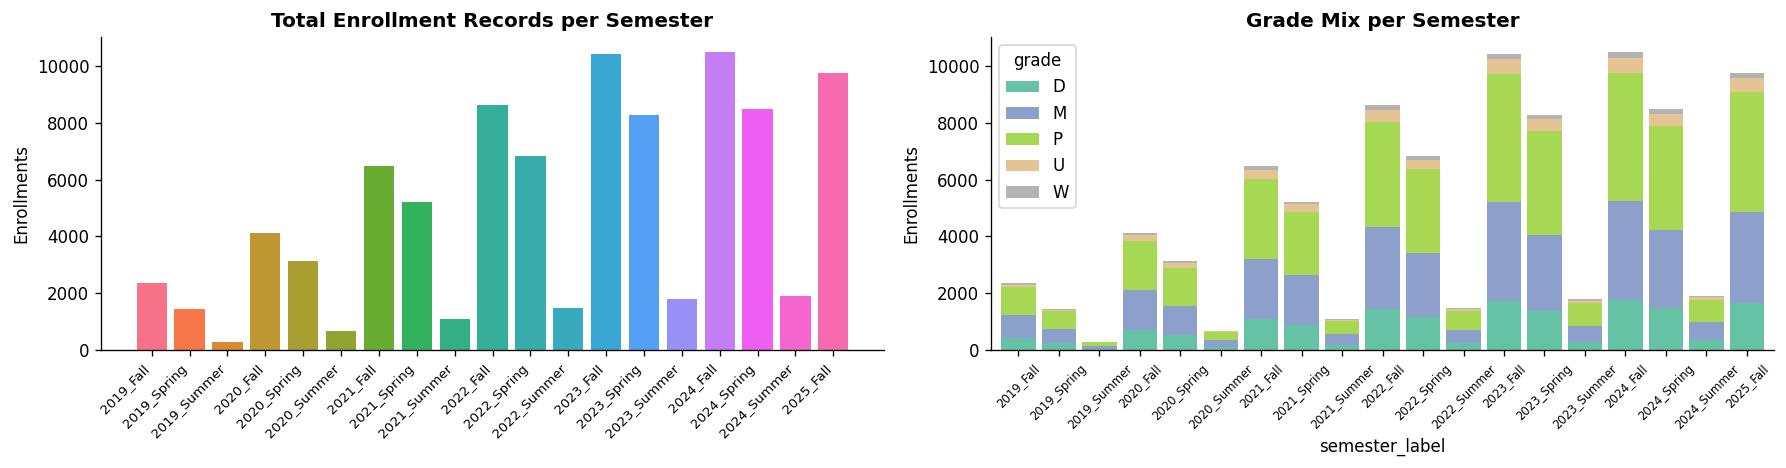

In [39]:
# ── Figure 1: Enrollment volume and grade mix per semester ───────────────────
sem_agg = (enrolls.groupby(["semester_label","sem_sort_key"])
           .size().reset_index(name="n")
           .sort_values("sem_sort_key"))

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# Left — total enrollment records per semester (macro demand curve)
axes[0].bar(range(len(sem_agg)), sem_agg["n"],
            color=sns.color_palette("husl", len(sem_agg)))
axes[0].set_xticks(range(len(sem_agg)))
axes[0].set_xticklabels(sem_agg["semester_label"], rotation=45, ha="right", fontsize=8)
axes[0].set_title("Total Enrollment Records per Semester", fontweight="bold")
axes[0].set_ylabel("Enrollments")

# Right — stacked grade mix per semester
grade_by_sem = (enrolls.groupby(["semester_label","grade","sem_sort_key"])
                .size().unstack(level=1, fill_value=0)
                .reset_index().sort_values("sem_sort_key").set_index("semester_label"))
grade_by_sem.drop(columns="sem_sort_key", errors="ignore").plot(
    kind="bar", stacked=True, ax=axes[1], colormap="Set2", width=0.85)
axes[1].set_title("Grade Mix per Semester", fontweight="bold")
axes[1].set_ylabel("Enrollments")
axes[1].tick_params(axis="x", labelsize=7, rotation=45)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "fig01_enrollment_volume.png"), bbox_inches="tight")
plt.show()


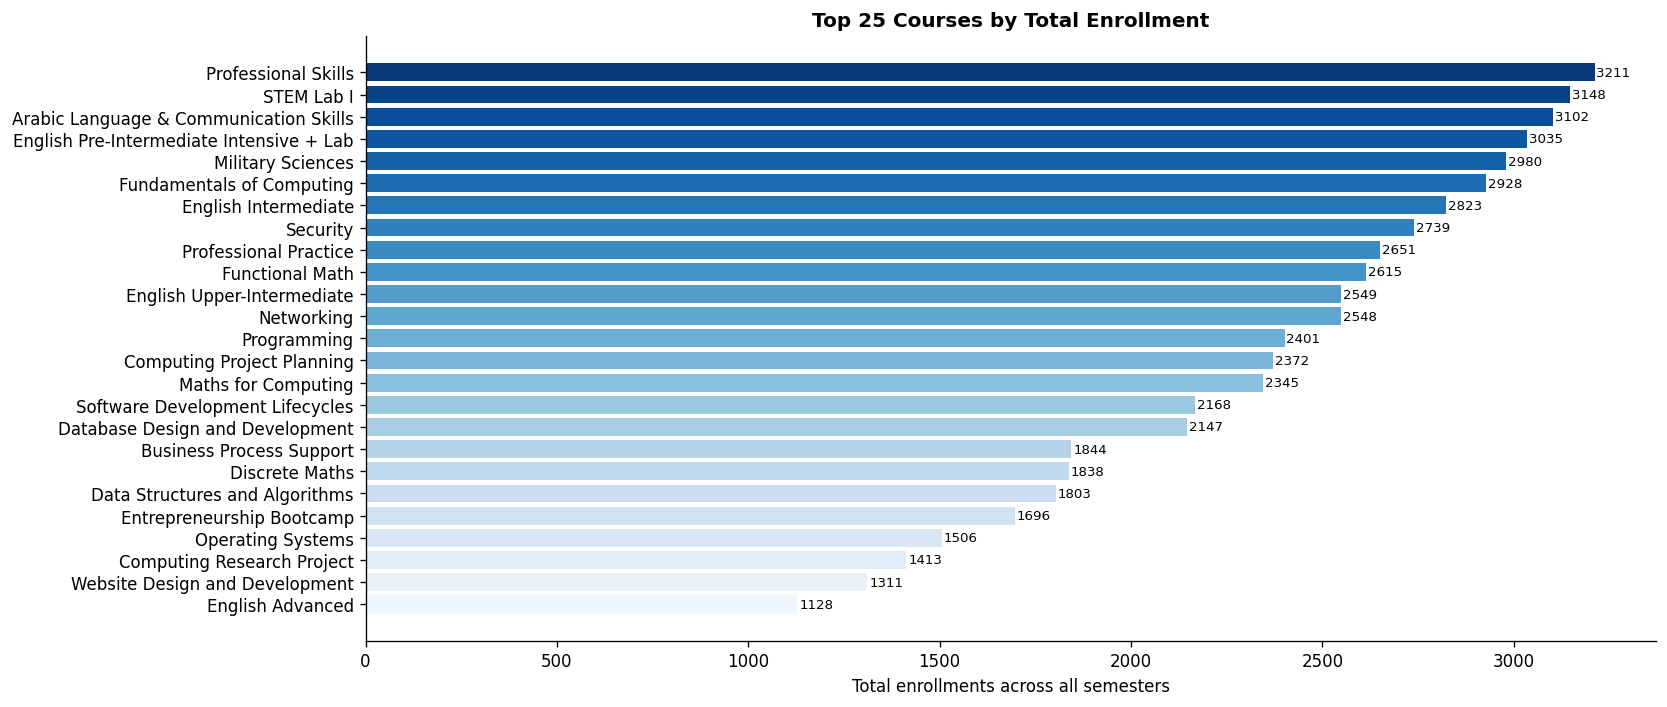

In [40]:
# ── Figure 2: Top 25 courses by total enrollment ─────────────────────────────
# Merge course_name from catalog first (in case enrolls doesn't carry it)
_enr_named = enrolls.merge(master_cat[["course_code","course_name"]], on="course_code", how="left")
course_demand = (_enr_named.groupby(["course_code","course_name_x"])
                 .size().reset_index(name="total_enrollments")
                 .sort_values("total_enrollments", ascending=False))

fig, ax = plt.subplots(figsize=(14, 6))
top25 = course_demand.head(25)
bars = ax.barh(top25["course_name_x"], top25["total_enrollments"],
               color=sns.color_palette("Blues_r", 25))
ax.set_xlabel("Total enrollments across all semesters")
ax.set_title("Top 25 Courses by Total Enrollment", fontweight="bold")
ax.invert_yaxis()
for bar, val in zip(bars, top25["total_enrollments"]):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            str(val), va="center", fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "fig02_top_courses.png"), bbox_inches="tight")
plt.show()


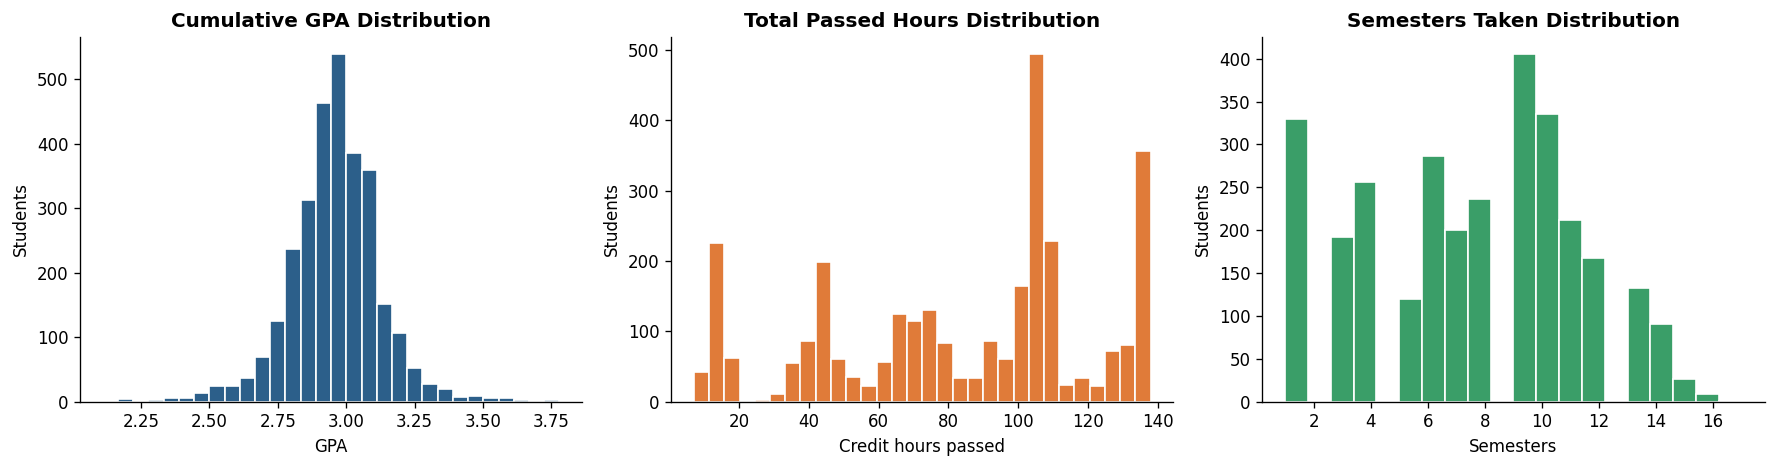

In [41]:
# ── Figure 3: Student-level distributions (GPA, hours, semesters) ────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(students["final_cum_gpa"], bins=30, color=PAL["primary"], edgecolor="white")
axes[0].set_title("Cumulative GPA Distribution", fontweight="bold")
axes[0].set_xlabel("GPA"); axes[0].set_ylabel("Students")

axes[1].hist(students["total_passed_hrs"], bins=30, color=PAL["secondary"], edgecolor="white")
axes[1].set_title("Total Passed Hours Distribution", fontweight="bold")
axes[1].set_xlabel("Credit hours passed"); axes[1].set_ylabel("Students")

axes[2].hist(students["semesters_taken"], bins=20, color=PAL["success"], edgecolor="white")
axes[2].set_title("Semesters Taken Distribution", fontweight="bold")
axes[2].set_xlabel("Semesters"); axes[2].set_ylabel("Students")

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "fig03_student_distributions.png"), bbox_inches="tight")
plt.show()


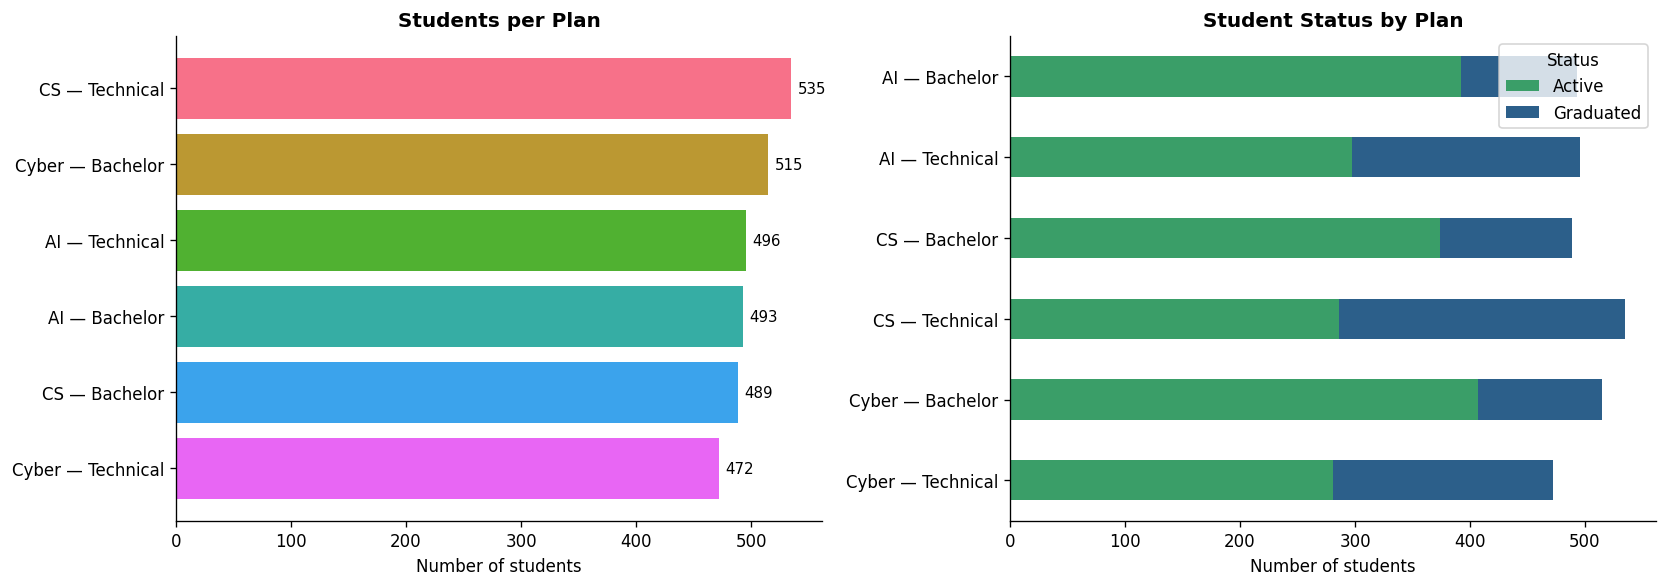

In [42]:
# ── Figure 4 [NEW]: Major × degree-type breakdown and plan representation ────
# Helps us sanity-check that no plan is severely under-represented in the data.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plan_counts = (students.groupby(["major","degree_type"])
               .size().reset_index(name="n")
               .sort_values("n", ascending=False))
plan_counts["label"] = plan_counts["major"] + " — " + plan_counts["degree_type"]

# Left — bar chart of students per plan
axes[0].barh(plan_counts["label"], plan_counts["n"],
             color=sns.color_palette("husl", len(plan_counts)))
for i, (n, label) in enumerate(zip(plan_counts["n"], plan_counts["label"])):
    axes[0].text(n + max(plan_counts["n"])*0.01, i, str(n), va="center", fontsize=9)
axes[0].set_xlabel("Number of students")
axes[0].set_title("Students per Plan", fontweight="bold")
axes[0].invert_yaxis()

# Right — stacked by status (Active / Graduated / Dropped)
status_mix = students.groupby(["major","degree_type","status"]).size().unstack(fill_value=0)
status_mix.index = [f"{m} — {d}" for (m,d) in status_mix.index]
status_mix.plot(kind="barh", stacked=True, ax=axes[1],
                color=[PAL["success"], PAL["primary"], PAL["danger"]][:len(status_mix.columns)])
axes[1].set_xlabel("Number of students")
axes[1].set_title("Student Status by Plan", fontweight="bold")
axes[1].invert_yaxis()
axes[1].legend(title="Status")

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "fig04_plan_distribution.png"), bbox_inches="tight")
plt.show()


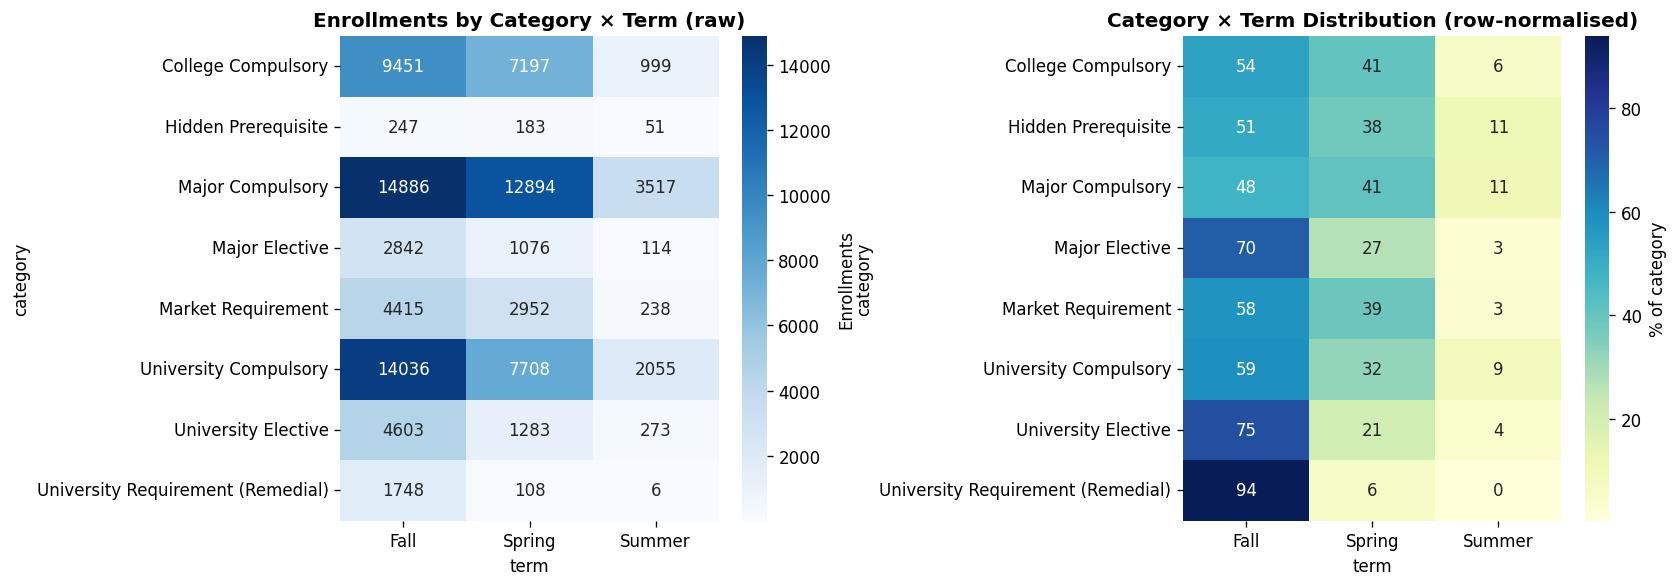

In [43]:
# ── Figure 5 [NEW]: Course category × semester-term heatmap ──────────────────
# Shows WHICH course categories are typically taken in WHICH term type.
# Useful context for interpreting later predictions (e.g. Market Requirements
# are concentrated in specific terms because of the apprenticeship structure).
enr_with_cat = enrolls.merge(master_cat[["course_code","category"]], on="course_code", how="left")
enr_with_cat["category"] = enr_with_cat["category"].fillna("Unknown")

cat_term = (enr_with_cat.groupby(["category","term"])
            .size().unstack(fill_value=0))
# Normalise so each row sums to 1 → shows the preferred term for each category
cat_term_pct = cat_term.div(cat_term.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cat_term, annot=True, fmt="d", cmap="Blues",
            ax=axes[0], cbar_kws={"label":"Enrollments"})
axes[0].set_title("Enrollments by Category × Term (raw)", fontweight="bold")

sns.heatmap(cat_term_pct, annot=True, fmt=".0f", cmap="YlGnBu",
            ax=axes[1], cbar_kws={"label":"% of category"})
axes[1].set_title("Category × Term Distribution (row-normalised)", fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "fig05_category_term_heatmap.png"), bbox_inches="tight")
plt.show()


## Section 3 — Feature Engineering

The single most important section — **the reason Pipeline 2 outperformed Pipeline 1 was that its features made the data's underlying relationships explicit to the model**, not buried inside high-dimensional one-hot encodings.

We build four groups of features, each gated by a config flag so you can ablate them later:

| Group | Source | What it captures | Flag |
|---|---|---|---|
| **3.A Core student features** | Pipeline 1 | Student demographics, academic state (GPA, hours, semester #), and which courses they've passed/failed so far | `USE_CORE_STUDENT_FEATURES` |
| **3.B Course time-series features** | Pipeline 2 | How popular this course has been recently (lag_1/2/3, rolling stats, yoy, trend), how many students failed it last semester, how many could potentially take it | `USE_COURSE_TIMESERIES_FEATURES` |
| **3.C Course metadata features** | Pipeline 2 | Static properties of the course — credit hours, lecture/lab split, category ordinal, is_compulsory | `USE_COURSE_METADATA_FEATURES` |
| **3.D v3 extras (removable)** | NEW | Student-course interaction signals — prereqs satisfied?, already in plan?, already passed?, hrs-to-graduation, gpa_trend, avg_load | `USE_V3_EXTRA_FEATURES` |

The design decision that makes this work: each (student, course, snapshot_semester) training sample gets features from ALL FOUR groups — we stack them horizontally. This is the "feature enrichment before training" idea that made Pipeline 2 work, lifted into the per-student-per-course framing of Pipeline 1.


### 3.0 — Helpers: target-course selection and course-level aggregates

First we pick which courses are worth training for (too-sparse ones can't be modelled reliably), then we precompute the course-level time-series features **once** over the full panel — these get broadcast to every student snapshot during feature assembly.

**On leakage**: we use course-level rolling stats at lag-1 or older (never the current-semester count). The `course_term_mean` feature is computed over the entire panel as a stable prior — in production it gets refreshed each semester.


In [44]:
# ── Step 3.0.1: Decide which courses are "target courses" ────────────────────
enroll_counts = enrolls.groupby("course_code").size().reset_index(name="n")
target_courses = (enroll_counts[enroll_counts["n"] >= MIN_COURSE_ENROLLMENTS]
                  ["course_code"].tolist())

all_course_codes = sorted(master_cat["course_code"].unique().tolist())

print(f"Total courses in catalog:                  {len(all_course_codes)}")
print(f"Target courses (>= {MIN_COURSE_ENROLLMENTS} enrollments): {len(target_courses)}")
print(f"Skipped courses (too sparse):              {len(all_course_codes) - len(target_courses)}")


Total courses in catalog:                  97
Target courses (>= 15 enrollments): 97
Skipped courses (too sparse):              0


In [45]:
# ── Step 3.0.2: Course-level panel & time-series features (Pipeline 2 idea) ──
# Precomputed once over the full enrollment table so every student snapshot can
# cheaply look up "what's the recent history of course X at semester S".

# Build the (course, semester) panel with actual enrollment counts
course_panel = (enrolls.groupby(["course_code","semester_label","sem_sort_key","year","term"])
                .size().reset_index(name="actual_count")
                .sort_values(["course_code","sem_sort_key"]))

# Lag features: how many enrolled 1/2/3 semesters ago
for lag in [1, 2, 3]:
    course_panel[f"course_lag_{lag}"] = (
        course_panel.groupby("course_code")["actual_count"].shift(lag)
    )

# 3-semester rolling stats (lagged by 1 -> no leakage)
course_panel["course_roll_mean_3"] = (
    course_panel.groupby("course_code")["actual_count"]
    .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
)
course_panel["course_roll_std_3"] = (
    course_panel.groupby("course_code")["actual_count"]
    .transform(lambda x: x.shift(1).rolling(3, min_periods=1).std().fillna(0))
)

# Year-over-year same-semester lag (crucial because Summer != Fall != Spring)
TERM_ORD = {"Fall": 1, "Spring": 2, "Summer": 3}
yoy_rows = []
for code_, grp in course_panel.groupby("course_code"):
    grp_sorted = grp.sort_values("sem_sort_key")
    for _, row in grp_sorted.iterrows():
        target_key = (int(row["year"]) - 1) * 10 + TERM_ORD[row["term"]]
        match = grp_sorted[grp_sorted["sem_sort_key"] == target_key]
        yoy_val = match["actual_count"].iloc[0] if len(match) else np.nan
        yoy_rows.append({"course_code": code_,
                         "sem_sort_key": row["sem_sort_key"],
                         "course_yoy_lag": yoy_val})
yoy_df = pd.DataFrame(yoy_rows)
course_panel = course_panel.merge(yoy_df, on=["course_code","sem_sort_key"], how="left")
course_panel["course_yoy_lag"] = course_panel["course_yoy_lag"].fillna(
    course_panel["course_roll_mean_3"])

# Momentum / trend (lag_1 minus lag_2)
course_panel["course_trend"] = course_panel["course_lag_1"] - course_panel["course_lag_2"]

# Course x term-type historical mean (captures seasonal preference)
course_term_mean_df = (course_panel.groupby(["course_code","term"])["actual_count"]
                       .mean().reset_index(name="course_term_mean"))
course_panel = course_panel.merge(course_term_mean_df, on=["course_code","term"], how="left")

# Fail-pool: students who got U/W in this course last semester (likely retaking)
fail_pool = (enrolls[enrolls["grade"].isin(["U","W"])]
             .groupby(["course_code","sem_sort_key"])
             .size().reset_index(name="course_fail_pool"))
def next_sem_key(k):
    year = k // 10
    term = k % 10
    if term == 3:
        return (year + 1) * 10 + 1
    else:
        return year * 10 + term + 1
fail_pool["sem_sort_key"] = fail_pool["sem_sort_key"].apply(next_sem_key)
course_panel = course_panel.merge(fail_pool, on=["course_code","sem_sort_key"], how="left")
course_panel["course_fail_pool"] = course_panel["course_fail_pool"].fillna(0)

# "Eligible proxy": distinct students who've taken this course in past 3 sems
eligible_rows = []
for code_, grp in enrolls.groupby("course_code"):
    sem_keys = sorted(grp["sem_sort_key"].unique())
    for sk in sem_keys:
        window = grp[(grp["sem_sort_key"] < sk) & (grp["sem_sort_key"] >= sk - 3)]
        eligible_rows.append({"course_code": code_, "sem_sort_key": sk,
                              "course_eligible_proxy": window["student_id"].nunique()})
eligible_df = pd.DataFrame(eligible_rows)
course_panel = course_panel.merge(eligible_df, on=["course_code","sem_sort_key"], how="left")
course_panel["course_eligible_proxy"] = course_panel["course_eligible_proxy"].fillna(0)

# New-students cohort size
cohort_first = (enrolls.sort_values(["student_id","sem_sort_key"])
                .groupby("student_id")["sem_sort_key"].min().rename("first_sem"))
cohort_size = cohort_first.value_counts().reset_index()
cohort_size.columns = ["sem_sort_key","new_students"]
course_panel = course_panel.merge(cohort_size, on="sem_sort_key", how="left")
course_panel["new_students"] = course_panel["new_students"].fillna(0)

for col in ["course_lag_1","course_lag_2","course_lag_3",
            "course_roll_mean_3","course_yoy_lag","course_trend"]:
    course_panel[col] = course_panel[col].fillna(0)

COURSE_TS_COLS = [
    "course_lag_1","course_lag_2","course_lag_3",
    "course_roll_mean_3","course_roll_std_3",
    "course_yoy_lag","course_trend","course_term_mean",
    "course_fail_pool","course_eligible_proxy","new_students",
]

print(f"Course panel built: {len(course_panel):,} (course, semester) rows")
print(f"Course time-series feature columns: {COURSE_TS_COLS}")


Course panel built: 1,457 (course, semester) rows
Course time-series feature columns: ['course_lag_1', 'course_lag_2', 'course_lag_3', 'course_roll_mean_3', 'course_roll_std_3', 'course_yoy_lag', 'course_trend', 'course_term_mean', 'course_fail_pool', 'course_eligible_proxy', 'new_students']


In [46]:
# ── Step 3.0.3: Course metadata (static properties) ──────────────────────────
CAT_ORD = {
    "University Compulsory":             6,
    "College Compulsory":                5,
    "Major Compulsory":                  4,
    "Market Requirement":                3,
    "University Elective":               2,
    "Major Elective":                    1,
    "University Requirement (Remedial)": 0,
    "Hidden Prerequisite":               0,
}
master_cat["category_ord"]  = master_cat["category"].map(CAT_ORD).fillna(0).astype(int)
master_cat["is_compulsory"] = master_cat["category"].isin(
    ["University Compulsory","College Compulsory","Major Compulsory"]).astype(int)

COURSE_META_COLS = ["credit_hours","lecture_hours","lab_hours",
                    "category_ord","is_compulsory"]
print(f"Course metadata columns: {COURSE_META_COLS}")
print()
print("Category distribution:")
print(master_cat["category"].value_counts().to_string())


Course metadata columns: ['credit_hours', 'lecture_hours', 'lab_hours', 'category_ord', 'is_compulsory']

Category distribution:
category
Major Compulsory                     42
Major Elective                       17
University Compulsory                10
Market Requirement                    9
University Elective                   8
College Compulsory                    7
University Requirement (Remedial)     3
Hidden Prerequisite                   1


### 3.A — Core student features (Pipeline 1 core)

For each student, walk through their semesters in order. After semester *N* ends, record a "snapshot" — the training row for predicting semester *N+1*. The snapshot includes:

- Student metadata (major, degree_type, admission year, remedial needs)
- Academic state **at the end of semester N**: cumulative GPA, cumulative passed hours, semester number
- Per-course binary vectors: `passed_{course}` (1 if passed ≤ sem N), `failed_{course}` (1 if got U or W ≤ sem N)
- Target: which courses they enrolled in at semester N+1

Note: **cumulative hours aggregate at semester end**, never per-course mid-semester.


In [47]:
# ── Step 3.A: Build per-student per-semester snapshots (Pipeline 1 core) ─────
PASSING = {"D", "M", "P"}

def build_snapshots(enrolls_df, students_df, all_codes, horizon=HORIZON):
    # Build one row per (student_id, snapshot_semester).
    # Features: running state at END of snapshot_semester.
    # Target (_enrolled_next): courses enrolled in (snapshot_semester + horizon).
    rows = []

    by_student = {sid: grp.sort_values("sem_sort_key")
                  for sid, grp in enrolls_df.groupby("student_id")}
    stu_meta = students_df.set_index("student_id")

    sorted_codes = sorted(all_codes)
    code_to_idx  = {c: i for i, c in enumerate(sorted_codes)}

    for student_id, hist in by_student.items():
        if student_id not in stu_meta.index:
            continue
        meta = stu_meta.loc[student_id]

        sem_list = (hist[["semester_label","sem_sort_key"]]
                    .drop_duplicates().sort_values("sem_sort_key")
                    ["semester_label"].tolist())

        passed_vec = np.zeros(len(sorted_codes), dtype=np.int8)
        failed_vec = np.zeros(len(sorted_codes), dtype=np.int8)
        cum_hrs = 0
        cum_gpa = 0.0

        for sem_idx, sem_label in enumerate(sem_list):
            sem_rows = hist[hist["semester_label"] == sem_label]

            # Update running GPA from the last cum_gpa recorded this semester
            last_rec = sem_rows.sort_values("sem_sort_key").iloc[-1]
            if "cum_gpa" in last_rec.index and pd.notna(last_rec.get("cum_gpa")):
                cum_gpa = float(last_rec["cum_gpa"])

            # Accumulate hours ONLY from courses passed this semester
            sem_passed_hrs = sem_rows[sem_rows["grade"].isin(PASSING)]["credit_hours"].sum()
            cum_hrs += int(sem_passed_hrs)

            # Update course vectors
            for _, rec in sem_rows.iterrows():
                c = rec["course_code"]
                if c not in code_to_idx:
                    continue
                idx = code_to_idx[c]
                if rec["grade"] in PASSING:
                    passed_vec[idx] = 1
                    failed_vec[idx] = 0   # clearing failed when they finally pass
                elif rec["grade"] in {"U","W"}:
                    failed_vec[idx] = 1

            # Target: what they enrolled in `horizon` semesters later
            tgt_idx = sem_idx + horizon
            enrolled_next = None
            next_sem_label = None
            if tgt_idx < len(sem_list):
                next_sem_label = sem_list[tgt_idx]
                next_rows = hist[hist["semester_label"] == next_sem_label]
                enrolled_next = set(next_rows["course_code"].tolist())

            sem_term = sem_label.split("_")[1]

            row = {
                "student_id":         student_id,
                "snapshot_sem":       sem_label,
                "sem_sort_key":       sem_rows["sem_sort_key"].iloc[0],
                "next_sem":           next_sem_label,
                "major":              meta["major"],
                "degree_type":        meta["degree_type"],
                "plan_key":           meta.get("plan_key", f"{meta['major']}_{meta['degree_type']}"),
                "admission_year":     int(meta["admission_year"]),
                "needs_rem_arabic":   int(meta.get("needs_rem_arabic", 0)),
                "needs_rem_english":  int(meta.get("needs_rem_english", 0)),
                "needs_rem_math":     int(meta.get("needs_rem_math", 0)),
                "cum_gpa":            cum_gpa,
                "cum_passed_hrs":     int(cum_hrs),
                "semester_number":    sem_idx + 1,
                "prediction_term":    sem_term,
                "_enrolled_next":     enrolled_next,
            }
            for c in sorted_codes:
                idx = code_to_idx[c]
                row[f"passed_{c}"] = int(passed_vec[idx])
                row[f"failed_{c}"] = int(failed_vec[idx])

            rows.append(row)

    return pd.DataFrame(rows)


print("Building snapshot dataset (30-60s for 3000 students)...")
t0 = time.time()
snapshot_df = build_snapshots(enrolls, students, all_course_codes, horizon=HORIZON)
print(f"Done in {time.time()-t0:.1f}s")
print(f"Snapshots: {len(snapshot_df):,} rows x {snapshot_df.shape[1]} cols")


Building snapshot dataset (30-60s for 3000 students)...
Done in 17.8s
Snapshots: 22,428 rows x 210 cols


### 3.B & 3.C — Course time-series and metadata lookups

Reshape the course panel and metadata into fast O(1) dictionary lookups.


In [48]:
# ── Step 3.B: Course-TS lookup ───────────────────────────────────────────────
course_ts_lookup = {}
for code_, grp in course_panel.groupby("course_code"):
    course_ts_lookup[code_] = grp.set_index("sem_sort_key")[COURSE_TS_COLS].to_dict("index")

COURSE_TS_DEFAULTS = {col: 0.0 for col in COURSE_TS_COLS}
print(f"Course-TS lookup built for {len(course_ts_lookup)} courses")

# ── Step 3.C: Course metadata lookup ─────────────────────────────────────────
course_meta_lookup = master_cat.set_index("course_code")[COURSE_META_COLS].to_dict("index")
COURSE_META_DEFAULTS = {"credit_hours": 3.0, "lecture_hours": 3.0, "lab_hours": 0.0,
                        "category_ord": 0, "is_compulsory": 0}
print(f"Course-meta lookup built for {len(course_meta_lookup)} courses")


Course-TS lookup built for 97 courses
Course-meta lookup built for 97 courses


### 3.D — v3 extra features (student × course interaction)

*Marked with `# [V3-EXTRA]` comments in code so they can be removed as a block if they cause problems.*

Captures per-(student, course) interaction signals. These are **course-specific** (depend on the target course), so they get computed inside the assembly function.

| Feature | Why it helps |
|---|---|
| `extra_prereqs_satisfied` | If prereqs aren't met, enrollment probability should be ~0 — huge signal |
| `extra_prereqs_satisfied_with_concurrent` | Softer version including co-requisites |
| `extra_is_in_plan` | Courses outside the student's plan are rarely enrolled |
| `extra_already_passed` | Already-passed courses shouldn't be enrolled again |
| `extra_has_failed_before` | Previous U/W often leads to a retake next available semester |
| `extra_hrs_remaining` / `extra_hrs_ratio_done` / `extra_is_near_graduation` | Students near graduation enroll differently (more urgency, specific remaining courses) |
| `extra_gpa_trend` | GPA momentum — declining students may take lighter loads |
| `extra_avg_credits_per_sem` | Load pattern |
| `extra_same_category_pass_rate` | How well they handle similar-type courses |


In [49]:
# ── Step 3.D [V3-EXTRA]: Student-course interaction helpers ──────────────────

# 3.D.1 — prereq map: course -> [(prereq_code, allow_concurrent), ...]
prereq_map = defaultdict(list)
for _, r in master_prereqs.iterrows():
    prereq_map[r["course_code"]].append((r["prereq_code"], bool(r.get("allow_concurrent", False))))
prereq_map = dict(prereq_map)
print(f"Prereq map built: {len(prereq_map)} courses with prereqs")

# 3.D.2 — plan_key -> set of courses in that plan
plan_course_map = {}
for fn in sorted(os.listdir(DATA_DIR)):
    if fn.endswith("_Courses.csv"):
        plan_key = fn.replace("_Courses.csv","")
        df_ = pd.read_csv(os.path.join(DATA_DIR, fn), dtype={"course_code": str})
        plan_course_map[plan_key] = set(df_["course_code"].str.strip())
print(f"Plan -> courses map built for {len(plan_course_map)} plans:")
for k, v in plan_course_map.items():
    print(f"  {k:<20} {len(v):>3} courses")


Prereq map built: 62 courses with prereqs
Plan -> courses map built for 6 plans:
  AI_Bachelor           58 courses
  AI_Technical          44 courses
  CS_Bachelor           57 courses
  CS_Technical          43 courses
  Cyber_Bachelor        56 courses
  Cyber_Technical       43 courses


In [50]:
# ── Step 3.D cont [V3-EXTRA]: Add student-level extras to snapshots ──────────
def add_v3_student_level(snap_df):
    df = snap_df.copy().sort_values(["student_id","sem_sort_key"])

    # GPA trend (delta from previous semester)
    df["prev_cum_gpa"] = df.groupby("student_id")["cum_gpa"].shift(1)
    df["extra_gpa_trend"] = (df["cum_gpa"] - df["prev_cum_gpa"]).fillna(0)

    # Avg credits per semester (running mean)
    df["prev_cum_hrs"] = df.groupby("student_id")["cum_passed_hrs"].shift(1).fillna(0)
    df["sem_credits"] = df["cum_passed_hrs"] - df["prev_cum_hrs"]
    df["extra_avg_credits_per_sem"] = (
        df.groupby("student_id")["sem_credits"]
        .transform(lambda x: x.expanding().mean()).fillna(0)
    )

    # Hours remaining / ratio / near-graduation flag
    df["plan_total_hrs"] = df["plan_key"].map(PLAN_TOTAL_HOURS).fillna(135)
    df["extra_hrs_remaining"] = (df["plan_total_hrs"] - df["cum_passed_hrs"]).clip(lower=0)
    df["extra_hrs_ratio_done"] = (
        df["cum_passed_hrs"] / df["plan_total_hrs"].replace(0, np.nan)
    ).fillna(0).clip(0, 1)
    df["extra_is_near_graduation"] = (df["extra_hrs_remaining"] <= 33).astype(int)

    return df.drop(columns=["prev_cum_gpa","prev_cum_hrs","sem_credits","plan_total_hrs"])


if USE_V3_EXTRA_FEATURES:
    snapshot_df = add_v3_student_level(snapshot_df)
    print("v3 student-level extras added:")
    for c in ["extra_gpa_trend","extra_avg_credits_per_sem","extra_hrs_remaining",
              "extra_hrs_ratio_done","extra_is_near_graduation"]:
        print(f"  {c:<32}  mean={snapshot_df[c].mean():>7.2f}")
else:
    print("V3 extras disabled by config flag.")


v3 student-level extras added:
  extra_gpa_trend                   mean=   0.01
  extra_avg_credits_per_sem         mean=  12.16
  extra_hrs_remaining               mean=  60.99
  extra_hrs_ratio_done              mean=   0.50
  extra_is_near_graduation          mean=   0.25


### 3.E — Per-course feature assembly

This is the function that, for a given target course and the snapshot DataFrame, produces the final feature matrix by stitching all four feature groups together. It's called once per target course inside the training loop.


In [51]:
# ── Step 3.E: Feature assembly (per target course) ───────────────────────────
CAT_FEATURES = ["major","degree_type","prediction_term"]
NUM_FEATURES_STUDENT = [
    "admission_year","cum_gpa","cum_passed_hrs","semester_number",
    "needs_rem_arabic","needs_rem_english","needs_rem_math",
]

V3_EXTRA_STUDENT_LEVEL = [
    "extra_gpa_trend","extra_avg_credits_per_sem",
    "extra_hrs_remaining","extra_hrs_ratio_done","extra_is_near_graduation",
]


def check_prereqs_met(passed_set, target_course, include_concurrent=False):
    # Return 1 if all hard prereqs of target_course are in passed_set.
    reqs = prereq_map.get(target_course, [])
    if not reqs:
        return 1
    for pc, conc in reqs:
        if pc in passed_set:
            continue
        if include_concurrent and conc:
            continue
        return 0
    return 1


def assemble_for_course(snap_df, target_course):
    # Build (X_df, y_series, meta_df) for one target course.
    df = snap_df[snap_df["_enrolled_next"].notna()].copy()
    y = df["_enrolled_next"].apply(lambda s: int(target_course in s))
    meta = df[["student_id","snapshot_sem","sem_sort_key","next_sem"]].copy()

    feats = pd.DataFrame(index=df.index)

    # A) Core student features (P1)
    if USE_CORE_STUDENT_FEATURES:
        for c in CAT_FEATURES + NUM_FEATURES_STUDENT:
            feats[c] = df[c].values
        passed_cols = [f"passed_{c}" for c in all_course_codes]
        failed_cols = [f"failed_{c}" for c in all_course_codes]
        feats[passed_cols] = df[passed_cols].values
        feats[failed_cols] = df[failed_cols].values

    # B) Course time-series features (P2)
    if USE_COURSE_TIMESERIES_FEATURES:
        ts_map = course_ts_lookup.get(target_course, {})
        ts_per_row = [ts_map.get(int(sk), COURSE_TS_DEFAULTS)
                      for sk in df["sem_sort_key"].values]
        ts_df = pd.DataFrame(ts_per_row, index=df.index).fillna(0)
        for c in COURSE_TS_COLS:
            feats[c] = ts_df[c].values

    # C) Course metadata features (P2)
    if USE_COURSE_METADATA_FEATURES:
        meta_ = course_meta_lookup.get(target_course, COURSE_META_DEFAULTS)
        for c in COURSE_META_COLS:
            feats[c] = meta_[c]

    # D) v3 extras [V3-EXTRA]
    if USE_V3_EXTRA_FEATURES:
        for c in V3_EXTRA_STUDENT_LEVEL:
            feats[c] = df[c].values

        feats["extra_is_in_plan"] = df["plan_key"].apply(
            lambda pk: int(target_course in plan_course_map.get(pk, set()))
        ).values

        passed_col = f"passed_{target_course}"
        failed_col = f"failed_{target_course}"
        feats["extra_already_passed"] = (df[passed_col].values
                                          if passed_col in df.columns else 0)
        feats["extra_has_failed_before"] = (df[failed_col].values
                                             if failed_col in df.columns else 0)

        feats["extra_prereqs_satisfied"] = df["_passed_set"].apply(
            lambda s: check_prereqs_met(s, target_course, include_concurrent=False)
        ).values
        feats["extra_prereqs_satisfied_with_concurrent"] = df["_passed_set"].apply(
            lambda s: check_prereqs_met(s, target_course, include_concurrent=True)
        ).values

        target_cat = course_meta_lookup.get(target_course, {}).get("category_ord", 0)
        same_cat_courses = set(c for c, m in course_meta_lookup.items()
                               if m.get("category_ord", 0) == target_cat)
        denom = max(len(same_cat_courses), 1)
        feats["extra_same_category_pass_rate"] = df["_passed_set"].apply(
            lambda s: len(s & same_cat_courses) / denom
        ).values

    return feats, y, meta


# Precompute _passed_set once (expensive but one-time)
if USE_V3_EXTRA_FEATURES and "_passed_set" not in snapshot_df.columns:
    print("Precomputing _passed_set column (one-time cost)...")
    t0 = time.time()
    passed_cols_full = [f"passed_{c}" for c in all_course_codes]
    passed_array = snapshot_df[passed_cols_full].values
    snapshot_df["_passed_set"] = [
        set(all_course_codes[j] for j in np.where(row == 1)[0])
        for row in passed_array
    ]
    print(f"Done in {time.time()-t0:.1f}s")

# Sanity check
print()
print(f"Sanity check: assembling features for course {target_courses[0]}")
X_example, y_example, meta_example = assemble_for_course(snapshot_df, target_courses[0])
print(f"  X shape: {X_example.shape}")
print(f"  y positive rate: {y_example.mean()*100:.2f}%")
print(f"  Total features: {X_example.shape[1]}")


Precomputing _passed_set column (one-time cost)...
Done in 0.1s

Sanity check: assembling features for course 0000201291
  X shape: (19428, 231)
  y positive rate: 0.32%
  Total features: 231


## Section 4 — Preprocessing & Feature Matrix

The assembly function in Section 3.E returns a DataFrame with mixed types:
- Categorical columns (`major`, `degree_type`, `prediction_term`) → one-hot encode
- Numeric columns → standard scale
- Binary columns (`passed_*`, `failed_*`, `extra_*` flags) → leave as-is

We fit the one-hot encoder on the **full** snapshot dataset (for a stable column set) and the scaler on **training data only** (to avoid leakage).


In [52]:
# ── Section 4: Preprocessing helpers ─────────────────────────────────────────
from sklearn.preprocessing import OneHotEncoder

# Fit OHE on full snapshot for stable column names (categorical values won't
# leak numeric info - we just need the vocabulary of major/degree/term).
ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore", drop="first")
ohe.fit(snapshot_df[CAT_FEATURES])
ohe_cols = ohe.get_feature_names_out(CAT_FEATURES).tolist()

print(f"OHE produces {len(ohe_cols)} columns:")
for c in ohe_cols:
    print(f"  {c}")

joblib.dump(ohe, os.path.join(ARTIFACTS_DIR, "ohe.pkl"))
print("\nOHE encoder saved ✓")


OHE produces 5 columns:
  major_CS
  major_Cyber
  degree_type_Technical
  prediction_term_Spring
  prediction_term_Summer

OHE encoder saved ✓


In [53]:
# ── Section 4: Feature-matrix builder ────────────────────────────────────────
def build_X(feats_df, ohe_encoder, scaler=None, fit_scaler=False,
            cat_features=None, num_features_student=None,
            numeric_extras=None, extra_flags=None):
    # Transform the mixed-type feature DataFrame into a numeric matrix X.
    # cat_features          : categorical -> OHE
    # num_features_student  : core numeric student columns -> StandardScaler
    # numeric_extras        : optional extra numeric columns -> StandardScaler
    # extra_flags           : binary / ordinal columns appended raw

    cat_features         = cat_features or []
    num_features_student = num_features_student or []
    numeric_extras       = numeric_extras or []
    extra_flags          = extra_flags or []

    # Handle empty input - sklearn transformers reject 0-sample arrays, so we
    # compute the output shape directly and return an empty matrix.
    if len(feats_df) == 0:
        feature_names = []
        if cat_features:
            feature_names.extend(ohe_encoder.get_feature_names_out(cat_features).tolist())
        feature_names.extend(num_features_student + numeric_extras + extra_flags)
        return np.empty((0, len(feature_names))), scaler, feature_names

    parts = []
    feature_names = []

    # Categorical -> OHE
    if cat_features:
        cat_arr = ohe_encoder.transform(feats_df[cat_features])
        parts.append(cat_arr)
        feature_names.extend(ohe_encoder.get_feature_names_out(cat_features).tolist())

    # Numeric -> scale
    num_cols_all = num_features_student + numeric_extras
    if num_cols_all:
        num_arr = feats_df[num_cols_all].values.astype(float)
        if scaler is None:
            scaler = StandardScaler()
        if fit_scaler:
            scaler.fit(num_arr)
        num_arr = scaler.transform(num_arr)
        parts.append(num_arr)
        feature_names.extend(num_cols_all)

    # Binary / ordinal flags — raw
    if extra_flags:
        flag_arr = feats_df[extra_flags].values.astype(float)
        parts.append(flag_arr)
        feature_names.extend(extra_flags)

    X = np.concatenate(parts, axis=1) if parts else np.empty((len(feats_df), 0))
    return X, scaler, feature_names


def split_feature_columns(feats_df):
    # For a feats_df returned by assemble_for_course, decide which columns are
    # categorical / numeric-continuous / binary-flag so build_X can treat them
    # correctly.  Order is fixed: cat, core-numeric, course-TS, course-meta, v3-extras.

    cat_cols = [c for c in CAT_FEATURES if c in feats_df.columns]

    core_num_cols = [c for c in NUM_FEATURES_STUDENT if c in feats_df.columns]

    # Course TS numeric features
    ts_cols = [c for c in COURSE_TS_COLS if c in feats_df.columns] \
              if USE_COURSE_TIMESERIES_FEATURES else []

    # Course metadata: 3 numeric (hrs), 2 ordinal flags
    meta_num_cols  = [c for c in ["credit_hours","lecture_hours","lab_hours"]
                      if c in feats_df.columns] if USE_COURSE_METADATA_FEATURES else []
    meta_flag_cols = [c for c in ["category_ord","is_compulsory"]
                      if c in feats_df.columns] if USE_COURSE_METADATA_FEATURES else []

    # V3 extras: some numeric, some flags
    v3_num_cols  = [c for c in ["extra_gpa_trend","extra_avg_credits_per_sem",
                                "extra_hrs_remaining","extra_hrs_ratio_done",
                                "extra_same_category_pass_rate"]
                    if c in feats_df.columns] if USE_V3_EXTRA_FEATURES else []
    v3_flag_cols = [c for c in ["extra_is_near_graduation","extra_is_in_plan",
                                "extra_already_passed","extra_has_failed_before",
                                "extra_prereqs_satisfied",
                                "extra_prereqs_satisfied_with_concurrent"]
                    if c in feats_df.columns] if USE_V3_EXTRA_FEATURES else []

    # Binary course vectors (passed_X, failed_X) — treat as flags (raw)
    bin_cols = [c for c in feats_df.columns
                if c.startswith("passed_") or c.startswith("failed_")]

    numeric_extras = ts_cols + meta_num_cols + v3_num_cols
    extra_flags    = meta_flag_cols + v3_flag_cols + bin_cols

    return cat_cols, core_num_cols, numeric_extras, extra_flags


# Sanity: show the column partition for the example course
cat_c, core_n, num_ext, ext_flags = split_feature_columns(X_example)
print(f"Feature partition (for course {target_courses[0]}):")
print(f"  Categorical (OHE):        {len(cat_c)}  {cat_c}")
print(f"  Core numeric (scaled):    {len(core_n)}  {core_n[:5]}...")
print(f"  Numeric extras (scaled):  {len(num_ext)}  {num_ext[:5]}...")
print(f"  Flags (raw):              {len(ext_flags)}  (first 5: {ext_flags[:5]}...)")
print(f"  TOTAL columns before OHE: {len(cat_c)+len(core_n)+len(num_ext)+len(ext_flags)}")


Feature partition (for course 0000201291):
  Categorical (OHE):        3  ['major', 'degree_type', 'prediction_term']
  Core numeric (scaled):    7  ['admission_year', 'cum_gpa', 'cum_passed_hrs', 'semester_number', 'needs_rem_arabic']...
  Numeric extras (scaled):  19  ['course_lag_1', 'course_lag_2', 'course_lag_3', 'course_roll_mean_3', 'course_roll_std_3']...
  Flags (raw):              202  (first 5: ['category_ord', 'is_compulsory', 'extra_is_near_graduation', 'extra_is_in_plan', 'extra_already_passed']...)
  TOTAL columns before OHE: 231


## Section 5 — Train / Test Split (time-based)

We split by **semester boundary**, not randomly. Everything ≤ `TRAIN_UNTIL_{YEAR, TERM}` goes into training; everything after is the test set. This prevents the model from "learning from the future" — a common pitfall with randomly-shuffled splits on time-series data.

The boundary is applied once at the snapshot level; all per-course feature assemblies use the same mask.


In [54]:
# ── Section 5: Time-based train/test split ───────────────────────────────────
TERM_ORDER = {"Fall": 1, "Spring": 2, "Summer": 3}
train_boundary = TRAIN_UNTIL_YEAR * 10 + TERM_ORDER[TRAIN_UNTIL_TERM]

# Only snapshots that HAVE a target (next semester exists)
snapshot_with_target = snapshot_df[snapshot_df["_enrolled_next"].notna()].copy()

train_mask_global = snapshot_with_target["sem_sort_key"] <= train_boundary
test_mask_global  = snapshot_with_target["sem_sort_key"] >  train_boundary

df_train = snapshot_with_target[train_mask_global].copy()
df_test  = snapshot_with_target[test_mask_global].copy()

print(f"Train snapshots: {len(df_train):>6,}")
print(f"Test snapshots : {len(df_test):>6,}")
print()
print(f"Train semesters: {sorted(df_train['snapshot_sem'].unique())}")
print(f"Test semesters : {sorted(df_test['snapshot_sem'].unique())}")


Train snapshots: 14,330
Test snapshots :  5,098

Train semesters: ['2019_Fall', '2019_Spring', '2019_Summer', '2020_Fall', '2020_Spring', '2020_Summer', '2021_Fall', '2021_Spring', '2021_Summer', '2022_Fall', '2022_Spring', '2022_Summer', '2023_Fall', '2023_Spring', '2023_Summer']
Test semesters : ['2024_Fall', '2024_Spring', '2024_Summer']


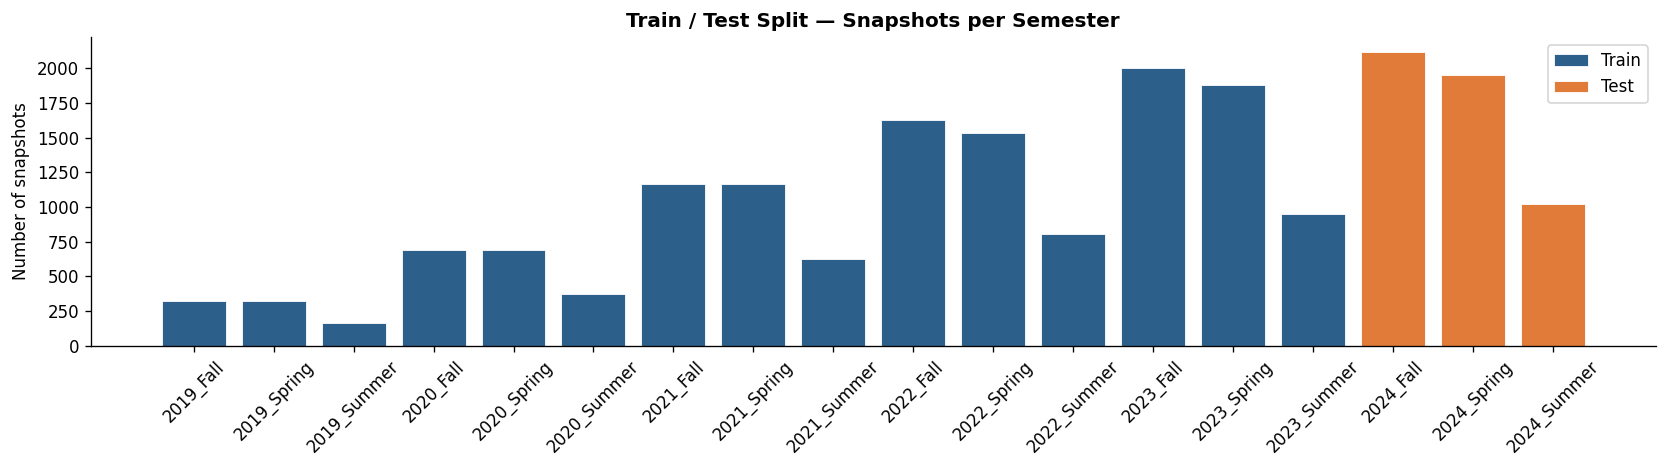

In [55]:
# ── Figure 6: Train/Test split visualisation ─────────────────────────────────
split_stats = pd.concat([
    df_train.groupby("snapshot_sem").size().rename("count").to_frame().assign(split="Train"),
    df_test.groupby("snapshot_sem").size().rename("count").to_frame().assign(split="Test"),
]).reset_index()

split_stats["sem_sort"] = (
    split_stats["snapshot_sem"].apply(lambda s: int(s.split("_")[0])) * 10
    + split_stats["snapshot_sem"].apply(lambda s: TERM_ORDER[s.split("_")[1]])
)
split_stats = split_stats.sort_values("sem_sort")

fig, ax = plt.subplots(figsize=(14, 4))
colors = {"Train": PAL["primary"], "Test": PAL["secondary"]}
for _, row in split_stats.iterrows():
    ax.bar(row["snapshot_sem"], row["count"], color=colors[row["split"]],
           label=row["split"], edgecolor="white", linewidth=0.5)

handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), fontsize=10)
ax.set_title("Train / Test Split — Snapshots per Semester", fontweight="bold")
ax.set_ylabel("Number of snapshots")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "fig06_train_test_split.png"), bbox_inches="tight")
plt.show()


## Section 6 — Per-Course Model Training

This is where the flexibility of Pipeline 1 meets the per-course separation: for **each target course** and **each model type in `MODELS`**, we run a `GridSearchCV` with stratified k-fold CV and record the best estimator + metrics.

The structure is:

```
all_model_results[course_code][model_name] = {
    "best_model":    fitted sklearn estimator,
    "best_params":   chosen hyperparameters,
    "cv_score":      best CV score (AUC by default),
    "test_metrics":  {auc, f1, precision, recall, avg_prec},
    "feature_names": list of feature column names used,
    "scaler":        fitted StandardScaler,
}
```

Why per-course separate training: adding a new course to the university plan doesn't invalidate any existing model. Retraining can be scheduled per course. This is the **agility** requirement from the report.

**Memory note**: 4 models × ~50 courses × GridSearchCV combinations can take 30–90 minutes depending on hardware. Start with a coarser grid to iterate, then expand once you're happy with the pipeline.


In [56]:
### all models run at once 


# # ── Section 6: Training loop ─────────────────────────────────────────────────
# all_model_results = defaultdict(dict)
# cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
# timing = {}

# total_courses = len(target_courses)
# print(f"Training {len(MODELS)} model types x {total_courses} courses")
# print(f"CV folds: {CV_FOLDS}   Search metric: {SEARCH_METRIC}")
# print(f"(Estimated time: {total_courses * len(MODELS) * 2}s - {total_courses * len(MODELS) * 30}s)")
# print("=" * 70)

# for model_name, (ModelClass, base_kwargs) in MODELS.items():
#     t_model = time.time()
#     print(f"\n{'#' * 70}\n### MODEL: {model_name}\n{'#' * 70}")

#     for i, course_code in enumerate(target_courses):
#         # ── Assemble features for THIS target course ──────────────────────────
#         feats_all, y_all, meta_all = assemble_for_course(snapshot_with_target, course_code)

#         # Split into train/test using the same boundary
#         train_sel = meta_all["sem_sort_key"] <= train_boundary
#         test_sel  = meta_all["sem_sort_key"] >  train_boundary

#         feats_train = feats_all.loc[train_sel.values]
#         y_train     = y_all.loc[train_sel.values].values
#         feats_test  = feats_all.loc[test_sel.values]
#         y_test      = y_all.loc[test_sel.values].values

#         n_pos_train = int(y_train.sum())
#         n_pos_test  = int(y_test.sum())

#         if n_pos_train < MIN_POSITIVE_SAMPLES:
#             all_model_results[course_code][model_name] = {
#                 "skipped": True, "reason": "too_few_positives",
#                 "n_pos_train": n_pos_train, "n_pos_test": n_pos_test
#             }
#             continue
#         # Also skip if the single class dominates (CV would fail to stratify)
#         if n_pos_train >= len(y_train) - 1 or n_pos_train <= 1:
#             all_model_results[course_code][model_name] = {
#                 "skipped": True, "reason": "single_class_dominant",
#                 "n_pos_train": n_pos_train, "n_pos_test": n_pos_test
#             }
#             continue

#         # ── Build X matrices ──────────────────────────────────────────────────
#         cat_c, core_n, num_ext, ext_flags = split_feature_columns(feats_all)
#         X_train, scaler, feature_names = build_X(
#             feats_train, ohe_encoder=ohe, fit_scaler=True,
#             cat_features=cat_c, num_features_student=core_n,
#             numeric_extras=num_ext, extra_flags=ext_flags,
#         )
#         X_test, _, _ = build_X(
#             feats_test, ohe_encoder=ohe, scaler=scaler, fit_scaler=False,
#             cat_features=cat_c, num_features_student=core_n,
#             numeric_extras=num_ext, extra_flags=ext_flags,
#         )

#         # Guard against empty test set (can happen when no data falls after the boundary)
#         has_test = len(X_test) > 0

#         # ── Model setup with imbalance handling ───────────────────────────────
#         kwargs = dict(base_kwargs)
#         if IMBALANCE_STRATEGY == "class_weight":
#             try:
#                 test_inst = ModelClass(**kwargs)
#                 if "class_weight" in test_inst.get_params():
#                     kwargs.setdefault("class_weight", "balanced")
#             except TypeError:
#                 pass

#         # ── GridSearchCV ──────────────────────────────────────────────────────
#         param_grid = PARAM_GRIDS.get(model_name, {})
#         gs = GridSearchCV(
#             estimator=ModelClass(**kwargs),
#             param_grid=param_grid,
#             cv=cv, scoring=SEARCH_METRIC, n_jobs=-1, refit=True,
#             error_score=0.0,
#         )
#         try:
#             gs.fit(X_train, y_train)
#         except Exception as e:
#             all_model_results[course_code][model_name] = {
#                 "skipped": True, "reason": f"fit_error: {e}",
#                 "n_pos_train": n_pos_train, "n_pos_test": n_pos_test
#             }
#             continue

#         best_model  = gs.best_estimator_
#         best_params = gs.best_params_
#         cv_score    = gs.best_score_

#         # ── Evaluate on test set ──────────────────────────────────────────────
#         if has_test:
#             if hasattr(best_model, "predict_proba"):
#                 y_prob = best_model.predict_proba(X_test)[:, 1]
#             else:
#                 y_prob = best_model.predict(X_test).astype(float)
#             y_pred = (y_prob >= ENROLL_THRESHOLD).astype(int)
#             test_metrics = {
#                 "auc":         roc_auc_score(y_test, y_prob) if n_pos_test > 0 else np.nan,
#                 "f1":          f1_score(y_test, y_pred, zero_division=0),
#                 "precision":   precision_score(y_test, y_pred, zero_division=0),
#                 "recall":      recall_score(y_test, y_pred, zero_division=0),
#                 "avg_prec":    average_precision_score(y_test, y_prob) if n_pos_test > 0 else np.nan,
#                 "n_pos_train": n_pos_train,
#                 "n_pos_test":  n_pos_test,
#             }
#         else:
#             test_metrics = {
#                 "auc": np.nan, "f1": np.nan, "precision": np.nan,
#                 "recall": np.nan, "avg_prec": np.nan,
#                 "n_pos_train": n_pos_train, "n_pos_test": 0,
#             }

#         all_model_results[course_code][model_name] = {
#             "best_model":    best_model,
#             "best_params":   best_params,
#             "cv_score":      cv_score,
#             "test_metrics":  test_metrics,
#             "feature_names": feature_names,
#             "scaler":        scaler,
#             "n_train":       len(X_train),
#             "n_test":        len(X_test),
#             "skipped":       False,
#         }

#         # Progress line every 10 courses
#         if (i + 1) % 10 == 0:
#             print(f"  [{i+1:>3}/{total_courses}] {course_code}: "
#                   f"CV={cv_score:.3f}  Test AUC={test_metrics['auc']:.3f}")

#     elapsed = time.time() - t_model
#     timing[model_name] = elapsed
#     aucs = [r["test_metrics"]["auc"] for r in all_model_results.values()
#             if model_name in r and not r[model_name].get("skipped")
#             and not np.isnan(r[model_name]["test_metrics"]["auc"])]
#     mean_auc = np.nanmean(aucs) if aucs else float("nan")
#     print(f"  Finished {model_name}: mean AUC = {mean_auc:.3f}, time = {elapsed:.1f}s")

# print("\n" + "=" * 70)
# print("ALL MODELS TRAINED")
# print("=" * 70)


In [59]:
# ── Section 6.0: Checkpointing & Training Helper ─────────────────────────────
import os
import time
import joblib
from collections import defaultdict
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, average_precision_score
import numpy as np

# File paths for saving progress
CHECKPOINT_FILE = os.path.join(ARTIFACTS_DIR, "all_model_results_checkpoint.pkl")
TIMING_FILE = os.path.join(ARTIFACTS_DIR, "model_timing_checkpoint.pkl")

# Load existing progress if it exists, otherwise start fresh
if os.path.exists(CHECKPOINT_FILE):
    all_model_results = joblib.load(CHECKPOINT_FILE)
    print(f"Loaded existing training progress from {CHECKPOINT_FILE}")
else:
    all_model_results = defaultdict(dict)
    print("Starting fresh training session (no checkpoint found).")

if os.path.exists(TIMING_FILE):
    timing = joblib.load(TIMING_FILE)
else:
    timing = {}

cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

def train_specific_model(model_name):
    """
    Trains a specific model type across all target courses. 
    Skips courses that have already been trained and saved.
    """
    if model_name not in MODELS:
        print(f"Error: '{model_name}' not found in MODELS dictionary.")
        return

    ModelClass, base_kwargs = MODELS[model_name]
    total_courses = len(target_courses)
    
    print(f"\n{'#' * 70}\n### MODEL: {model_name}\n{'#' * 70}")
    t_model = time.time()
    
    courses_trained_this_run = 0

    for i, course_code in enumerate(target_courses):
        # ── CHECKPOINT CHECK: SKIP IF ALREADY TRAINED ────────────────────────
        if model_name in all_model_results.get(course_code, {}):
            # Print a subtle message every 10 skips to avoid spamming the console
            if (i + 1) % 10 == 0:
                print(f"  [{i+1:>3}/{total_courses}] {course_code}: {model_name} ALREADY TRAINED. Skipping.")
            continue

        courses_trained_this_run += 1

        # ── Assemble features for THIS target course ─────────────────────────
        feats_all, y_all, meta_all = assemble_for_course(snapshot_with_target, course_code)

        # Split into train/test using the same boundary
        train_sel = meta_all["sem_sort_key"] <= train_boundary
        test_sel  = meta_all["sem_sort_key"] >  train_boundary

        feats_train = feats_all.loc[train_sel.values]
        y_train     = y_all.loc[train_sel.values].values
        feats_test  = feats_all.loc[test_sel.values]
        y_test      = y_all.loc[test_sel.values].values

        n_pos_train = int(y_train.sum())
        n_pos_test  = int(y_test.sum())

        if n_pos_train < MIN_POSITIVE_SAMPLES:
            all_model_results[course_code][model_name] = {
                "skipped": True, "reason": "too_few_positives",
                "n_pos_train": n_pos_train, "n_pos_test": n_pos_test
            }
            joblib.dump(all_model_results, CHECKPOINT_FILE)
            continue
            
        if n_pos_train >= len(y_train) - 1 or n_pos_train <= 1:
            all_model_results[course_code][model_name] = {
                "skipped": True, "reason": "single_class_dominant",
                "n_pos_train": n_pos_train, "n_pos_test": n_pos_test
            }
            joblib.dump(all_model_results, CHECKPOINT_FILE)
            continue

        # ── Build X matrices ─────────────────────────────────────────────────
        cat_c, core_n, num_ext, ext_flags = split_feature_columns(feats_all)
        X_train, scaler, feature_names = build_X(
            feats_train, ohe_encoder=ohe, fit_scaler=True,
            cat_features=cat_c, num_features_student=core_n,
            numeric_extras=num_ext, extra_flags=ext_flags,
        )
        X_test, _, _ = build_X(
            feats_test, ohe_encoder=ohe, scaler=scaler, fit_scaler=False,
            cat_features=cat_c, num_features_student=core_n,
            numeric_extras=num_ext, extra_flags=ext_flags,
        )

        has_test = len(X_test) > 0

        # ── Model setup with imbalance handling ──────────────────────────────
        kwargs = dict(base_kwargs)
        if IMBALANCE_STRATEGY == "class_weight":
            try:
                test_inst = ModelClass(**kwargs)
                if "class_weight" in test_inst.get_params():
                    kwargs.setdefault("class_weight", "balanced")
            except TypeError:
                pass

        # ── GridSearchCV ─────────────────────────────────────────────────────
        param_grid = PARAM_GRIDS.get(model_name, {})
        gs = GridSearchCV(
            estimator=ModelClass(**kwargs),
            param_grid=param_grid,
            cv=cv, scoring=SEARCH_METRIC, n_jobs=-1, refit=True,
            error_score=0.0,
        )
        try:
            gs.fit(X_train, y_train)
        except Exception as e:
            all_model_results[course_code][model_name] = {
                "skipped": True, "reason": f"fit_error: {e}",
                "n_pos_train": n_pos_train, "n_pos_test": n_pos_test
            }
            joblib.dump(all_model_results, CHECKPOINT_FILE)
            continue

        best_model  = gs.best_estimator_
        best_params = gs.best_params_
        cv_score    = gs.best_score_

        # ── Evaluate on test set ─────────────────────────────────────────────
        if has_test:
            if hasattr(best_model, "predict_proba"):
                y_prob = best_model.predict_proba(X_test)[:, 1]
            else:
                y_prob = best_model.predict(X_test).astype(float)
            y_pred = (y_prob >= ENROLL_THRESHOLD).astype(int)
            test_metrics = {
                "auc":         roc_auc_score(y_test, y_prob) if n_pos_test > 0 else np.nan,
                "f1":          f1_score(y_test, y_pred, zero_division=0),
                "precision":   precision_score(y_test, y_pred, zero_division=0),
                "recall":      recall_score(y_test, y_pred, zero_division=0),
                "avg_prec":    average_precision_score(y_test, y_prob) if n_pos_test > 0 else np.nan,
                "n_pos_train": n_pos_train,
                "n_pos_test":  n_pos_test,
            }
        else:
            test_metrics = {
                "auc": np.nan, "f1": np.nan, "precision": np.nan,
                "recall": np.nan, "avg_prec": np.nan,
                "n_pos_train": n_pos_train, "n_pos_test": 0,
            }

        all_model_results[course_code][model_name] = {
            "best_model":    best_model,
            "best_params":   best_params,
            "cv_score":      cv_score,
            "test_metrics":  test_metrics,
            "feature_names": feature_names,
            "scaler":        scaler,
            "n_train":       len(X_train),
            "n_test":        len(X_test),
            "skipped":       False,
        }

        # ── SAVE PROGRESS AFTER EVERY COURSE ─────────────────────────────────
        joblib.dump(all_model_results, CHECKPOINT_FILE)

        # Print progress line
        if (i + 1) % 5 == 0 or (i + 1) == total_courses:
            print(f"  [{i+1:>3}/{total_courses}] {course_code}: "
                  f"CV={cv_score:.3f}  Test AUC={test_metrics['auc']:.3f}")

    # Accumulate timing only for the courses actually trained in this session
    elapsed = time.time() - t_model
    timing[model_name] = timing.get(model_name, 0) + elapsed
    joblib.dump(timing, TIMING_FILE)

    # FIXED: Check inside r[model_name] for test_metrics
    aucs = [r[model_name]["test_metrics"]["auc"] for r in all_model_results.values()
            if model_name in r and not r[model_name].get("skipped")
            and not np.isnan(r[model_name]["test_metrics"]["auc"])]
    
    mean_auc = np.nanmean(aucs) if aucs else float("nan")
    
    print(f"  Finished {model_name} processing. Trained {courses_trained_this_run} courses this run.")
    print(f"  Mean AUC across all valid {model_name} models = {mean_auc:.3f}")

Loaded existing training progress from artifacts\all_model_results_checkpoint.pkl


In [60]:
# Train Random Forest
train_specific_model("RandomForest")


######################################################################
### MODEL: RandomForest
######################################################################
  [ 10/97] 0000203400: RandomForest ALREADY TRAINED. Skipping.
  [ 20/97] 0000204411: RandomForest ALREADY TRAINED. Skipping.
  [ 30/97] 0010203380: RandomForest ALREADY TRAINED. Skipping.
  [ 40/97] 0010204281: RandomForest ALREADY TRAINED. Skipping.
  [ 50/97] 0010204492: RandomForest ALREADY TRAINED. Skipping.
  [ 60/97] 0030302122: RandomForest ALREADY TRAINED. Skipping.
  [ 70/97] 0040201200: RandomForest ALREADY TRAINED. Skipping.
  [ 80/97] 0040201362: RandomForest ALREADY TRAINED. Skipping.
  [ 90/97] 0040201492: RandomForest ALREADY TRAINED. Skipping.
  Finished RandomForest processing. Trained 0 courses this run.
  Mean AUC across all valid RandomForest models = 0.995


In [61]:
# Train Histogram Gradient Boosting
train_specific_model("HistGradientBoosting")


######################################################################
### MODEL: HistGradientBoosting
######################################################################
  [  5/97] 0000203280: CV=0.995  Test AUC=0.998
  [ 10/97] 0000203400: CV=1.000  Test AUC=1.000
  [ 15/97] 0000204310: CV=0.989  Test AUC=0.992
  [ 20/97] 0000204411: CV=0.982  Test AUC=0.990
  [ 25/97] 0010203210: CV=0.998  Test AUC=0.999
  [ 30/97] 0010203380: CV=0.990  Test AUC=0.993
  [ 35/97] 0010203421: CV=0.957  Test AUC=1.000
  [ 40/97] 0010204281: CV=0.996  Test AUC=0.997
  [ 45/97] 0010204431: CV=0.959  Test AUC=0.974
  [ 50/97] 0010204492: CV=1.000  Test AUC=1.000
  [ 55/97] 0030301122: CV=0.996  Test AUC=0.998
  [ 60/97] 0030302122: CV=0.960  Test AUC=0.981
  [ 65/97] 0030302237: CV=1.000  Test AUC=1.000
  [ 70/97] 0040201200: CV=1.000  Test AUC=1.000
  [ 75/97] 0040201290: CV=0.997  Test AUC=0.997
  [ 80/97] 0040201362: CV=0.999  Test AUC=1.000
  [ 90/97] 0040201492: CV=1.000  Test AUC=1.000
  [ 95/97

In [ ]:
# # Train Gradient Boosting
# train_specific_model("GradientBoosting")

In [ ]:
# # Train MLP (Neural Network)
# train_specific_model("MLP")

In [62]:
# ── Section 6.5: Sync results for Evaluation ─────────────────────────────────
if os.path.exists(CHECKPOINT_FILE):
    all_model_results = joblib.load(CHECKPOINT_FILE)
if os.path.exists(TIMING_FILE):
    timing = joblib.load(TIMING_FILE)

# Figure out how many models actually got trained
trained_models_detected = set()
courses_with_models = 0

for course_code, model_dict in all_model_results.items():
    if len(model_dict) > 0:
        courses_with_models += 1
    for model_name in model_dict.keys():
        trained_models_detected.add(model_name)

print("\n" + "=" * 70)
print("TRAINING PHASE COMPLETE / SYNCED")
print("=" * 70)
print(f"Courses with at least one model: {courses_with_models} / {len(target_courses)}")
print(f"Model types detected in saved results: {list(trained_models_detected)}")
print("You may now proceed to Section 7 (Evaluation).")


TRAINING PHASE COMPLETE / SYNCED
Courses with at least one model: 97 / 97
Model types detected in saved results: ['HistGradientBoosting', 'RandomForest']
You may now proceed to Section 7 (Evaluation).


## Section 7 — Evaluation

This section produces all the model-comparison visuals from Pipeline 1 plus the learning curve from Pipeline 2, then selects the single best model per course.

We look at four classification metrics (AUC, F1, Precision, Recall) and training time. For AUC we plot distributions and a course-level heatmap so you can see which courses are easy/hard for which model families.


In [63]:
# ── Section 7.1: Build the results summary DataFrame ─────────────────────────
rows = []
for course_code, model_dict in all_model_results.items():
    for model_name, res in model_dict.items():
        if res.get("skipped"):
            continue
        m = res["test_metrics"]
        rows.append({
            "course_code": course_code,
            "model":       model_name,
            "cv_score":    res["cv_score"],
            "auc":         m["auc"],
            "f1":          m["f1"],
            "precision":   m["precision"],
            "recall":      m["recall"],
            "avg_prec":    m["avg_prec"],
            "n_pos_train": m["n_pos_train"],
            "n_pos_test":  m["n_pos_test"],
            "n_train":     res["n_train"],
            "n_test":      res["n_test"],
        })
results_df = pd.DataFrame(rows)

# Mean metrics per model
summary = (results_df.groupby("model")[["auc","f1","precision","recall","avg_prec"]]
           .agg(["mean","std","median"])
           .round(4))
print("Model-level summary (mean / std / median across courses):")
print(summary.to_string())
print()
print(f"Total (course, model) pairs evaluated: {len(results_df)}")
print(f"Courses with at least one successful model: {results_df['course_code'].nunique()}")


Model-level summary (mean / std / median across courses):
                         auc                      f1                 precision                  recall                 avg_prec                
                        mean     std  median    mean     std  median      mean     std  median    mean     std  median     mean     std  median
model                                                                                                                                          
HistGradientBoosting  0.9924  0.0155  0.9982  0.8210  0.1901  0.9044    0.7487  0.2366  0.8419  0.9523  0.0776  0.9812   0.8663  0.1944  0.9502
RandomForest          0.9952  0.0069  0.9983  0.8236  0.1892  0.8961    0.7931  0.2188  0.8664  0.8772  0.1593  0.9426   0.8629  0.2020  0.9542

Total (course, model) pairs evaluated: 188
Courses with at least one successful model: 94


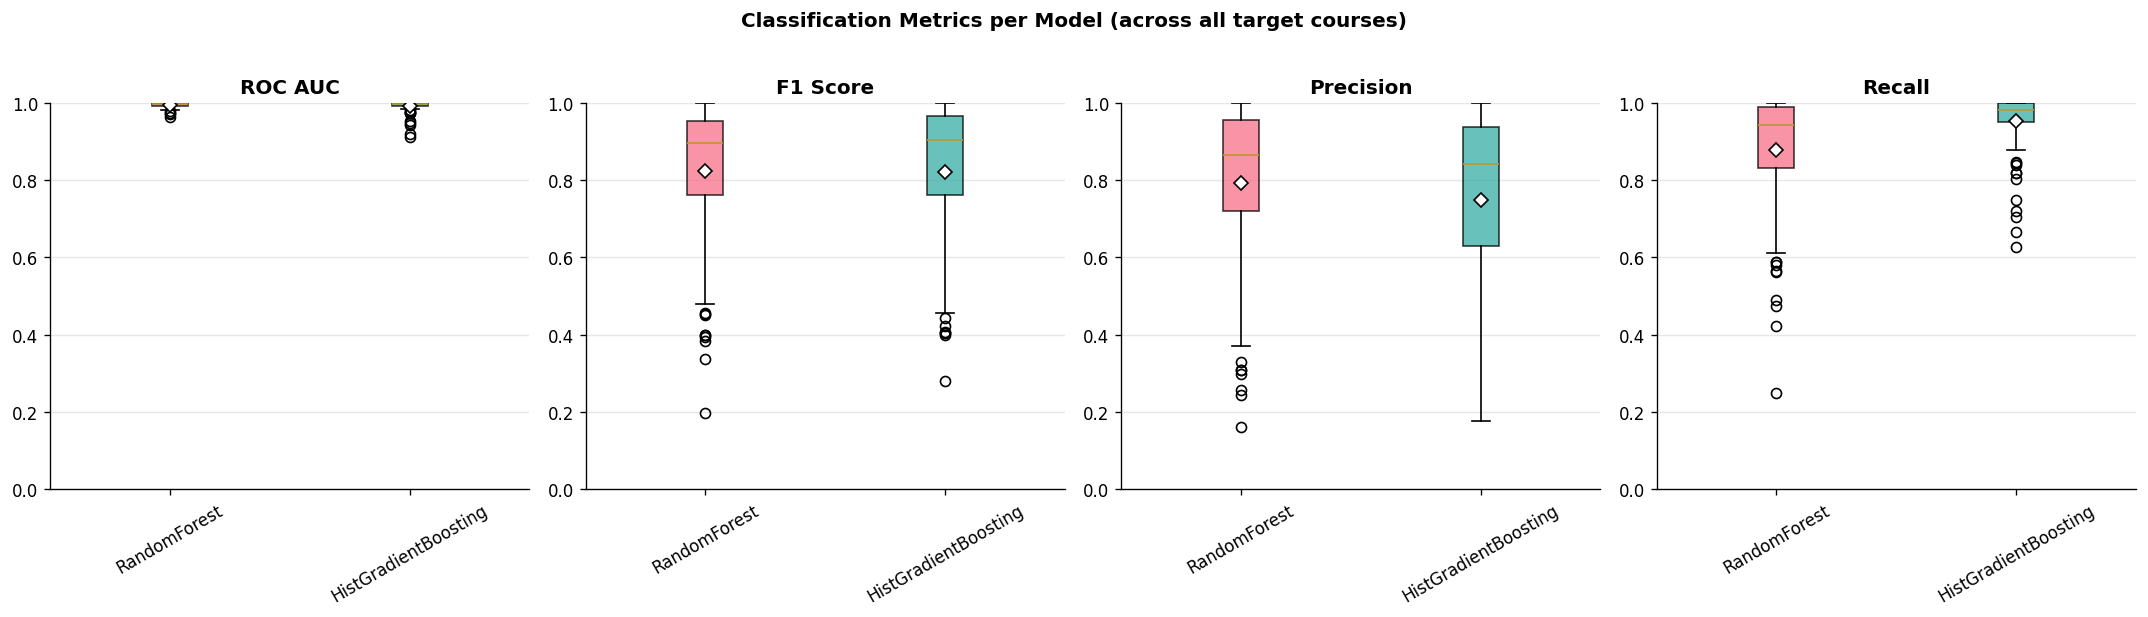

In [64]:
# ── Figure 7: Model comparison box plots (AUC, F1, Precision, Recall) ────────
# (Pipeline 1 visual — box plot of each metric across courses, grouped by model)
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

metrics_to_plot = [
    ("auc",       "ROC AUC"),
    ("f1",        "F1 Score"),
    ("precision", "Precision"),
    ("recall",    "Recall"),
]
for ax, (metric, title) in zip(axes, metrics_to_plot):
    data_for_plot = [results_df[results_df["model"]==m][metric].dropna().values
                     for m in MODELS.keys()]
    bp = ax.boxplot(data_for_plot, labels=list(MODELS.keys()), patch_artist=True,
                    showmeans=True, meanline=False, meanprops={"marker":"D",
                    "markerfacecolor":"white","markeredgecolor":"black"})
    colors = sns.color_palette("husl", len(MODELS))
    for patch, col in zip(bp["boxes"], colors):
        patch.set_facecolor(col); patch.set_alpha(0.75)
    ax.set_title(title, fontweight="bold")
    ax.tick_params(axis="x", rotation=30)
    ax.grid(axis="y", alpha=0.3)
    ax.set_ylim(0, 1)

plt.suptitle("Classification Metrics per Model (across all target courses)",
             fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "fig07_model_metrics_boxplots.png"), bbox_inches="tight")
plt.show()


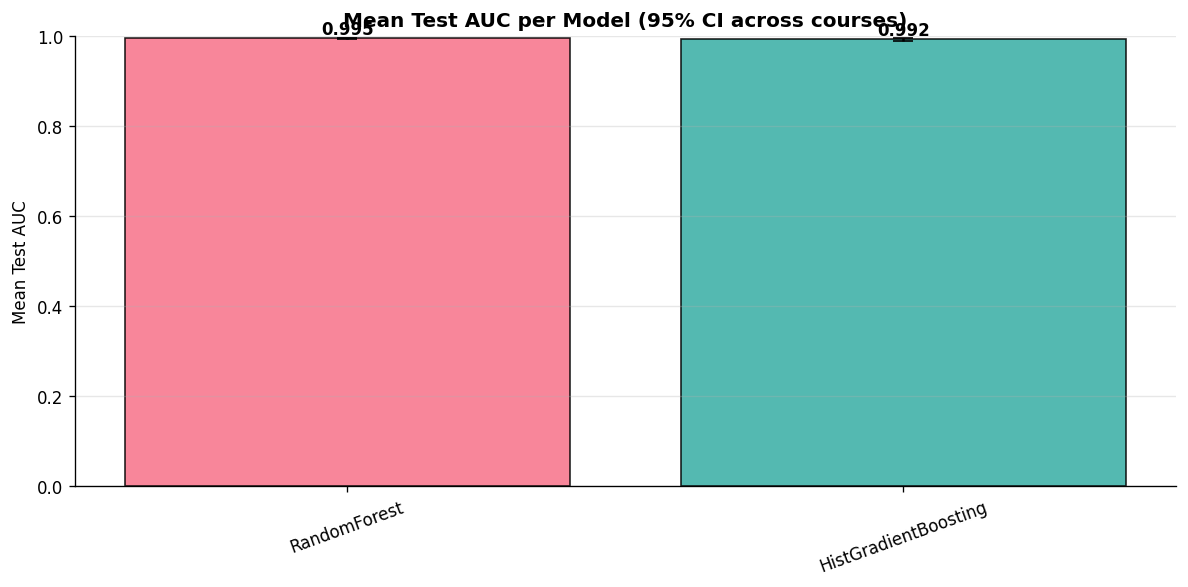

In [65]:
# ── Figure 8: Mean AUC per model with 95% CI bar chart ───────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

stats_df = (results_df.groupby("model")["auc"]
            .agg(["mean","std","count"]).reset_index())
stats_df["ci95"] = 1.96 * stats_df["std"] / np.sqrt(stats_df["count"])

models_list = list(MODELS.keys())
colors = sns.color_palette("husl", len(models_list))
x_pos = np.arange(len(models_list))
means = [stats_df[stats_df["model"]==m]["mean"].iloc[0]
         if len(stats_df[stats_df["model"]==m]) else 0 for m in models_list]
cis   = [stats_df[stats_df["model"]==m]["ci95"].iloc[0]
         if len(stats_df[stats_df["model"]==m]) else 0 for m in models_list]

bars = ax.bar(x_pos, means, yerr=cis, color=colors, alpha=0.85,
              edgecolor="black", linewidth=1, capsize=6,
              error_kw={"linewidth":1.5})
for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{mean:.3f}", ha="center", fontweight="bold", fontsize=10)

ax.set_xticks(x_pos); ax.set_xticklabels(models_list, rotation=20)
ax.set_ylabel("Mean Test AUC")
ax.set_title("Mean Test AUC per Model (95% CI across courses)", fontweight="bold")
ax.set_ylim(0, 1.0)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "fig08_auc_with_ci.png"), bbox_inches="tight")
plt.show()


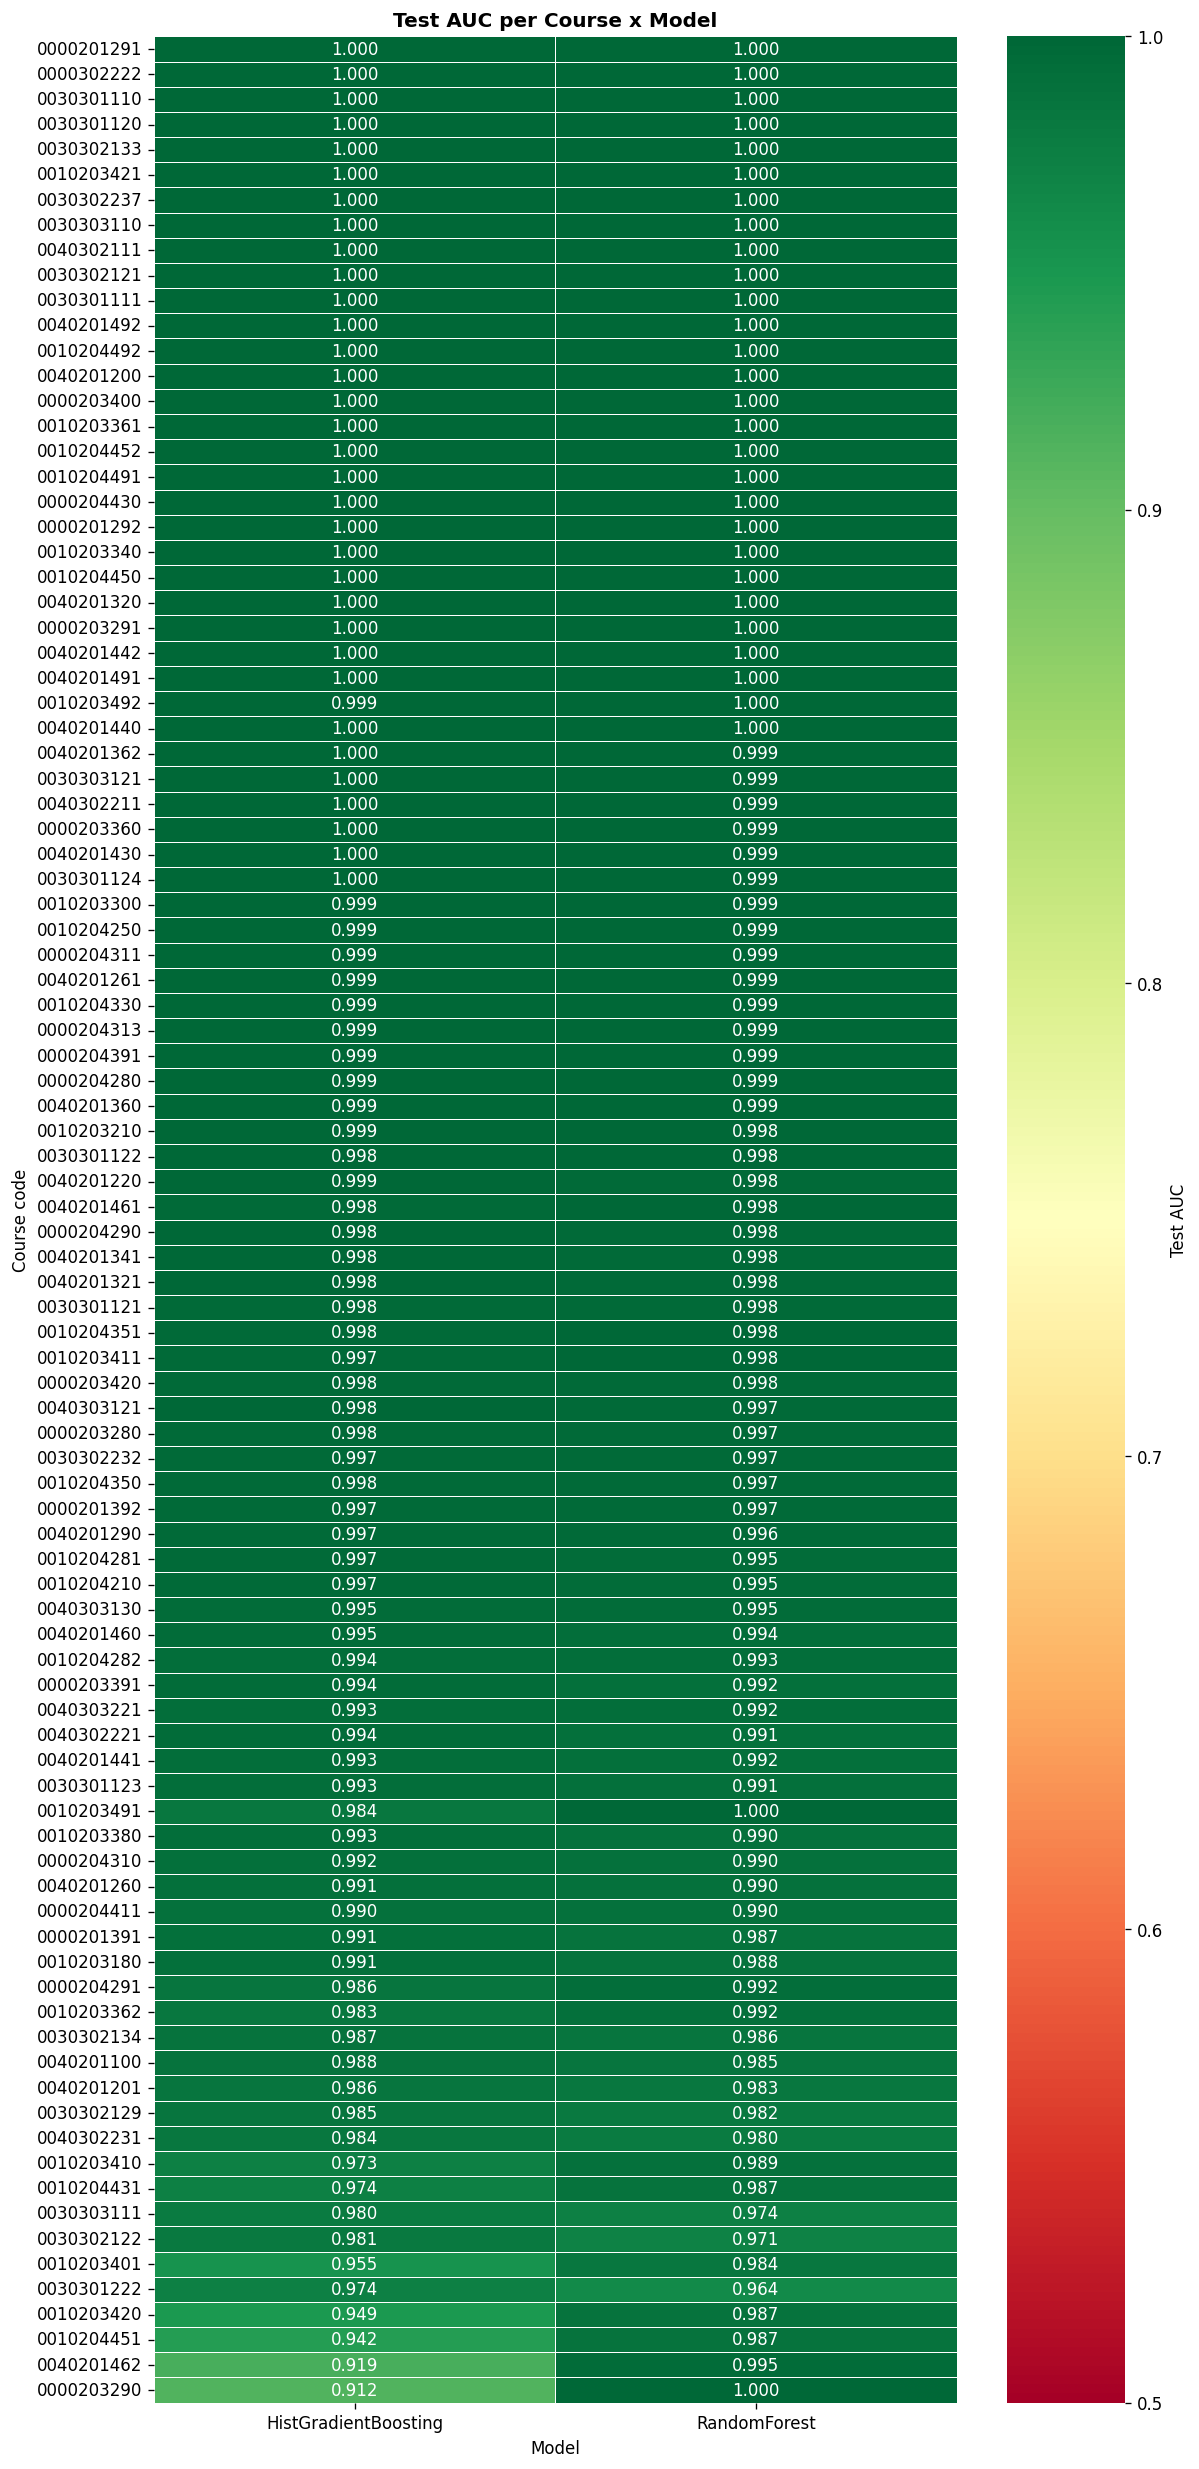

In [66]:
# ── Figure 9: AUC heatmap (courses x models) ─────────────────────────────────
# Shows which courses are hard / easy across model families.
auc_pivot = results_df.pivot(index="course_code", columns="model", values="auc")

# Sort courses by mean AUC across models (hardest at top)
auc_pivot["mean_auc"] = auc_pivot.mean(axis=1)
auc_pivot = auc_pivot.sort_values("mean_auc", ascending=False).drop(columns="mean_auc")

fig_height = max(10, 0.22 * len(auc_pivot))
fig, ax = plt.subplots(figsize=(10, fig_height))
sns.heatmap(auc_pivot, annot=True, fmt=".3f", cmap="RdYlGn",
            vmin=0.5, vmax=1.0, center=0.75,
            cbar_kws={"label":"Test AUC"}, ax=ax, linewidths=0.5)
ax.set_title("Test AUC per Course x Model", fontweight="bold")
ax.set_xlabel("Model"); ax.set_ylabel("Course code")
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "fig09_auc_heatmap.png"), bbox_inches="tight")
plt.show()


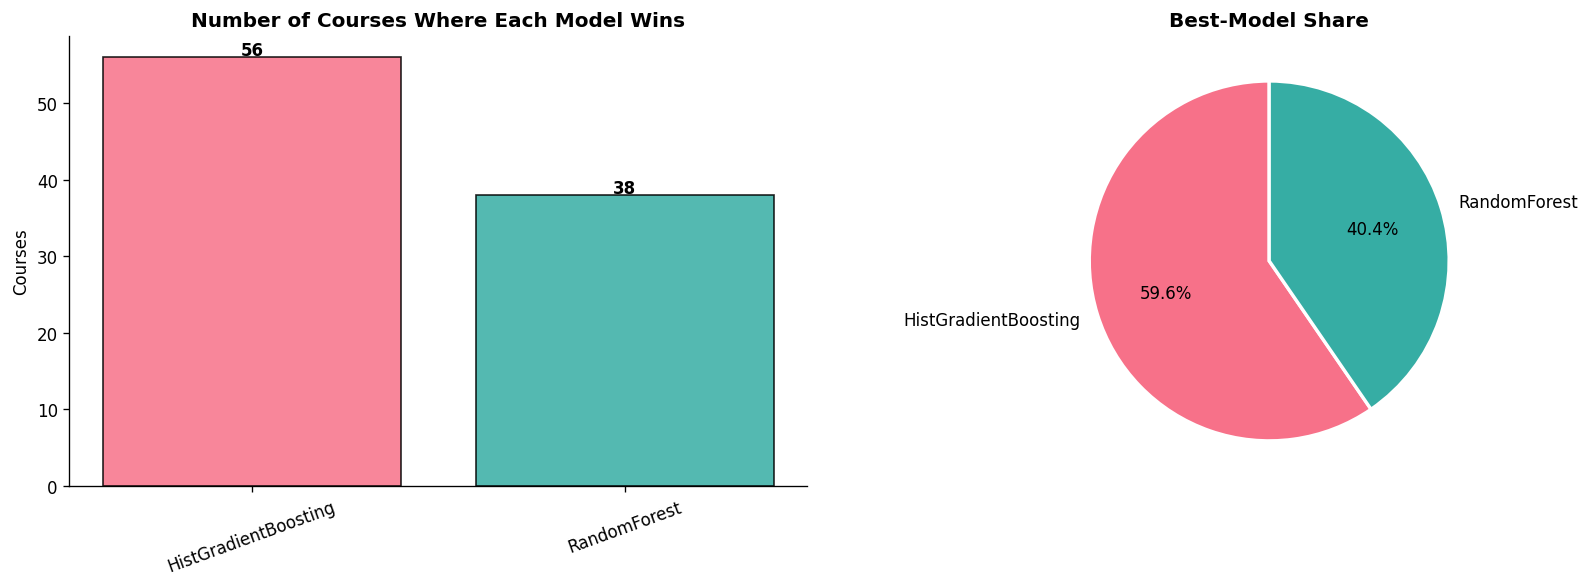


Best-model-per-course table (top 10 by AUC):
course_code   best_model  auc       f1
 0000201291 RandomForest  1.0 1.000000
 0000203290 RandomForest  1.0 0.952381
 0000302222 RandomForest  1.0 1.000000
 0030301120 RandomForest  1.0 1.000000
 0010204452 RandomForest  1.0 1.000000
 0040302111 RandomForest  1.0 1.000000
 0030302237 RandomForest  1.0 1.000000
 0030303110 RandomForest  1.0 0.888889
 0030302133 RandomForest  1.0 1.000000
 0030302121 RandomForest  1.0 1.000000


In [67]:
# ── Figure 10: Best model per course — distribution and pie ──────────────────
# Pick the best model for each course by test AUC
best_per_course_rows = []
for course_code, model_dict in all_model_results.items():
    candidates = [(name, res) for name, res in model_dict.items()
                  if not res.get("skipped")
                  and not np.isnan(res["test_metrics"]["auc"])]
    if not candidates:
        continue
    best_name, best_res = max(candidates, key=lambda kv: kv[1]["test_metrics"]["auc"])
    best_per_course_rows.append({
        "course_code":   course_code,
        "best_model":    best_name,
        "auc":           best_res["test_metrics"]["auc"],
        "f1":            best_res["test_metrics"]["f1"],
        "best_params":   best_res["best_params"],
    })
best_per_course_df = pd.DataFrame(best_per_course_rows).sort_values("auc", ascending=False)

# Build dict form for downstream use
best_per_course = {
    row["course_code"]: all_model_results[row["course_code"]][row["best_model"]]
    | {"best_model_name": row["best_model"]}
    for _, row in best_per_course_df.iterrows()
}

# ── Plot: count of wins + pie ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
wins = best_per_course_df["best_model"].value_counts()
colors = sns.color_palette("husl", len(wins))

axes[0].bar(wins.index, wins.values, color=colors, alpha=0.85, edgecolor="black")
for i, (m, v) in enumerate(wins.items()):
    axes[0].text(i, v + 0.3, str(v), ha="center", fontweight="bold")
axes[0].set_title("Number of Courses Where Each Model Wins", fontweight="bold")
axes[0].set_ylabel("Courses")
axes[0].tick_params(axis="x", rotation=20)

axes[1].pie(wins.values, labels=wins.index, colors=colors, autopct="%1.1f%%",
            startangle=90, wedgeprops={"edgecolor":"white","linewidth":2})
axes[1].set_title("Best-Model Share", fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "fig10_best_model_distribution.png"), bbox_inches="tight")
plt.show()

print(f"\nBest-model-per-course table (top 10 by AUC):")
print(best_per_course_df[["course_code","best_model","auc","f1"]].head(10).to_string(index=False))


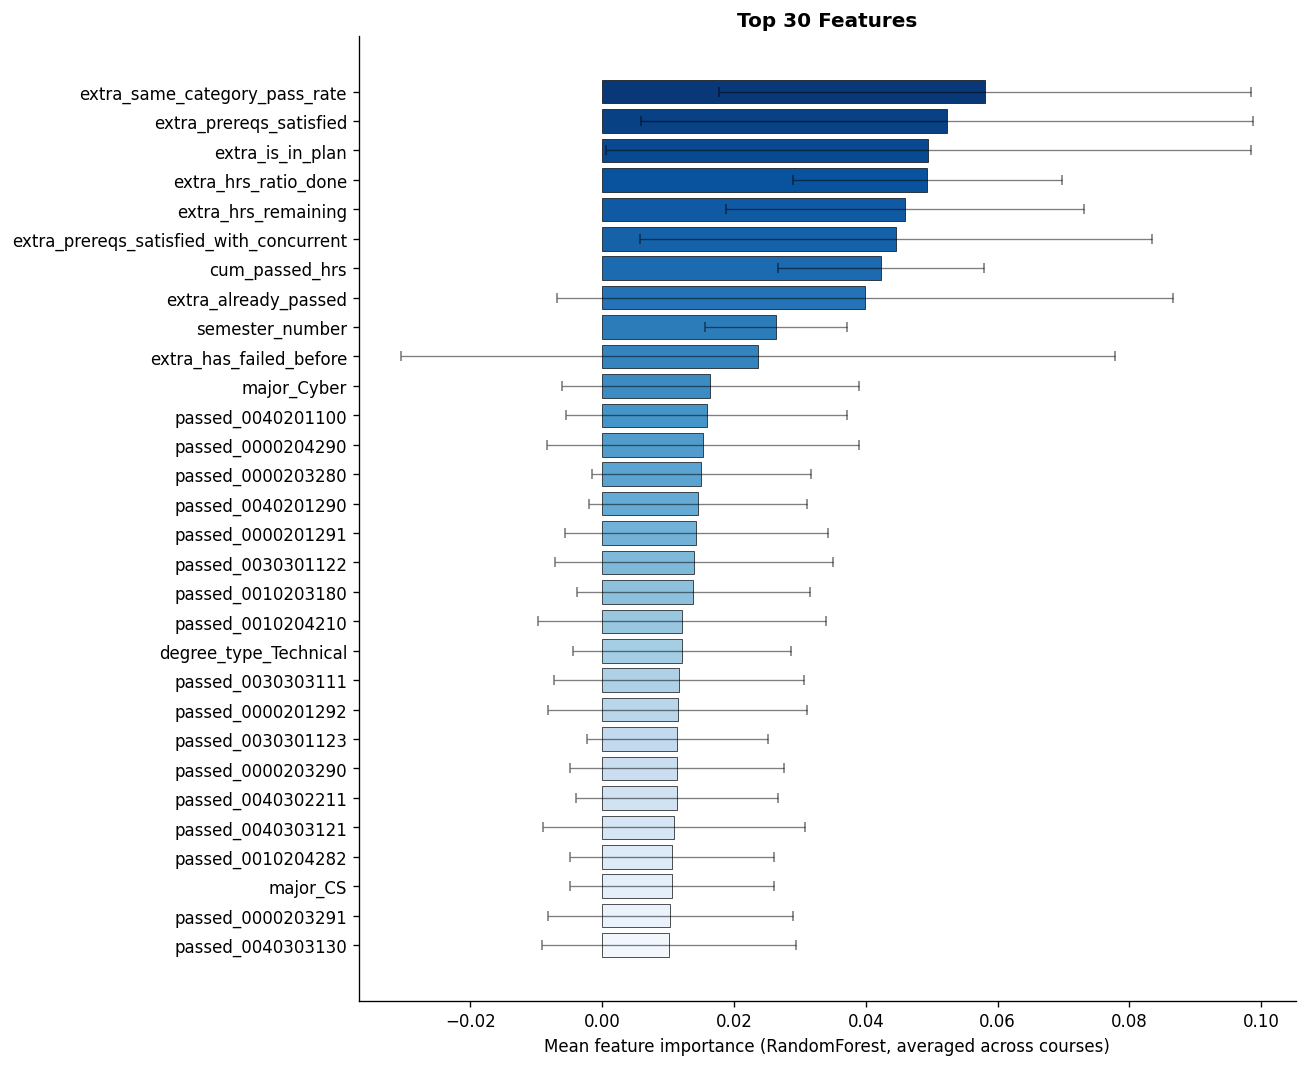

In [68]:
# ── Figure 11: Feature importance (top 30, averaged across RF models) ────────
# We use RandomForest because it has built-in feature_importances_ and gives
# interpretable per-feature scores. Any tree-based model would work.
rf_importance_rows = []
for course_code, model_dict in all_model_results.items():
    res = model_dict.get("RandomForest")
    if not res or res.get("skipped"):
        continue
    m = res["best_model"]
    if hasattr(m, "feature_importances_"):
        for name, imp in zip(res["feature_names"], m.feature_importances_):
            rf_importance_rows.append({"feature": name, "importance": imp})

if rf_importance_rows:
    fi_df = (pd.DataFrame(rf_importance_rows)
             .groupby("feature")["importance"]
             .agg(["mean","std","count"]).reset_index()
             .sort_values("mean", ascending=False)
             .head(30))

    fig, ax = plt.subplots(figsize=(11, 9))
    bars = ax.barh(fi_df["feature"], fi_df["mean"],
                   xerr=fi_df["std"], color=sns.color_palette("Blues_r", len(fi_df)),
                   edgecolor="black", linewidth=0.4, capsize=3,
                   error_kw={"linewidth":0.8, "alpha":0.5})
    ax.set_xlabel("Mean feature importance (RandomForest, averaged across courses)")
    ax.set_title("Top 30 Features", fontweight="bold")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig(os.path.join(PLOT_DIR, "fig11_feature_importance.png"), bbox_inches="tight")
    plt.show()
else:
    print("No RandomForest feature importance available (no RF models trained).")


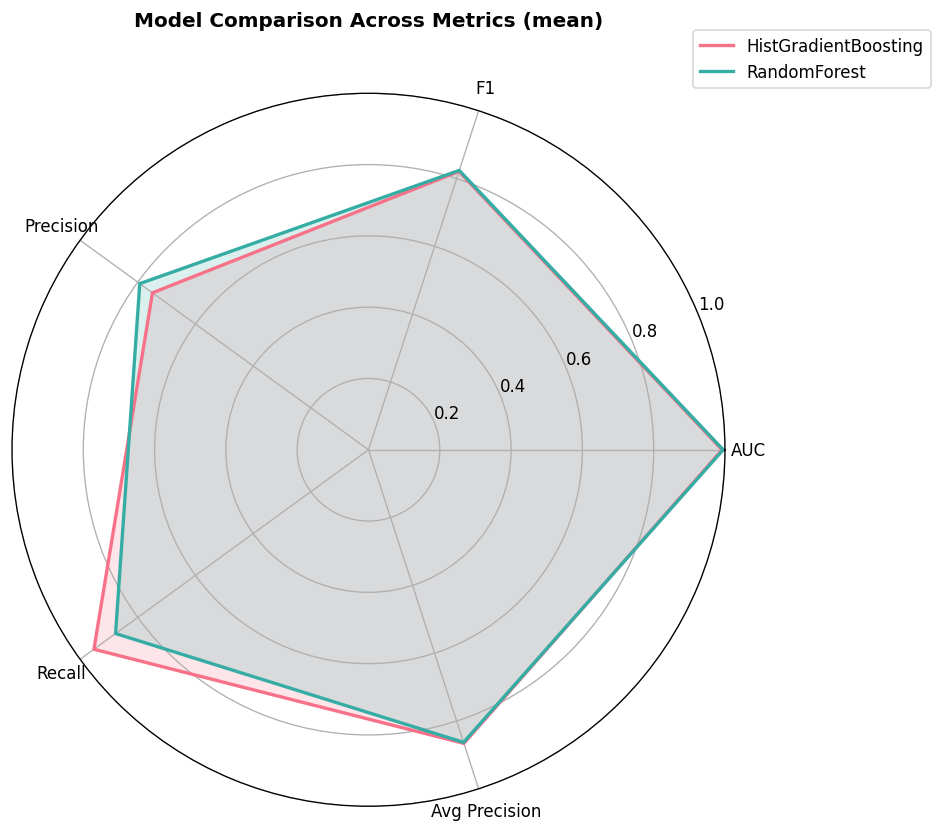

In [69]:
# ── Figure 12: Radar chart — per-model multi-metric comparison ───────────────
metrics_for_radar = ["auc","f1","precision","recall","avg_prec"]
metric_labels     = ["AUC","F1","Precision","Recall","Avg Precision"]
radar_stats = (results_df.groupby("model")[metrics_for_radar]
               .mean().round(3))

angles = np.linspace(0, 2*np.pi, len(metrics_for_radar), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection":"polar"})
colors = sns.color_palette("husl", len(radar_stats))
for (model_name, row), col in zip(radar_stats.iterrows(), colors):
    values = row.values.tolist()
    values += values[:1]
    ax.plot(angles, values, "-", linewidth=2, color=col, label=model_name)
    ax.fill(angles, values, alpha=0.18, color=col)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metric_labels, size=10)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_title("Model Comparison Across Metrics (mean)", fontweight="bold", y=1.08)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "fig12_radar.png"), bbox_inches="tight")
plt.show()


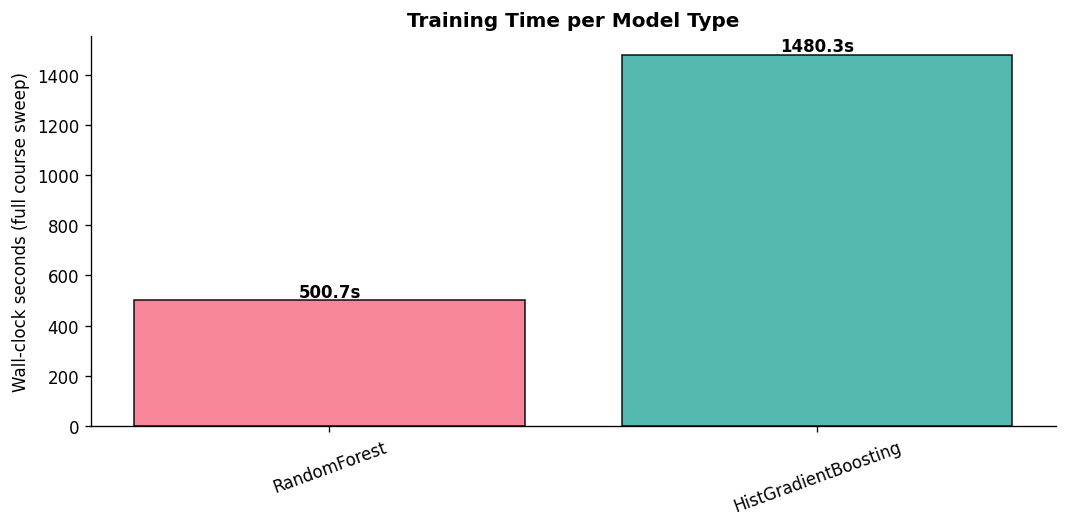

In [70]:
# ── Figure 13: Training time comparison ──────────────────────────────────────
if timing:
    fig, ax = plt.subplots(figsize=(9, 4.5))
    models_list = list(timing.keys())
    times = [timing[m] for m in models_list]
    colors = sns.color_palette("husl", len(models_list))
    bars = ax.bar(models_list, times, color=colors, alpha=0.85, edgecolor="black")
    for bar, t in zip(bars, times):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(times)*0.01,
                f"{t:.1f}s", ha="center", fontweight="bold", fontsize=10)
    ax.set_ylabel("Wall-clock seconds (full course sweep)")
    ax.set_title("Training Time per Model Type", fontweight="bold")
    ax.tick_params(axis="x", rotation=20)
    plt.tight_layout()
    plt.savefig(os.path.join(PLOT_DIR, "fig13_training_time.png"), bbox_inches="tight")
    plt.show()


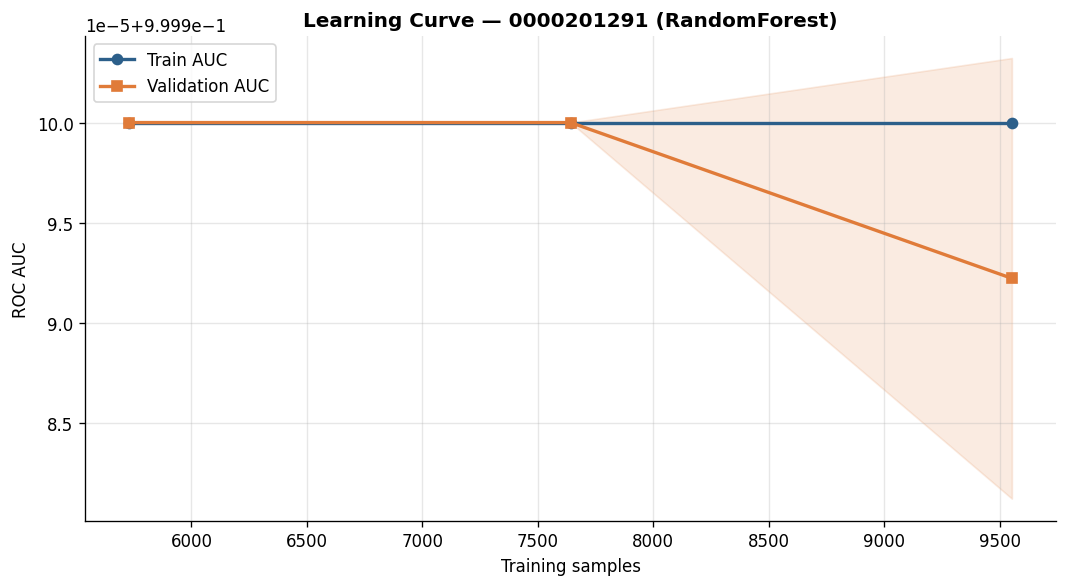

In [71]:
# ── Figure 14 [from P2]: Learning curve for the best model of the biggest course ──
# A learning curve shows how much MORE data would help — if it's still steeply
# rising, collect more data; if it's plateaued, the bottleneck is the model.
biggest_course = (results_df.groupby("course_code")["n_train"].first()
                  .sort_values(ascending=False).index[0])
best_for_biggest = best_per_course.get(biggest_course)
if best_for_biggest:
    # Rebuild X_train, y_train for that course
    feats_all, y_all, meta_all = assemble_for_course(snapshot_with_target, biggest_course)
    train_sel = meta_all["sem_sort_key"] <= train_boundary
    feats_train = feats_all.loc[train_sel.values]
    y_train_lc  = y_all.loc[train_sel.values].values

    cat_c, core_n, num_ext, ext_flags = split_feature_columns(feats_all)
    X_train_lc, _, _ = build_X(
        feats_train, ohe_encoder=ohe, fit_scaler=True,
        cat_features=cat_c, num_features_student=core_n,
        numeric_extras=num_ext, extra_flags=ext_flags,
    )

    try:
        train_sizes, train_scores, val_scores = learning_curve(
            best_for_biggest["best_model"].__class__(
                **best_for_biggest["best_model"].get_params()
            ),
            X_train_lc, y_train_lc,
            train_sizes=np.linspace(0.2, 1.0, 5),
            cv=3, scoring="roc_auc", n_jobs=-1
        )

        fig, ax = plt.subplots(figsize=(9, 5))
        train_mean = train_scores.mean(axis=1); train_std = train_scores.std(axis=1)
        val_mean   = val_scores.mean(axis=1);   val_std   = val_scores.std(axis=1)

        ax.plot(train_sizes, train_mean, "o-", color=PAL["primary"], label="Train AUC", linewidth=2)
        ax.fill_between(train_sizes, train_mean-train_std, train_mean+train_std,
                        color=PAL["primary"], alpha=0.15)
        ax.plot(train_sizes, val_mean, "s-", color=PAL["secondary"], label="Validation AUC", linewidth=2)
        ax.fill_between(train_sizes, val_mean-val_std, val_mean+val_std,
                        color=PAL["secondary"], alpha=0.15)

        ax.set_xlabel("Training samples")
        ax.set_ylabel("ROC AUC")
        ax.set_title(f"Learning Curve — {biggest_course} ({best_for_biggest['best_model_name']})",
                     fontweight="bold")
        ax.legend()
        ax.grid(alpha=0.3)
        plt.tight_layout()
        plt.savefig(os.path.join(PLOT_DIR, "fig14_learning_curve.png"), bbox_inches="tight")
        plt.show()
    except Exception as e:
        print(f"Learning curve skipped: {e}")


## Section 8 — Per-Student Predictions & Aggregated Demand

This is the section that delivers the **first-class per-student output** you asked for:
- `pred_df`: one row per (student, snapshot_sem, course) with `prob_enroll`, `pred_enroll`, `actual_enroll`
- `demand_agg`: aggregated predicted vs actual demand per (course, semester)
- `sections_df`: predicted vs actual section counts using `SECTION_CAP` + buffer

Operational metrics (from Pipeline 2) are reported:
- % of predictions within ±5 / ±10 / ±15 students of actual
- % of courses where section-count prediction exactly matches
- Over-allocation vs under-allocation percentages
- MAPE for courses with ≥ 10 students


In [72]:
# ── Section 8.1: Generate per-student predictions on the test set ────────────
pred_rows = []
for course_code, best in best_per_course.items():
    feats_all, y_all, meta_all = assemble_for_course(snapshot_with_target, course_code)
    test_sel = meta_all["sem_sort_key"] > train_boundary
    feats_test = feats_all.loc[test_sel.values]
    meta_test  = meta_all.loc[test_sel.values]
    y_test     = y_all.loc[test_sel.values].values

    if len(feats_test) == 0:
        continue

    cat_c, core_n, num_ext, ext_flags = split_feature_columns(feats_all)
    X_test, _, _ = build_X(
        feats_test, ohe_encoder=ohe, scaler=best["scaler"], fit_scaler=False,
        cat_features=cat_c, num_features_student=core_n,
        numeric_extras=num_ext, extra_flags=ext_flags,
    )

    model = best["best_model"]
    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(X_test)[:, 1]
    else:
        probs = model.predict(X_test).astype(float)

    for (_, mrow), prob, actual in zip(meta_test.iterrows(), probs, y_test):
        pred_rows.append({
            "student_id":    mrow["student_id"],
            "snapshot_sem":  mrow["snapshot_sem"],
            "next_sem":      mrow["next_sem"],
            "course_code":   course_code,
            "prob_enroll":   float(prob),
            "pred_enroll":   int(prob >= ENROLL_THRESHOLD),
            "actual_enroll": int(actual),
            "model":         best["best_model_name"],
        })

pred_df = pd.DataFrame(pred_rows)
print(f"Per-student predictions generated: {len(pred_df):,} rows")
print(f"(For {pred_df['student_id'].nunique()} unique students, "
      f"{pred_df['course_code'].nunique()} courses)")
print()
print("Sample predictions:")
print(pred_df.sort_values("prob_enroll", ascending=False).head(10).to_string(index=False))

pred_df.to_csv(os.path.join(RESULTS_DIR, "per_student_predictions.csv"), index=False)
print(f"\nSaved → {os.path.join(RESULTS_DIR, 'per_student_predictions.csv')}")


Per-student predictions generated: 479,212 rows
(For 2121 unique students, 94 courses)

Sample predictions:
 student_id snapshot_sem    next_sem course_code  prob_enroll  pred_enroll  actual_enroll                model
  202002488    2024_Fall 2024_Spring  0010203361     0.999946            1              1 HistGradientBoosting
  202001832    2024_Fall 2024_Spring  0010203361     0.999945            1              1 HistGradientBoosting
  202101923    2024_Fall 2024_Spring  0010203361     0.999945            1              1 HistGradientBoosting
  202000500    2024_Fall 2024_Spring  0010203361     0.999945            1              1 HistGradientBoosting
  202000393    2024_Fall 2024_Spring  0010203361     0.999945            1              1 HistGradientBoosting
  202101146    2024_Fall 2024_Spring  0010203361     0.999944            1              1 HistGradientBoosting
  202100978    2024_Fall 2024_Spring  0010203361     0.999943            1              1 HistGradientBoosting
  20

In [73]:
# ── Section 8.2: Aggregate into course-level demand (per semester) ───────────
# Predicted demand = sum of probabilities (soft count, mathematically sound)
# Predicted-threshold demand = sum of binary predictions
demand_agg = (pred_df.groupby(["next_sem","course_code"])
              .agg(pred_prob_sum=("prob_enroll","sum"),
                   pred_binary_sum=("pred_enroll","sum"),
                   actual_count=("actual_enroll","sum"))
              .reset_index())
demand_agg["pred_prob_sum"]   = demand_agg["pred_prob_sum"].round().astype(int)
demand_agg["pred_binary_sum"] = demand_agg["pred_binary_sum"].astype(int)
demand_agg = demand_agg.merge(
    master_cat[["course_code","course_name","credit_hours","category","is_compulsory"]],
    on="course_code", how="left"
)

# Use the soft (probability sum) prediction as the main prediction — it's
# more stable and better calibrated than a hard threshold.
demand_agg["predicted_count"] = demand_agg["pred_prob_sum"]
demand_agg["abs_error"] = (demand_agg["predicted_count"] - demand_agg["actual_count"]).abs()

print(f"Course-level demand rows (course x test-semester): {len(demand_agg):,}")
print()
print("Sample demand aggregation:")
print(demand_agg.head(10).to_string(index=False))

demand_agg.to_csv(os.path.join(RESULTS_DIR, "demand_forecast.csv"), index=False)
print(f"\nSaved → {os.path.join(RESULTS_DIR, 'demand_forecast.csv')}")


Course-level demand rows (course x test-semester): 282

Sample demand aggregation:
   next_sem course_code  pred_prob_sum  pred_binary_sum  actual_count                           course_name  credit_hours           category  is_compulsory  predicted_count  abs_error
2024_Spring  0000201291              7                7             7 Apprenticeship for Computer Science 1           6.0 Market Requirement              0                7          0
2024_Spring  0000201292            152              150           148 Apprenticeship for Computer Science 2           6.0 Market Requirement              0              152          4
2024_Spring  0000201391            227              218           185            Computing Research Project           6.0   Major Compulsory              1              227         42
2024_Spring  0000201392             25               27            25 Apprenticeship for Computer Science 3           6.0 Market Requirement              0               25         

In [74]:
# ── Section 8.3: Operational metrics (within +-5/10/15, sections accuracy) ───
d = demand_agg
within_5  = (d["abs_error"] <= 5).mean() * 100
within_10 = (d["abs_error"] <= 10).mean() * 100
within_15 = (d["abs_error"] <= 15).mean() * 100

mae  = d["abs_error"].mean()
rmse = np.sqrt(((d["predicted_count"] - d["actual_count"])**2).mean())

# MAPE for courses with actual_count >= 10 (MAPE is unstable on tiny counts)
mape_mask = d["actual_count"] >= 10
mape = np.mean(np.abs((d.loc[mape_mask,"predicted_count"]
                       - d.loc[mape_mask,"actual_count"])
                      / d.loc[mape_mask,"actual_count"])) * 100 if mape_mask.any() else np.nan

# Section-count accuracy (with buffer)
d["actual_sections"]    = np.ceil(d["actual_count"]    / SECTION_CAP).astype(int)
d["predicted_sections"] = np.ceil(d["predicted_count"] * (1 + SECTIONS_BUFFER_PCT)
                                  / SECTION_CAP).astype(int)
d["section_diff"] = d["predicted_sections"] - d["actual_sections"]

section_exact = (d["section_diff"] == 0).mean() * 100
section_within_1 = (d["section_diff"].abs() <= 1).mean() * 100

over_alloc  = (d["section_diff"] > 0).mean() * 100
under_alloc = (d["section_diff"] < 0).mean() * 100

print("Operational metrics:")
print(f"  MAE (student count):        {mae:.2f}")
print(f"  RMSE:                       {rmse:.2f}")
if not np.isnan(mape):
    print(f"  MAPE (courses >=10 students): {mape:.1f}%")
print()
print(f"  % within +-5  students:      {within_5:.1f}%")
print(f"  % within +-10 students:      {within_10:.1f}%")
print(f"  % within +-15 students:      {within_15:.1f}%")
print()
print(f"  Section-count EXACT match:  {section_exact:.1f}%")
print(f"  Section-count within +-1:   {section_within_1:.1f}%")
print(f"  Over-allocated courses:     {over_alloc:.1f}%")
print(f"  Under-allocated courses:    {under_alloc:.1f}%")

# Also save sections recommendation
sections_out = d[["next_sem","course_code","course_name","actual_count",
                  "predicted_count","actual_sections","predicted_sections",
                  "section_diff"]].copy()
sections_out.to_csv(os.path.join(RESULTS_DIR, "sections_recommendation.csv"), index=False)
print(f"\nSaved → {os.path.join(RESULTS_DIR, 'sections_recommendation.csv')}")


Operational metrics:
  MAE (student count):        21.76
  RMSE:                       36.82
  MAPE (courses >=10 students): 70.7%

  % within +-5  students:      43.6%
  % within +-10 students:      56.7%
  % within +-15 students:      61.0%

  Section-count EXACT match:  44.3%
  Section-count within +-1:   69.9%
  Over-allocated courses:     55.7%
  Under-allocated courses:    0.0%

Saved → results\sections_recommendation.csv


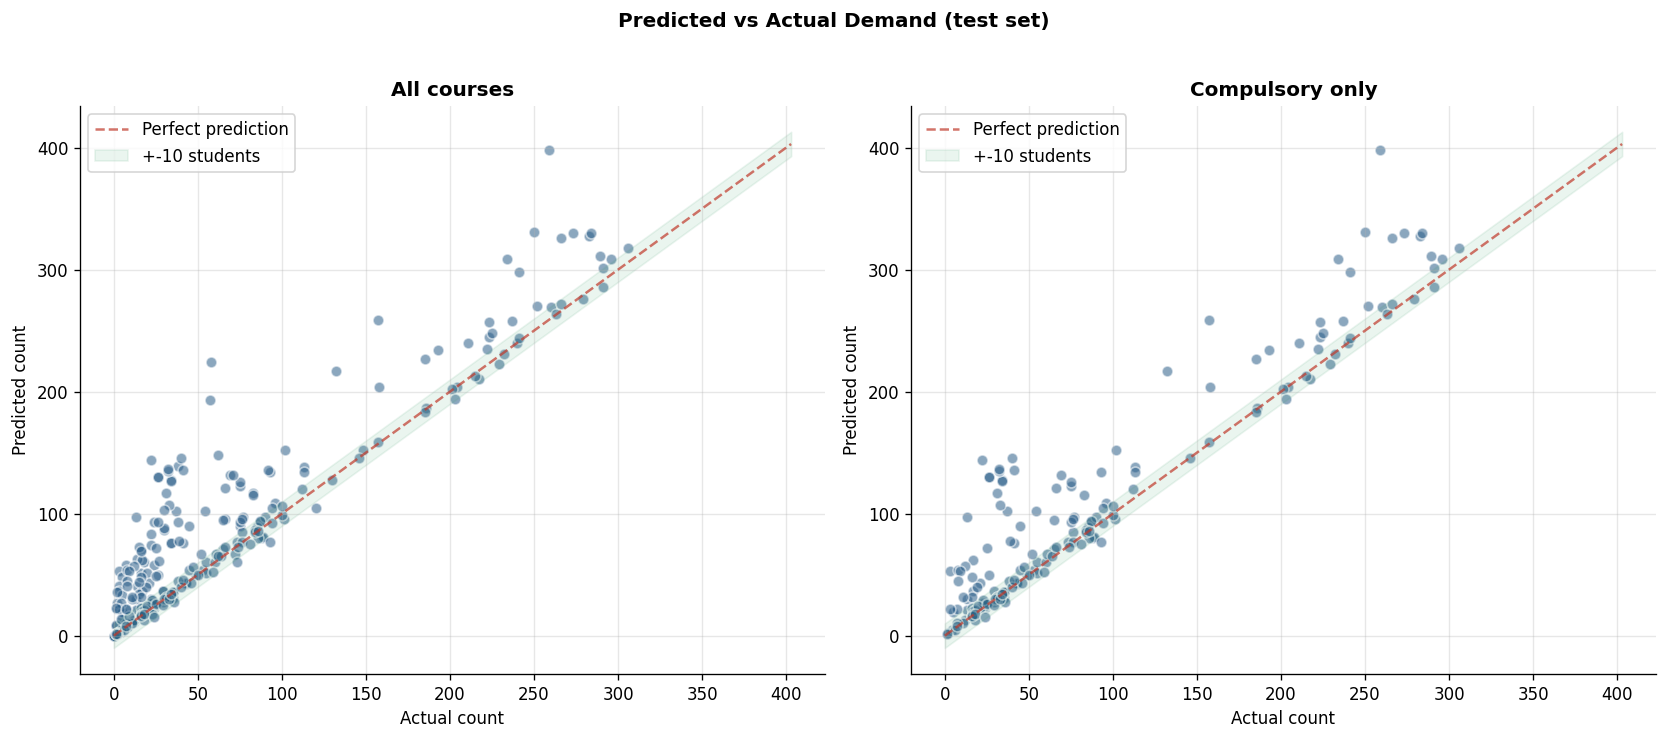

In [116]:
# ── Figure 15: Predicted vs actual demand scatter (all + compulsory) ─────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, title, mask in [(axes[0], "All courses", np.ones(len(d), dtype=bool)),
                        (axes[1], "Compulsory only", d["is_compulsory"]==1)]:
    sub = d[mask]
    ax.scatter(sub["actual_count"], sub["predicted_count"],
               alpha=0.55, s=42, c=PAL["primary"], edgecolor="white")
    lim = max(sub["actual_count"].max() or 0, sub["predicted_count"].max() or 0) + 5
    ax.plot([0, lim], [0, lim], "--", color=PAL["danger"], alpha=0.7,
            label="Perfect prediction")
    # +-10 band
    ax.fill_between([0, lim], [-10, lim-10], [10, lim+10],
                    color=PAL["success"], alpha=0.1, label="+-10 students")
    ax.set_xlabel("Actual count"); ax.set_ylabel("Predicted count")
    ax.set_title(title, fontweight="bold"); ax.legend(); ax.grid(alpha=0.3)

plt.suptitle("Predicted vs Actual Demand (test set)", fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "fig15_pred_vs_actual.png"), bbox_inches="tight")
plt.show()


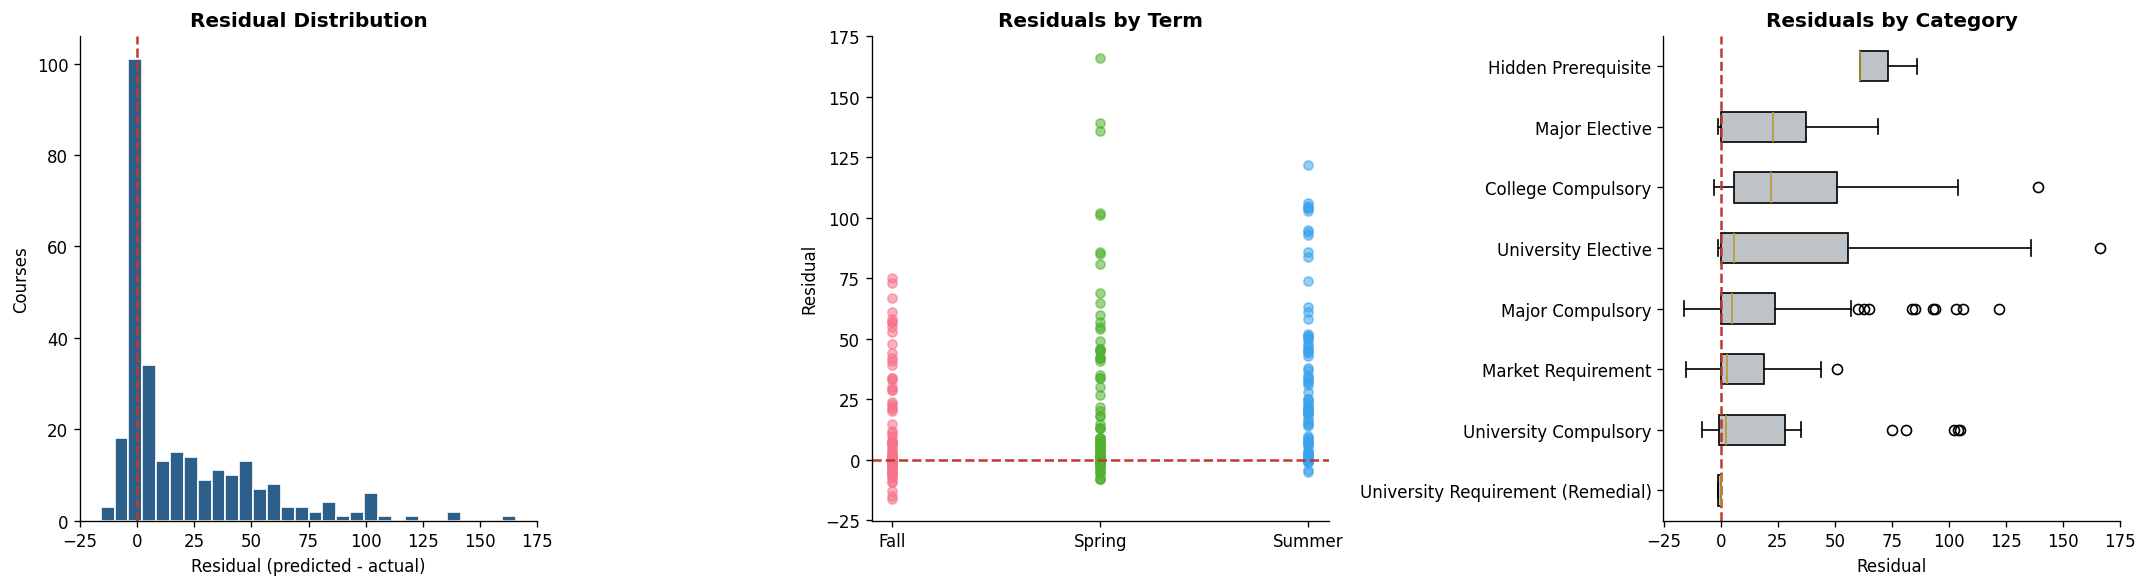

In [76]:
# ── Figure 16: Residual analysis ─────────────────────────────────────────────
d["residual"] = d["predicted_count"] - d["actual_count"]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram of residuals
axes[0].hist(d["residual"], bins=30, color=PAL["primary"], edgecolor="white")
axes[0].axvline(0, color=PAL["danger"], linewidth=1.5, linestyle="--")
axes[0].set_xlabel("Residual (predicted - actual)"); axes[0].set_ylabel("Courses")
axes[0].set_title("Residual Distribution", fontweight="bold")

# By predicted-semester term
d["pred_term"] = d["next_sem"].apply(lambda s: s.split("_")[1] if pd.notna(s) else "?")
for i, term in enumerate(["Fall","Spring","Summer"]):
    sub = d[d["pred_term"]==term]
    if len(sub):
        axes[1].scatter([i]*len(sub), sub["residual"], alpha=0.55,
                        s=30, color=sns.color_palette("husl", 3)[i])
axes[1].set_xticks(range(3)); axes[1].set_xticklabels(["Fall","Spring","Summer"])
axes[1].axhline(0, color=PAL["danger"], linewidth=1.5, linestyle="--")
axes[1].set_ylabel("Residual"); axes[1].set_title("Residuals by Term", fontweight="bold")

# By category
cat_order = d.groupby("category")["residual"].median().sort_values().index.tolist()
cat_data  = [d[d["category"]==c]["residual"].values for c in cat_order]
axes[2].boxplot(cat_data, labels=cat_order, vert=False, patch_artist=True,
                boxprops=dict(facecolor=PAL["light"]))
axes[2].axvline(0, color=PAL["danger"], linewidth=1.5, linestyle="--")
axes[2].set_xlabel("Residual"); axes[2].set_title("Residuals by Category", fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "fig16_residuals.png"), bbox_inches="tight")
plt.show()


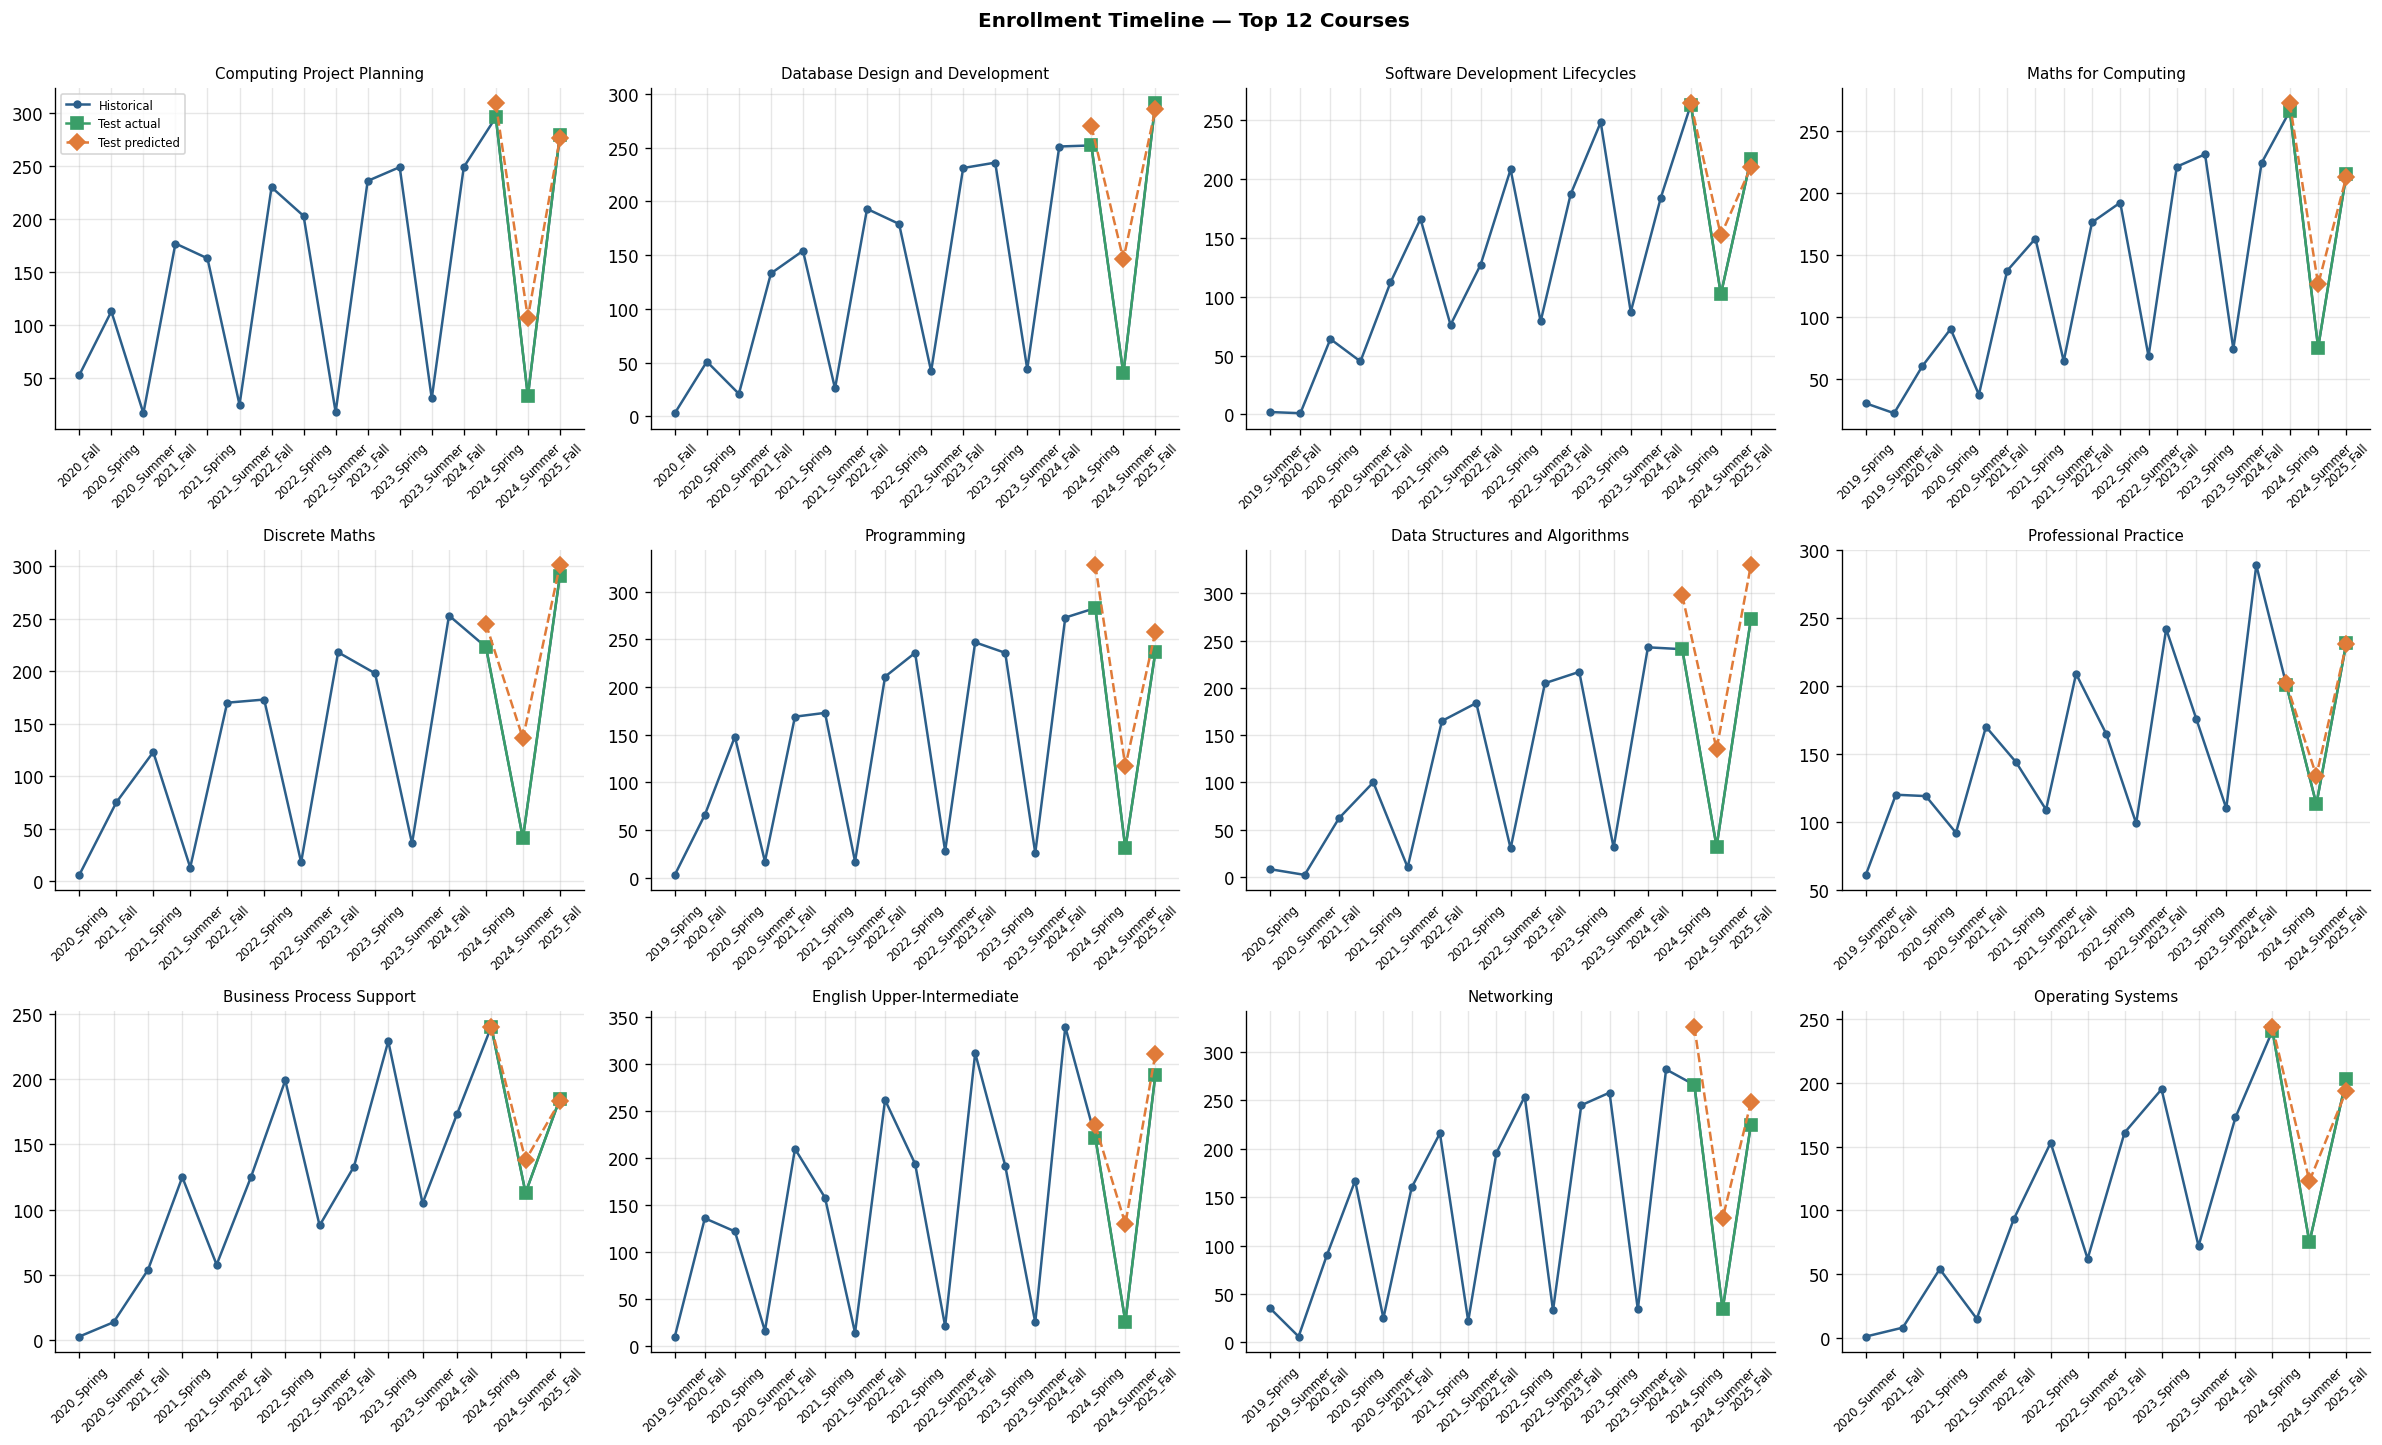

In [77]:
# ── Figure 17: Enrollment timeline — top 12 courses across semesters ─────────
top_courses_now = (demand_agg.groupby("course_code")["actual_count"]
                   .sum().sort_values(ascending=False).head(12).index.tolist())

# Combine train history (actual) + test prediction into a timeline per course
fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.flatten()
for i, cc in enumerate(top_courses_now):
    ax = axes[i]
    # Historical actual (from full course_panel)
    hist = course_panel[course_panel["course_code"]==cc].sort_values("sem_sort_key")
    ax.plot(hist["semester_label"], hist["actual_count"],
            "-o", color=PAL["primary"], markersize=4, label="Historical")
    # Test-set actual
    test_actual = demand_agg[demand_agg["course_code"]==cc].sort_values("next_sem")
    ax.plot(test_actual["next_sem"], test_actual["actual_count"],
            "-s", color=PAL["success"], markersize=7, label="Test actual")
    # Test-set predicted
    ax.plot(test_actual["next_sem"], test_actual["predicted_count"],
            "--D", color=PAL["secondary"], markersize=7, label="Test predicted")
    course_name = master_cat[master_cat["course_code"]==cc]["course_name"]
    ax.set_title((course_name.iloc[0] if len(course_name) else cc)[:40], fontsize=9)
    ax.tick_params(axis="x", rotation=45, labelsize=7)
    ax.grid(alpha=0.3)
    if i == 0:
        ax.legend(fontsize=7)

plt.suptitle("Enrollment Timeline — Top 12 Courses", fontweight="bold", y=1.00)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "fig17_enrollment_timeline.png"), bbox_inches="tight")
plt.show()


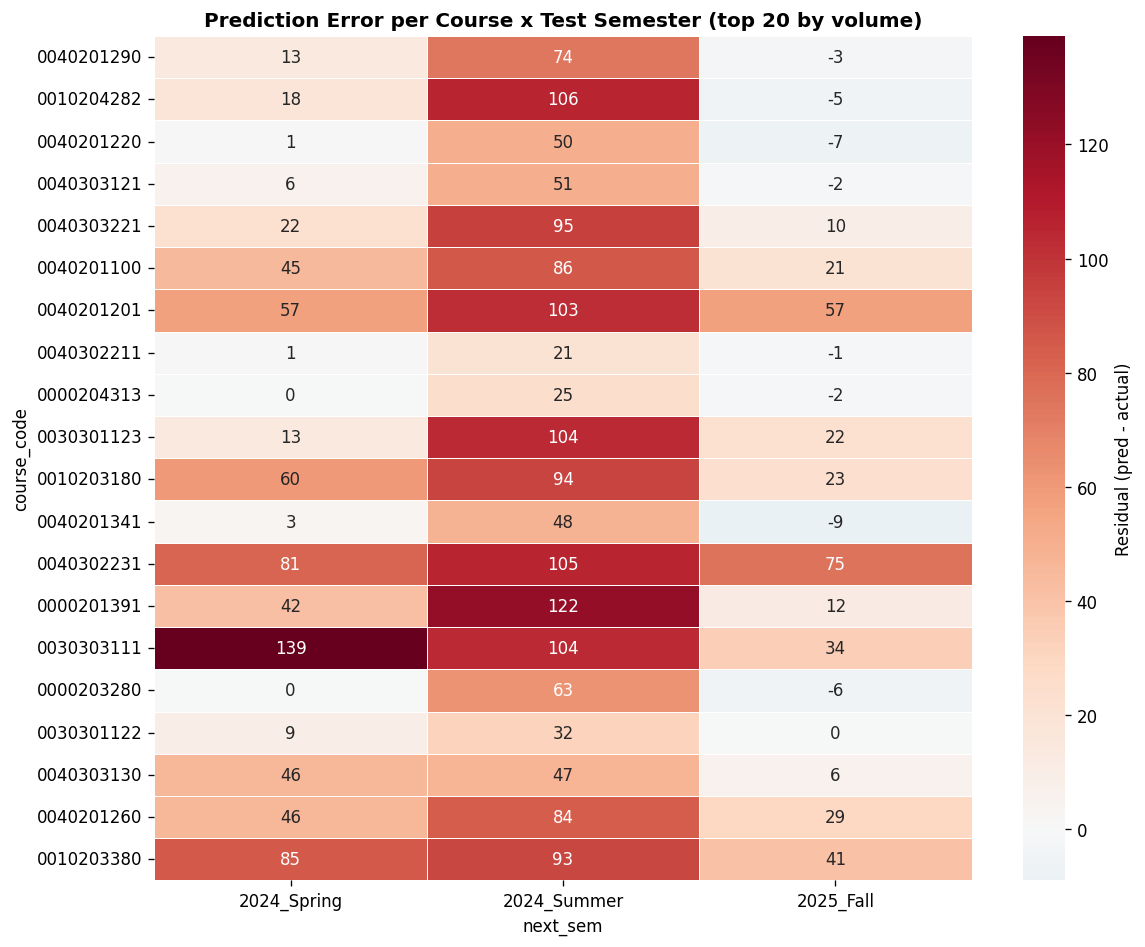

In [78]:
# ── Figure 18: Error heatmap (top 20 courses x test semesters) ───────────────
top_err_courses = (d.groupby("course_code")["actual_count"]
                   .sum().sort_values(ascending=False).head(20).index.tolist())
err_mat = d[d["course_code"].isin(top_err_courses)].pivot(
    index="course_code", columns="next_sem", values="residual")
err_mat = err_mat.reindex(top_err_courses)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(err_mat, annot=True, fmt=".0f", cmap="RdBu_r",
            center=0, cbar_kws={"label":"Residual (pred - actual)"}, ax=ax,
            linewidths=0.5)
ax.set_title("Prediction Error per Course x Test Semester (top 20 by volume)",
             fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "fig18_error_heatmap.png"), bbox_inches="tight")
plt.show()


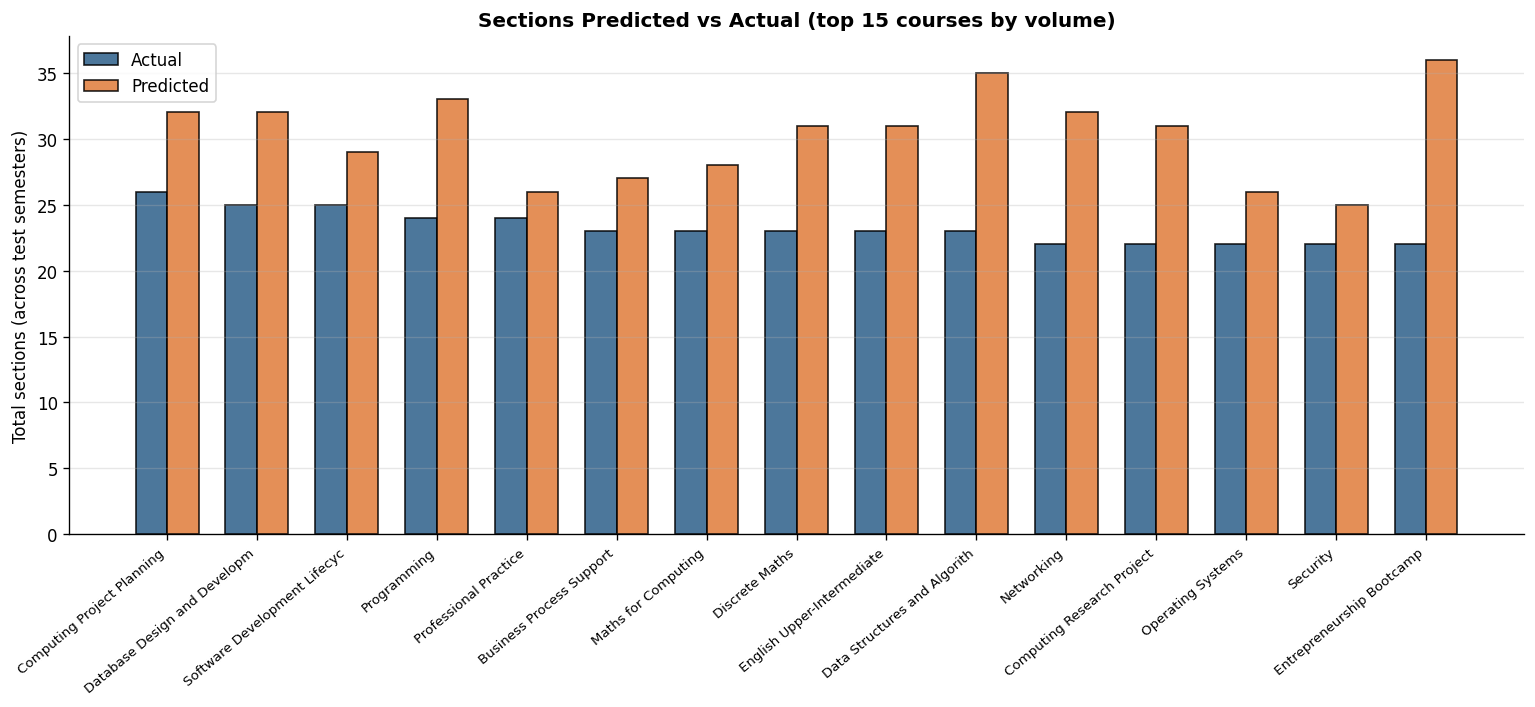

In [79]:
# ── Figure 19: Sections predicted vs actual (top 15 courses) ─────────────────
sec_top = (d.groupby("course_code")
             .agg(actual_sec=("actual_sections","sum"),
                  predicted_sec=("predicted_sections","sum"),
                  course_name=("course_name","first"))
             .reset_index()
             .sort_values("actual_sec", ascending=False).head(15))

fig, ax = plt.subplots(figsize=(13, 6))
x_pos = np.arange(len(sec_top))
w = 0.35
ax.bar(x_pos - w/2, sec_top["actual_sec"], w, label="Actual",
       color=PAL["primary"], alpha=0.85, edgecolor="black")
ax.bar(x_pos + w/2, sec_top["predicted_sec"], w, label="Predicted",
       color=PAL["secondary"], alpha=0.85, edgecolor="black")

labels = [(n[:28] if isinstance(n, str) else c) for c, n
          in zip(sec_top["course_code"], sec_top["course_name"])]
ax.set_xticks(x_pos); ax.set_xticklabels(labels, rotation=40, ha="right", fontsize=8)
ax.set_ylabel("Total sections (across test semesters)")
ax.set_title("Sections Predicted vs Actual (top 15 courses by volume)",
             fontweight="bold")
ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "fig19_sections_comparison.png"), bbox_inches="tight")
plt.show()


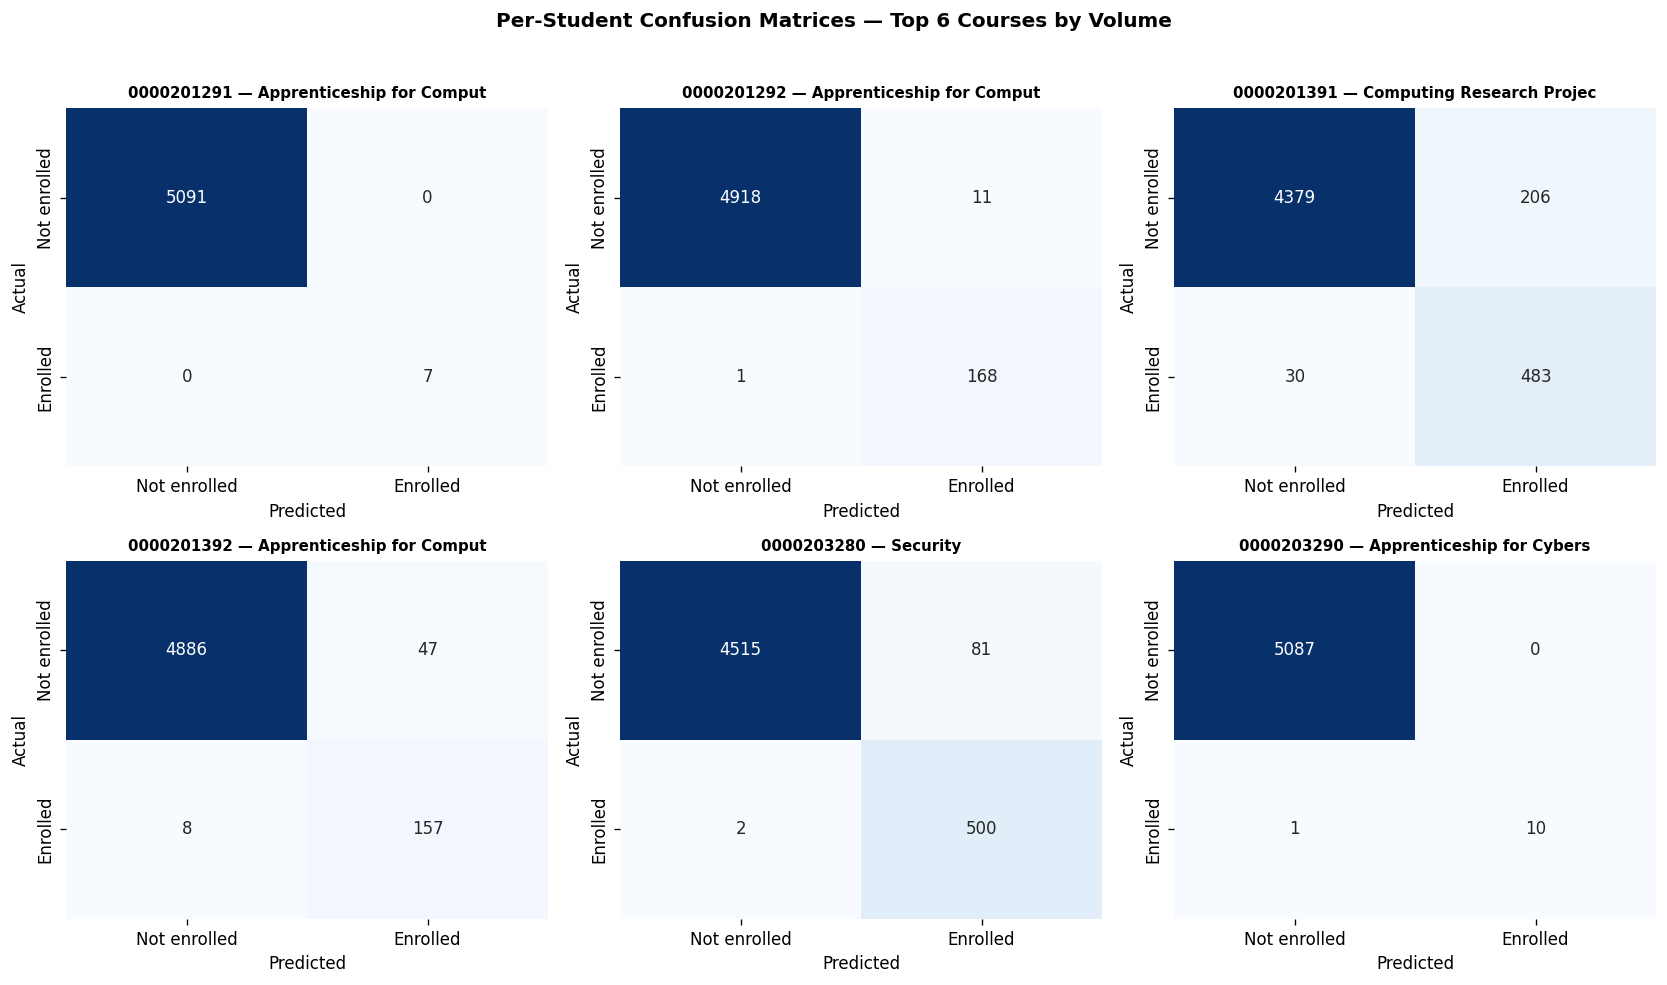

In [80]:
# ── Figure 20: Confusion matrices for top 6 courses (per-student level) ──────
top6 = pred_df.groupby("course_code").size().sort_values(ascending=False).head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
for i, cc in enumerate(top6):
    sub = pred_df[pred_df["course_code"]==cc]
    cm = confusion_matrix(sub["actual_enroll"], sub["pred_enroll"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[i],
                xticklabels=["Not enrolled","Enrolled"],
                yticklabels=["Not enrolled","Enrolled"], cbar=False)
    cname = master_cat[master_cat["course_code"]==cc]["course_name"]
    title = cname.iloc[0] if len(cname) else cc
    axes[i].set_title(f"{cc} — {title[:25]}", fontsize=9, fontweight="bold")
    axes[i].set_xlabel("Predicted"); axes[i].set_ylabel("Actual")

plt.suptitle("Per-Student Confusion Matrices — Top 6 Courses by Volume",
             fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "fig20_confusion_matrices.png"), bbox_inches="tight")
plt.show()


## Section 9 — Graduation Risk Detection

For each study plan, we compute the 75th percentile of *graduation time* (in semesters) from students who've already graduated. Any active student past that threshold with a high retake count is flagged as **at-risk** — a signal that the registrar/advisor may want to intervene or that a course section needs to be kept open to allow them to catch up.

Two features go into the flag:
1. `semesters_taken` is past the 75th percentile of graduated students in the same plan
2. `retake_count` ≥ 5 (student has retaken at least 5 courses — a strong correlate of delayed graduation)

Both conditions must hold for `at_risk=True`. A third flag `high_risk=True` requires the retake_count ≥ 8.


In [81]:
# ── Section 9: Graduation-risk flags ─────────────────────────────────────────
# Per-plan 75th percentile of semesters_taken (graduated only)
grad_mask = students["status"] == "Graduated"
grad_thresholds = (students[grad_mask]
                   .groupby(["major","degree_type"])["semesters_taken"]
                   .quantile(GRAD_PERCENTILE)
                   .reset_index()
                   .rename(columns={"semesters_taken":"threshold_sems"}))
print("Graduation thresholds (75th percentile of grad times):")
print(grad_thresholds.to_string(index=False))

# Retake count per student = number of course_codes with 2+ enrollments
retake_counts = (enrolls.groupby(["student_id","course_code"]).size()
                 .reset_index(name="attempts"))
retake_counts = retake_counts[retake_counts["attempts"] >= 2]
retakes_per_student = (retake_counts.groupby("student_id").size()
                       .reset_index(name="retake_count"))

# Merge into student table
risk_df = students.merge(grad_thresholds, on=["major","degree_type"], how="left")
risk_df = risk_df.merge(retakes_per_student, on="student_id", how="left")
risk_df["retake_count"] = risk_df["retake_count"].fillna(0).astype(int)

risk_df["is_delayed"] = risk_df["semesters_taken"] > risk_df["threshold_sems"]
risk_df["at_risk"]    = (risk_df["is_delayed"]
                          & (risk_df["retake_count"] >= 5)
                          & (risk_df["status"] == "Active"))
risk_df["high_risk"]  = (risk_df["at_risk"] & (risk_df["retake_count"] >= 8))

print()
print(f"Active students at risk:       {risk_df['at_risk'].sum()} / {(risk_df['status']=='Active').sum()}")
print(f"Active students at HIGH risk:  {risk_df['high_risk'].sum()}")

# Save risk list
risk_out = risk_df[risk_df["at_risk"]][
    ["student_id","major","degree_type","semesters_taken","threshold_sems",
     "retake_count","final_cum_gpa","total_passed_hrs","status",
     "at_risk","high_risk"]
].sort_values(["high_risk","retake_count"], ascending=[False, False])
risk_out.to_csv(os.path.join(RESULTS_DIR, "at_risk_students.csv"), index=False)
print(f"\nSaved → {os.path.join(RESULTS_DIR, 'at_risk_students.csv')}")


Graduation thresholds (75th percentile of grad times):
major degree_type  threshold_sems
   AI    Bachelor            14.0
   AI   Technical            10.0
   CS    Bachelor            14.0
   CS   Technical            10.0
Cyber    Bachelor            14.0
Cyber   Technical            10.0

Active students at risk:       6 / 2037
Active students at HIGH risk:  2

Saved → results\at_risk_students.csv


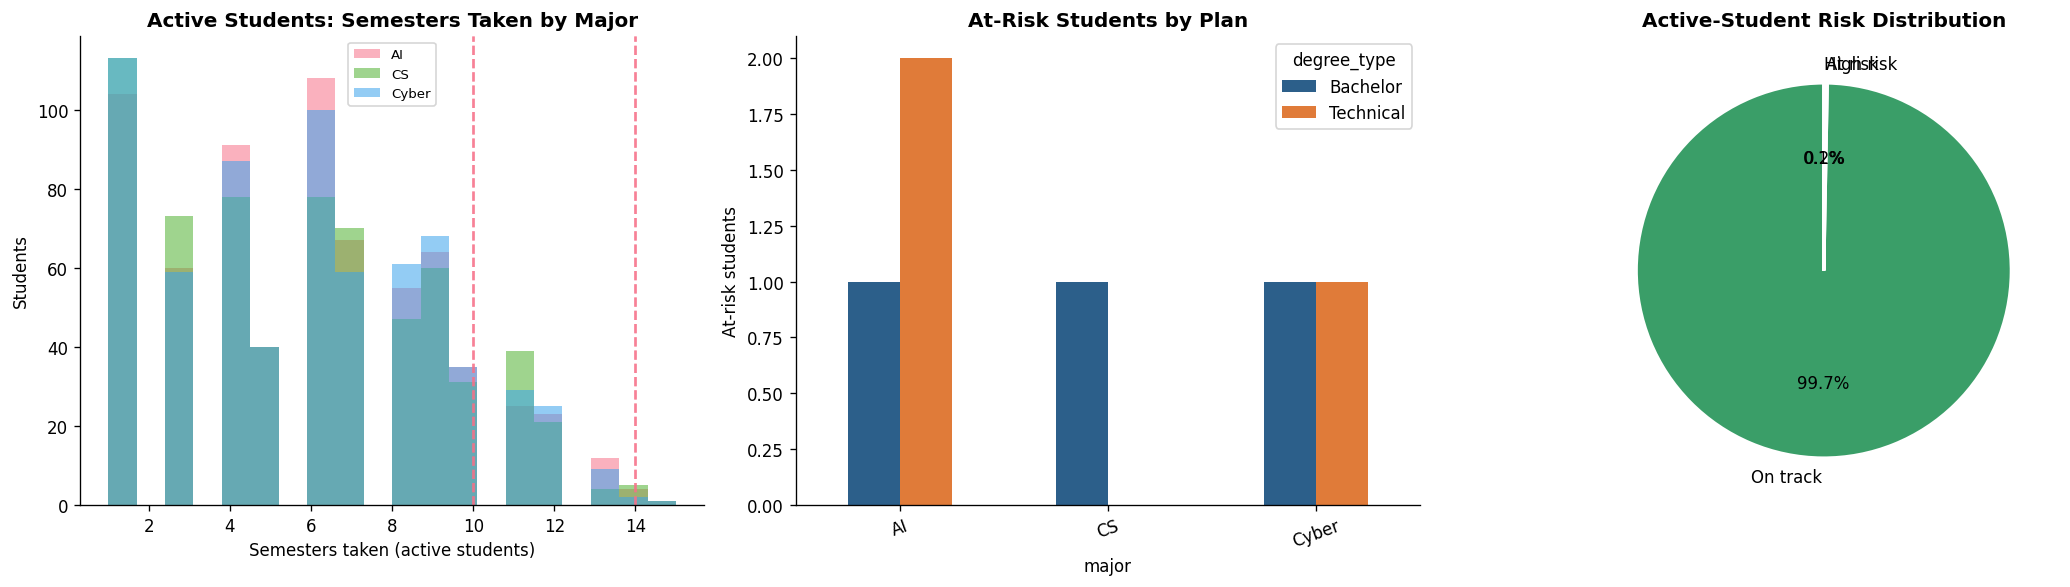

In [82]:
# ── Figure 21: Graduation risk visualisation ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Left — semesters-taken distribution by major, with thresholds marked
for i, (major, grp) in enumerate(risk_df.groupby("major")):
    axes[0].hist(grp[grp["status"]=="Active"]["semesters_taken"],
                 bins=20, alpha=0.55, label=major,
                 color=sns.color_palette("husl", 3)[i % 3])
for _, row in grad_thresholds.iterrows():
    axes[0].axvline(row["threshold_sems"], linestyle="--", alpha=0.5)
axes[0].set_xlabel("Semesters taken (active students)")
axes[0].set_ylabel("Students")
axes[0].set_title("Active Students: Semesters Taken by Major", fontweight="bold")
axes[0].legend(fontsize=8)

# Middle — at-risk counts by major x degree
at_risk_by_plan = risk_df[risk_df["at_risk"]].groupby(["major","degree_type"]).size().unstack(fill_value=0)
at_risk_by_plan.plot(kind="bar", ax=axes[1],
                     color=[PAL["primary"], PAL["secondary"]])
axes[1].set_title("At-Risk Students by Plan", fontweight="bold")
axes[1].set_ylabel("At-risk students"); axes[1].tick_params(axis="x", rotation=20)

# Right — at-risk vs not-at-risk pie (active only)
active = risk_df[risk_df["status"]=="Active"]
labels = ["On track", "At risk", "High risk"]
values = [len(active) - active["at_risk"].sum(),
          active["at_risk"].sum() - active["high_risk"].sum(),
          active["high_risk"].sum()]
colors = [PAL["success"], PAL["secondary"], PAL["danger"]]
axes[2].pie(values, labels=labels, colors=colors, autopct="%1.1f%%",
            startangle=90, wedgeprops={"edgecolor":"white","linewidth":2})
axes[2].set_title("Active-Student Risk Distribution", fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "fig21_graduation_risk.png"), bbox_inches="tight")
plt.show()


## Section 10 — XAI Preparation (SHAP Hooks)

The system will eventually let advisors ask *"why did the model predict 87% for this student?"* — so we prepare **SHAP TreeExplainers** for every tree-based best-model now. The explainers are serialized alongside the models so the Django backend can load them on demand.

Two helpers are defined:

- `explain_student_course(student_id, course_code)` — returns a per-feature SHAP contribution breakdown for a specific student and course. This answers "why will/won't Mahdi enroll in Cryptography?"
- `explain_course_demand(course_code, semester)` — aggregates SHAP contributions across students to explain *"why is this course predicted to need 3 sections?"*

If SHAP isn't installed, the section prints a warning and is skipped — no pipeline breakage.


In [88]:
%pip install shap

  Using cached shap-0.51.0-cp312-cp312-win_amd64.whl.metadata (26 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached numba-0.65.0-cp312-cp312-win_amd64.whl.metadata (3.0 kB)
  Using cached llvmlite-0.47.0-cp312-cp312-win_amd64.whl.metadata (5.1 kB)
Using cached shap-0.51.0-cp312-cp312-win_amd64.whl (556 kB)
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/3

ERROR: Could not install packages due to an OSError: [WinError 32] The process cannot access the file because it is being used by another process: 'e:\\Apps\\Python\\Python App\\Python 3.12.10\\Lib\\site-packages\\numba\\cuda\\tests\\cudapy\\test_warning.py'
Consider using the `--user` option or check the permissions.


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached shap-0.51.0-cp312-cp312-win_amd64.whl.metadata (26 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached numba-0.65.0-cp312-cp312-win_amd64.whl.metadata (3.0 kB)
  Using cached llvmlite-0.47.0-cp312-cp312-win_amd64.whl.metadata (5.1 kB)
Using cached shap-0.51.0-cp312-cp312-win_amd64.whl (556 kB)
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/3


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [89]:
# ── Section 10: XAI preparation (SHAP) ───────────────────────────────────────
try:
    import shap
    SHAP_AVAILABLE = True
    print("SHAP available ✓")
except ImportError:
    SHAP_AVAILABLE = False
    print("SHAP not installed. Install with: pip install shap")
    print("Skipping XAI section (the pipeline works fine without it).")

# Build SHAP TreeExplainers for every tree-based best model
shap_explainers = {}
if SHAP_AVAILABLE:
    tree_model_names = {"RandomForest","GradientBoosting","HistGradientBoosting"}
    print()
    print("Building SHAP TreeExplainers for tree-based best models...")
    for course_code, best in best_per_course.items():
        if best["best_model_name"] not in tree_model_names:
            continue
        try:
            explainer = shap.TreeExplainer(best["best_model"])
            shap_explainers[course_code] = explainer
        except Exception as e:
            # Some models (like HistGradientBoosting) need specific SHAP versions
            pass
    print(f"Built {len(shap_explainers)} SHAP explainers")


SHAP available ✓

Building SHAP TreeExplainers for tree-based best models...
Built 94 SHAP explainers


In [108]:
# ── Section 10.2: Per-student-per-course explanation helper ──────────────────
def explain_student_course(student_id, course_code, snapshot_sem=None, top_k=10):
    # Return a DataFrame of (feature, value, shap_contribution) for the
    # most-recent snapshot of (student_id) predicting (course_code).
    if not SHAP_AVAILABLE or course_code not in shap_explainers:
        return None
    if course_code not in best_per_course:
        return None

    best = best_per_course[course_code]
    # Pick the snapshot row
    stu_snaps = snapshot_with_target[snapshot_with_target["student_id"]==student_id]
    if snapshot_sem:
        stu_snaps = stu_snaps[stu_snaps["snapshot_sem"]==snapshot_sem]
    if len(stu_snaps) == 0:
        return None
    row = stu_snaps.sort_values("sem_sort_key").iloc[[-1]]

    # Assemble features for this single row
    feats_all, _, _ = assemble_for_course(row, course_code)
    cat_c, core_n, num_ext, ext_flags = split_feature_columns(feats_all)
    X, _, fn = build_X(feats_all, ohe_encoder=ohe, scaler=best["scaler"],
                        cat_features=cat_c, num_features_student=core_n,
                        numeric_extras=num_ext, extra_flags=ext_flags)

    # SHAP contributions
    shap_values = shap_explainers[course_code].shap_values(X)
    
    # Normalize SHAP output format (List vs 3D array vs 2D array)
    if isinstance(shap_values, list):   
        # Older SHAP or RF returns [class0_array, class1_array]
        shap_values = shap_values[1]
    elif hasattr(shap_values, 'shape') and len(shap_values.shape) == 3:
        # Newer SHAP might return shape (samples, features, classes)
        shap_values = shap_values[:, :, 1]
        
    # Get the single student's row
    contribs = shap_values[0]

    # Force inputs to be strictly 1-dimensional for Pandas
    out = pd.DataFrame({
        "feature":      fn,
        "value":        np.array(X[0]).flatten(),
        "contribution": np.array(contribs).flatten(),
    })
    
    out["abs_contribution"] = out["contribution"].abs()
    out = out.sort_values("abs_contribution", ascending=False).head(top_k)
    return out[["feature","value","contribution"]]


# Demo — explain the top predicted student for the first course with SHAP support
if SHAP_AVAILABLE and shap_explainers:
    demo_course = next(iter(shap_explainers.keys()))
    demo_pred = (pred_df[pred_df["course_code"]==demo_course]
                 .sort_values("prob_enroll", ascending=False).head(1))
    if len(demo_pred):
        r0 = demo_pred.iloc[0]
        print(f"Example explanation for student {r0['student_id']} × course {demo_course}")
        print(f"  Probability: {r0['prob_enroll']:.2%}  |  Actual: {r0['actual_enroll']}")
        expl = explain_student_course(r0["student_id"], demo_course, r0["snapshot_sem"])
        if expl is not None:
            print()
            print("Top 10 contributing features:")
            print(expl.to_string(index=False))

Example explanation for student 202400020 × course 0000201291
  Probability: 96.00%  |  Actual: 1

Top 10 contributing features:
                      feature     value  contribution
      extra_has_failed_before  1.000000      0.061296
            failed_0000201291  1.000000      0.060378
extra_same_category_pass_rate -2.014956      0.052123
               cum_passed_hrs -1.506075      0.040304
         extra_hrs_ratio_done -1.508505      0.038539
          extra_hrs_remaining  0.949195      0.025637
    extra_avg_credits_per_sem -3.266886      0.022909
             extra_is_in_plan  1.000000      0.021341
                      cum_gpa -2.077973      0.018083
              semester_number -1.235534      0.014923


In [107]:
# ── Section 10.3: Course-demand explanation helper ───────────────────────────
def explain_course_demand(course_code, next_sem, top_k=10):
    # Aggregate SHAP contributions across all students predicted for this course.
    # Returns a DataFrame of mean |contribution| per feature - tells you "which
    # features are driving aggregate demand for Course X in Semester Y?".
    if not SHAP_AVAILABLE or course_code not in shap_explainers:
        return None

    sub_pred = pred_df[(pred_df["course_code"]==course_code)
                       & (pred_df["next_sem"]==next_sem)]
    if len(sub_pred) == 0:
        return None

    # Collect SHAP values for each student's snapshot
    contribs_list = []
    feat_names = None
    for _, r in sub_pred.iterrows():
        expl = explain_student_course(r["student_id"], course_code, r["snapshot_sem"],
                                      top_k=1000)
        if expl is None:
            continue
        contribs_list.append(expl.set_index("feature")["contribution"])
        feat_names = expl["feature"].tolist() if feat_names is None else feat_names

    if not contribs_list:
        return None

    agg = pd.concat(contribs_list, axis=1).fillna(0)
    agg["mean_contribution"]     = agg.mean(axis=1)
    agg["mean_abs_contribution"] = agg.abs().mean(axis=1)

    return (agg[["mean_contribution","mean_abs_contribution"]]
            .sort_values("mean_abs_contribution", ascending=False).head(top_k))


# Demo — explain aggregate demand for one course in one test semester
if SHAP_AVAILABLE and shap_explainers:
    demo_course = next(iter(shap_explainers.keys()))
    demo_sem = demand_agg[demand_agg["course_code"]==demo_course]["next_sem"].iloc[0] \
               if len(demand_agg[demand_agg["course_code"]==demo_course]) else None
    if demo_sem:
        print(f"Aggregate explanation for {demo_course} × {demo_sem}:")
        agg_expl = explain_course_demand(demo_course, demo_sem)
        if agg_expl is not None:
            print(agg_expl.to_string())


Aggregate explanation for 0000201291 × 2024_Spring:
                               mean_contribution  mean_abs_contribution
feature                                                                
failed_0000201291                      -0.103959               0.104367
extra_has_failed_before                -0.100767               0.101183
extra_same_category_pass_rate          -0.049534               0.052570
extra_is_in_plan                       -0.033295               0.037846
cum_passed_hrs                         -0.032093               0.033133
extra_hrs_ratio_done                   -0.024472               0.026729
major_CS                               -0.020493               0.022995
extra_avg_credits_per_sem              -0.020514               0.022017
extra_hrs_remaining                    -0.017843               0.021113
semester_number                        -0.010804               0.012880


## Section 11 — Save Artifacts for Deployment

Everything needed to run inference in the Django backend:

- `artifacts/ohe.pkl` — the one-hot encoder (fit on the full snapshot vocabulary)
- `artifacts/course_models/model_{code}.pkl` — best model per course + its scaler + its feature names
- `artifacts/prereq_map.pkl`, `plan_course_map.pkl` — domain-logic maps
- `artifacts/course_ts_lookup.pkl`, `course_meta_lookup.pkl` — precomputed feature lookups
- `artifacts/inference_meta.json` — all the configuration constants needed to rebuild features at inference time
- `artifacts/shap_explainers/{code}.pkl` — SHAP explainers (optional, only for tree-based models)

The `inference_meta.json` is the single source of truth for the inference-time feature engineering: any change to feature flags, thresholds, or paths is recorded here.


In [109]:
# ── Section 11: Save artifacts ───────────────────────────────────────────────
COURSE_MODELS_DIR = os.path.join(ARTIFACTS_DIR, "course_models")
SHAP_DIR          = os.path.join(ARTIFACTS_DIR, "shap_explainers")
os.makedirs(COURSE_MODELS_DIR, exist_ok=True)
os.makedirs(SHAP_DIR, exist_ok=True)

# 1) Per-course models
manifest_rows = []
for course_code, best in best_per_course.items():
    bundle = {
        "model":         best["best_model"],
        "scaler":        best["scaler"],
        "feature_names": best["feature_names"],
        "best_params":   best["best_params"],
        "model_name":    best["best_model_name"],
        "test_metrics":  best["test_metrics"],
    }
    path = os.path.join(COURSE_MODELS_DIR, f"model_{course_code}.pkl")
    joblib.dump(bundle, path)
    manifest_rows.append({
        "course_code": course_code,
        "model_name":  best["best_model_name"],
        "test_auc":    best["test_metrics"]["auc"],
        "test_f1":     best["test_metrics"]["f1"],
        "n_train":     best.get("n_train", 0),
        "path":        path,
    })

manifest = pd.DataFrame(manifest_rows)
manifest.to_csv(os.path.join(ARTIFACTS_DIR, "model_manifest.csv"), index=False)
print(f"Saved {len(manifest)} course models to {COURSE_MODELS_DIR}/")

# 2) Shared artifacts
joblib.dump(ohe, os.path.join(ARTIFACTS_DIR, "ohe.pkl"))
joblib.dump(prereq_map, os.path.join(ARTIFACTS_DIR, "prereq_map.pkl"))
joblib.dump(plan_course_map, os.path.join(ARTIFACTS_DIR, "plan_course_map.pkl"))
joblib.dump(course_ts_lookup, os.path.join(ARTIFACTS_DIR, "course_ts_lookup.pkl"))
joblib.dump(course_meta_lookup, os.path.join(ARTIFACTS_DIR, "course_meta_lookup.pkl"))
joblib.dump(all_course_codes, os.path.join(ARTIFACTS_DIR, "all_course_codes.pkl"))

# 3) SHAP explainers (if any)
if SHAP_AVAILABLE and shap_explainers:
    for cc, explainer in shap_explainers.items():
        joblib.dump(explainer, os.path.join(SHAP_DIR, f"{cc}.pkl"))
    print(f"Saved {len(shap_explainers)} SHAP explainers to {SHAP_DIR}/")

# 4) Inference metadata
inference_meta = {
    "all_course_codes":    all_course_codes,
    "target_courses":      target_courses,
    "train_until_year":    TRAIN_UNTIL_YEAR,
    "train_until_term":    TRAIN_UNTIL_TERM,
    "train_boundary_key":  int(train_boundary),
    "horizon":             HORIZON,
    "enroll_threshold":    ENROLL_THRESHOLD,
    "section_cap":         SECTION_CAP,
    "sections_buffer_pct": SECTIONS_BUFFER_PCT,
    "feature_flags": {
        "USE_CORE_STUDENT_FEATURES":      USE_CORE_STUDENT_FEATURES,
        "USE_COURSE_TIMESERIES_FEATURES": USE_COURSE_TIMESERIES_FEATURES,
        "USE_COURSE_METADATA_FEATURES":   USE_COURSE_METADATA_FEATURES,
        "USE_V3_EXTRA_FEATURES":          USE_V3_EXTRA_FEATURES,
    },
    "plan_total_hours":    PLAN_TOTAL_HOURS,
    "term_order":          TERM_ORDER,
    "model_manifest_csv":  "model_manifest.csv",
    "n_courses_trained":   len(best_per_course),
    "trained_on":          pd.Timestamp.now().strftime("%Y-%m-%d %H:%M:%S"),
}
with open(os.path.join(ARTIFACTS_DIR, "inference_meta.json"), "w") as f:
    json.dump(inference_meta, f, indent=2)
print(f"\nSaved inference_meta.json → {ARTIFACTS_DIR}/")
print()
print("Artifacts summary:")
for root, dirs, files in os.walk(ARTIFACTS_DIR):
    level = root.replace(ARTIFACTS_DIR, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = "  " * (level + 1)
    for f in files[:5]:
        print(f"{subindent}{f}")
    if len(files) > 5:
        print(f"{subindent}... ({len(files) - 5} more)")


Saved 94 course models to artifacts\course_models/
Saved 94 SHAP explainers to artifacts\shap_explainers/

Saved inference_meta.json → artifacts/

Artifacts summary:
artifacts/
  all_course_codes.pkl
  all_model_results_checkpoint.pkl
  course_meta_lookup.pkl
  course_ts_lookup.pkl
  inference_meta.json
  ... (5 more)
  course_models/
    model_0000201291.pkl
    model_0000201292.pkl
    model_0000201391.pkl
    model_0000201392.pkl
    model_0000203280.pkl
    ... (89 more)
  shap_explainers/
    0000201291.pkl
    0000201292.pkl
    0000201391.pkl
    0000201392.pkl
    0000203280.pkl
    ... (89 more)


## Section 12 — Inference Helper (`predict_next_semester`)

A single function that takes:
- The current enrollment DataFrame (all history up to now)
- The current students DataFrame
- The artifacts directory

...and returns:
- `student_predictions_df`: per-student per-course probabilities for next semester
- `demand_df`: aggregated course demand for next semester
- `sections_df`: section-count recommendations

This is the function the Django backend will call each registration cycle. The notebook smoke-tests it against the last training semester to verify it's self-consistent.


In [ ]:
# ── Section 12: Inference helper (printing first 10 courses)─────────────────────────────────────────────
def predict_next_semester(
    current_enrolls, current_students, artifacts_dir=ARTIFACTS_DIR,
    next_sem_label=None, section_cap=None, buffer_pct=None,
):
    # Load artifacts, rebuild snapshots for the LATEST semester per student,
    # score each with the appropriate per-course model, aggregate into demand.
    # If next_sem_label is None, we compute it from the latest semester in
    # current_enrolls.

    # 1) Load artifacts
    with open(os.path.join(artifacts_dir, "inference_meta.json")) as f:
        meta = json.load(f)

    ohe_           = joblib.load(os.path.join(artifacts_dir, "ohe.pkl"))
    prereq_map_    = joblib.load(os.path.join(artifacts_dir, "prereq_map.pkl"))
    plan_map_      = joblib.load(os.path.join(artifacts_dir, "plan_course_map.pkl"))
    ts_lookup_     = joblib.load(os.path.join(artifacts_dir, "course_ts_lookup.pkl"))
    meta_lookup_   = joblib.load(os.path.join(artifacts_dir, "course_meta_lookup.pkl"))
    all_codes_     = joblib.load(os.path.join(artifacts_dir, "all_course_codes.pkl"))
    
    # 🔥 FIX 1: Force pandas to read course_code as a string to prevent int64 conversion
    manifest_      = pd.read_csv(os.path.join(artifacts_dir, "model_manifest.csv"), dtype={"course_code": str})

    section_cap = section_cap or meta["section_cap"]
    buffer_pct  = buffer_pct  if buffer_pct is not None else meta["sections_buffer_pct"]

    # 2) Build LATEST snapshot per student
    enrolls_ = current_enrolls.copy()
    enrolls_["course_code"] = enrolls_["course_code"].astype(str).str.strip()
    enrolls_["sem_sort_key"] = (enrolls_["year"].astype(int) * 10
                                + enrolls_["term"].map(meta["term_order"]))
    enrolls_ = enrolls_.sort_values(["student_id","sem_sort_key"]).reset_index(drop=True)

    # Build snapshot for every student (uses the full history)
    latest_snap = build_snapshots(enrolls_, current_students, all_codes_, horizon=1)
    
    # Keep only the LAST snapshot per student (the one we want predictions from)
    latest_snap = (latest_snap.sort_values(["student_id","sem_sort_key"])
                   .groupby("student_id").tail(1).reset_index(drop=True))

    # Mock the target column so assemble_for_course doesn't drop future rows
    latest_snap["_enrolled_next"] = [set() for _ in range(len(latest_snap))]

    # Add V3 student-level extras if enabled
    if meta["feature_flags"]["USE_V3_EXTRA_FEATURES"]:
        latest_snap = add_v3_student_level(latest_snap)
        if "_passed_set" not in latest_snap.columns:
            passed_cols_full = [f"passed_{c}" for c in all_codes_]
            arr = latest_snap[passed_cols_full].values
            latest_snap["_passed_set"] = [
                set(all_codes_[j] for j in np.where(row == 1)[0]) for row in arr
            ]

    # Determine next semester label
    if next_sem_label is None:
        latest_key = latest_snap["sem_sort_key"].max()
        # Compute nk inline so we don't depend on the notebook-scope helper
        y = int(latest_key // 10)
        t = int(latest_key % 10)
        if t == 3:
            nk = (y + 1) * 10 + 1; next_sem_label = f"{y+1}_Fall"
        elif t == 1:
            nk = y * 10 + 2; next_sem_label = f"{y}_Spring"
        else:
            nk = y * 10 + 3; next_sem_label = f"{y}_Summer"

    # 3) Score each course
    pred_rows = []
    for _, row in manifest_.iterrows():
        course_code = row["course_code"]
        bundle = joblib.load(row["path"])
        model   = bundle["model"]
        scaler  = bundle["scaler"]
        fnames  = bundle["feature_names"]

        feats_all, _, meta_all = assemble_for_course(latest_snap, course_code)
        if len(feats_all) == 0:
            continue

        cat_c, core_n, num_ext, ext_flags = split_feature_columns(feats_all)
        X, _, _ = build_X(
            feats_all, ohe_encoder=ohe_, scaler=scaler, fit_scaler=False,
            cat_features=cat_c, num_features_student=core_n,
            numeric_extras=num_ext, extra_flags=ext_flags,
        )
        probs = (model.predict_proba(X)[:, 1] if hasattr(model, "predict_proba")
                 else model.predict(X).astype(float))

        for (_, mrow), p in zip(meta_all.iterrows(), probs):
            pred_rows.append({
                "student_id":  mrow["student_id"],
                "course_code": course_code,
                "next_sem":    next_sem_label,
                "prob_enroll": float(p),
                "pred_enroll": int(p >= meta["enroll_threshold"]),
            })

    student_predictions_df = pd.DataFrame(pred_rows)

    # Guard against empty predictions if nobody is eligible
    if len(student_predictions_df) == 0:
        return pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

    # 4) Aggregate into demand
    demand_df = (student_predictions_df.groupby(["next_sem","course_code"])
                 .agg(predicted_count=("prob_enroll","sum"),
                      predicted_binary=("pred_enroll","sum"))
                 .reset_index())
    
    demand_df["predicted_count"] = demand_df["predicted_count"].round().astype(int)
    
    # 🔥 FIX 2: Explicitly cast to string right before merging, just to be bulletproof
    demand_df["course_code"] = demand_df["course_code"].astype(str)
    
    demand_df = demand_df.merge(
        master_cat[["course_code","course_name","credit_hours","category"]],
        on="course_code", how="left"
    )

    # 5) Sections
    demand_df["predicted_sections"] = np.ceil(
        demand_df["predicted_count"] * (1 + buffer_pct) / section_cap
    ).astype(int)

    sections_df = demand_df[["course_code","course_name","predicted_count",
                              "predicted_sections"]].copy()

    return student_predictions_df, demand_df, sections_df


# Smoke test — run inference on the data we already have
print("Running inference smoke test (should match our test-set predictions)...")

try:
    stu_preds_test, demand_test, sections_test = predict_next_semester(
        current_enrolls=enrolls, current_students=students
    )
    print(f"  Predictions generated: {len(stu_preds_test):,} rows")
    print(f"  Courses in demand:     {len(demand_test)}")
    print(f"  Target semester:       {stu_preds_test['next_sem'].iloc[0] if len(stu_preds_test) else 'N/A'}")
    print()
    print("Top 10 predicted courses:")
    print(sections_test.sort_values("predicted_count", ascending=False).head(10).to_string(index=False))
except Exception as e:
    import traceback
    print(f"Smoke test failed: {e}")
    traceback.print_exc()

Running inference smoke test (should match our test-set predictions)...
  Predictions generated: 282,000 rows
  Courses in demand:     94
  Target semester:       2025_Spring

Top 10 predicted courses:
course_code                    course_name  predicted_count  predicted_sections
 0040302231      Entrepreneurship Bootcamp              356                  16
 0040201201 Data Structures and Algorithms              348                  16
 0010203180                     Networking              296                  14
 0000204313       Business Process Support              293                  13
 0030303111                Functional Math              286                  13
 0040201100                    Programming              285                  13
 0040201341              Operating Systems              266                  12
 0040303221                 Discrete Maths              260                  12
 0040303121            Maths for Computing              256                  1

In [ ]:
# ── Section 12: Inference helper (printing all courses)─────────────────────────────────────────────
def predict_next_semester(
    current_enrolls, current_students, artifacts_dir=ARTIFACTS_DIR,
    next_sem_label=None, section_cap=None, buffer_pct=None,
):
    # Load artifacts, rebuild snapshots for the LATEST semester per student,
    # score each with the appropriate per-course model, aggregate into demand.
    # If next_sem_label is None, we compute it from the latest semester in
    # current_enrolls.

    # 1) Load artifacts
    with open(os.path.join(artifacts_dir, "inference_meta.json")) as f:
        meta = json.load(f)

    ohe_           = joblib.load(os.path.join(artifacts_dir, "ohe.pkl"))
    prereq_map_    = joblib.load(os.path.join(artifacts_dir, "prereq_map.pkl"))
    plan_map_      = joblib.load(os.path.join(artifacts_dir, "plan_course_map.pkl"))
    ts_lookup_     = joblib.load(os.path.join(artifacts_dir, "course_ts_lookup.pkl"))
    meta_lookup_   = joblib.load(os.path.join(artifacts_dir, "course_meta_lookup.pkl"))
    all_codes_     = joblib.load(os.path.join(artifacts_dir, "all_course_codes.pkl"))
    
    # 🔥 FIX 1: Force pandas to read course_code as a string to prevent int64 conversion
    manifest_      = pd.read_csv(os.path.join(artifacts_dir, "model_manifest.csv"), dtype={"course_code": str})

    section_cap = section_cap or meta["section_cap"]
    buffer_pct  = buffer_pct  if buffer_pct is not None else meta["sections_buffer_pct"]

    # 2) Build LATEST snapshot per student
    enrolls_ = current_enrolls.copy()
    enrolls_["course_code"] = enrolls_["course_code"].astype(str).str.strip()
    enrolls_["sem_sort_key"] = (enrolls_["year"].astype(int) * 10
                                + enrolls_["term"].map(meta["term_order"]))
    enrolls_ = enrolls_.sort_values(["student_id","sem_sort_key"]).reset_index(drop=True)

    # Build snapshot for every student (uses the full history)
    latest_snap = build_snapshots(enrolls_, current_students, all_codes_, horizon=1)
    
    # Keep only the LAST snapshot per student (the one we want predictions from)
    latest_snap = (latest_snap.sort_values(["student_id","sem_sort_key"])
                   .groupby("student_id").tail(1).reset_index(drop=True))

    # Mock the target column so assemble_for_course doesn't drop future rows
    latest_snap["_enrolled_next"] = [set() for _ in range(len(latest_snap))]

    # Add V3 student-level extras if enabled
    if meta["feature_flags"]["USE_V3_EXTRA_FEATURES"]:
        latest_snap = add_v3_student_level(latest_snap)
        if "_passed_set" not in latest_snap.columns:
            passed_cols_full = [f"passed_{c}" for c in all_codes_]
            arr = latest_snap[passed_cols_full].values
            latest_snap["_passed_set"] = [
                set(all_codes_[j] for j in np.where(row == 1)[0]) for row in arr
            ]

    # Determine next semester label
    if next_sem_label is None:
        latest_key = latest_snap["sem_sort_key"].max()
        # Compute nk inline so we don't depend on the notebook-scope helper
        y = int(latest_key // 10)
        t = int(latest_key % 10)
        if t == 3:
            nk = (y + 1) * 10 + 1; next_sem_label = f"{y+1}_Fall"
        elif t == 1:
            nk = y * 10 + 2; next_sem_label = f"{y}_Spring"
        else:
            nk = y * 10 + 3; next_sem_label = f"{y}_Summer"

    # 3) Score each course
    pred_rows = []
    for _, row in manifest_.iterrows():
        course_code = row["course_code"]
        bundle = joblib.load(row["path"])
        model   = bundle["model"]
        scaler  = bundle["scaler"]
        fnames  = bundle["feature_names"]

        feats_all, _, meta_all = assemble_for_course(latest_snap, course_code)
        if len(feats_all) == 0:
            continue

        cat_c, core_n, num_ext, ext_flags = split_feature_columns(feats_all)
        X, _, _ = build_X(
            feats_all, ohe_encoder=ohe_, scaler=scaler, fit_scaler=False,
            cat_features=cat_c, num_features_student=core_n,
            numeric_extras=num_ext, extra_flags=ext_flags,
        )
        probs = (model.predict_proba(X)[:, 1] if hasattr(model, "predict_proba")
                 else model.predict(X).astype(float))

        for (_, mrow), p in zip(meta_all.iterrows(), probs):
            pred_rows.append({
                "student_id":  mrow["student_id"],
                "course_code": course_code,
                "next_sem":    next_sem_label,
                "prob_enroll": float(p),
                "pred_enroll": int(p >= meta["enroll_threshold"]),
            })

    student_predictions_df = pd.DataFrame(pred_rows)

    # Guard against empty predictions if nobody is eligible
    if len(student_predictions_df) == 0:
        return pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

    # 4) Aggregate into demand
    demand_df = (student_predictions_df.groupby(["next_sem","course_code"])
                 .agg(predicted_count=("prob_enroll","sum"),
                      predicted_binary=("pred_enroll","sum"))
                 .reset_index())
    
    demand_df["predicted_count"] = demand_df["predicted_count"].round().astype(int)
    
    # 🔥 FIX 2: Explicitly cast to string right before merging, just to be bulletproof
    demand_df["course_code"] = demand_df["course_code"].astype(str)
    
    demand_df = demand_df.merge(
        master_cat[["course_code","course_name","credit_hours","category"]],
        on="course_code", how="left"
    )

    # 5) Sections
    demand_df["predicted_sections"] = np.ceil(
        demand_df["predicted_count"] * (1 + buffer_pct) / section_cap
    ).astype(int)

    sections_df = demand_df[["course_code","course_name","predicted_count",
                              "predicted_sections"]].copy()

    return student_predictions_df, demand_df, sections_df


# Smoke test — run inference on the data we already have
print("Running inference smoke test (should match our test-set predictions)...")

try:
    stu_preds_test, demand_test, sections_test = predict_next_semester(
        current_enrolls=enrolls, current_students=students
    )
    print(f"  Predictions generated: {len(stu_preds_test):,} rows")
    print(f"  Courses in demand:     {len(demand_test)}")
    print(f"  Target semester:       {stu_preds_test['next_sem'].iloc[0] if len(stu_preds_test) else 'N/A'}")
    print()
    print("Top 10 predicted courses:")
    print(sections_test.sort_values("predicted_count", ascending=False).head(100).to_string(index=False))
except Exception as e:
    import traceback
    print(f"Smoke test failed: {e}")
    traceback.print_exc()

Running inference smoke test (should match our test-set predictions)...
  Predictions generated: 282,000 rows
  Courses in demand:     94
  Target semester:       2025_Spring

Top 10 predicted courses:
course_code                               course_name  predicted_count  predicted_sections
 0040302231                 Entrepreneurship Bootcamp              356                  16
 0040201201            Data Structures and Algorithms              348                  16
 0010203180                                Networking              296                  14
 0000204313                  Business Process Support              293                  13
 0030303111                           Functional Math              286                  13
 0040201100                               Programming              285                  13
 0040201341                         Operating Systems              266                  12
 0040303221                            Discrete Maths              260

## Section 13 — Summary

That's the full pipeline. Recap of what you now have:

### Inline outputs
- 21 figures in `plots/` covering EDA, model comparison, feature importance, per-student confusion matrices, aggregate demand diagnostics, and graduation-risk breakdowns
- Console printouts at each step showing shapes, metrics, and sanity checks

### Saved CSVs (in `results/`)
- `per_student_predictions.csv` — **the advisor-ready per-student per-course probabilities** (the headline deliverable)
- `demand_forecast.csv` — aggregated course demand per semester
- `sections_recommendation.csv` — section counts with buffer
- `at_risk_students.csv` — students likely to need intervention

### Saved artifacts (in `artifacts/`)
- One `.pkl` per course in `course_models/` with model + scaler + feature names
- `ohe.pkl`, `prereq_map.pkl`, `plan_course_map.pkl`, `course_ts_lookup.pkl`, `course_meta_lookup.pkl` — shared state
- `shap_explainers/*.pkl` — SHAP TreeExplainers (tree-based models only)
- `inference_meta.json` — everything the Django backend needs to know
- `model_manifest.csv` — list of models with their test metrics

### Inference-time
Use `predict_next_semester()` with live enrollment data to get fresh predictions. The function loads all artifacts, re-runs the snapshot builder for the latest state of each student, and scores each course independently. Adding a new course means: train one new model, append to `model_manifest.csv`, drop a `.pkl` into `course_models/`. **No retraining of existing models required.**

### Next iterations to consider
- **Calibration** — the soft probabilities could be recalibrated with Platt scaling or isotonic regression per course
- **Ensembling** — for courses where multiple models score similarly, averaging their probabilities often improves demand aggregation
- **Section-level ML** — treat section-count prediction as a separate regression task (could replace the ceiling rule)
- **Re-training schedule** — retrain per course when test AUC drifts below some threshold
- **Live data** — once the university feeds live data, update `course_ts_lookup` per semester without retraining models
